# 6 -- Modelo LSTM AE con una primera capa de hibridación MLP integrada -- Dataset FDIC RIS 

## Conceptos teoricos fundamentales

### Autoencoders: Definición Formal de la Arquitectura y Espacios Topológicos.

Sea $\mathcal{X} \subseteq \mathbb{R}^{d_{in}}$ el espacio de características de los datos observados y $\mathcal{Z} \subseteq \mathbb{R}^{d_z}$ el espacio latente. Un _autoencoder_ se define como una red neuronal compuesta por dos funciones continuas principales, el encoder ($f_{\theta_e}$) y el decoder ($g_{\theta_d}$), parametrizadas por los conjuntos de pesos y sesgos $\theta_e$ y $\theta_d$, respectivamente.

> Encoder: Mapea el vector de entrada de alta dimensión a la representación latente comprimida:
$$f_{\theta_e}: \mathcal{X} \to \mathcal{Z}, \quad z = f_{\theta_e}(x)$$

> Decoder: Proyecta el vector latente de regreso al espacio original para generar la reconstrucción:
$$g_{\theta_d}: \mathcal{Z} \to \mathcal{X}, \quad \hat{x} = g_{\theta_d}(z)$$

Ambas funciones se construyen mediante la composición de transformaciones afines y funciones de activación no lineales. La restricción dimensional fundamental exige que $d_z < d_{in}$. Esta restricción impide que el modelo aprenda la función identidad trivial $h(x) = x$, obligándolo a proyectar la información sobre una variedad (_manifold_) intrínseca de menor dimensión.

Existe un resultado teórico fundamental que vincula esta arquitectura con los métodos lineales tradicionales.

__Teorema de Linealidad:__ Si las funciones de activación del encoder ($f_{\theta_e}$) y del decoder ($g_{\theta_d}$) son estrictamente lineales, el subespacio latente de dimensión $d_z$ determinado mediante la minimización del error cuadrático medio es algebraicamente equivalente al subespacio determinado por los $d_z$ vectores propios principales de la matriz de covarianza de los datos.

Bajo estas condiciones, el modelo colapsa a una forma de _Análisis de Componentes Principales_ (PCA). En consecuencia, el valor computacional y la capacidad de representación de un _autoencoder_ profundo radican exclusivamente en la introducción de funciones de activación no lineales (tales como ReLU, GELU o Sigmoide). Estas activaciones permiten al modelo aproximar topologías complejas y variedades no lineales que resultan inaccesibles para las transformaciones lineales de PCA.

El entrenamiento del _autoencoder_ se formula matemáticamente como la minimización del riesgo empírico sobre un conjunto de datos $\mathcal{D} = \{x^{(i)}\}_{i=1}^N$. El objetivo consiste en hallar los parámetros óptimos $\theta^*=(\theta_e^*, \theta_d^*)$ mediante:
$$
\theta^* = \arg\min_{\theta_e, \theta_d} \frac{1}{N} \sum_{i=1}^N \mathcal{L}\left(x^{(i)}, g_{\theta_d}(f_{\theta_e}(x^{(i)}))\right)
$$

En el caso de tener datos continuos, la función de pérdida estándar $\mathcal{L}$ es el Error Cuadrático Medio (MSE), definido como:
$$
\mathcal{L}(x, \hat{x}) = \frac{1}{d_{in}} \|x - \hat{x}\|_2^2 = \frac{1}{d_{in}} \sum_{j=1}^{d_{in}} (x_j - \hat{x}_j)^2
$$

luego, aplicando esta fórmula a la optimización de $\theta^*$, tenemos que:
$$
\theta^* = \arg\min_{\theta_e, \theta_d} \frac{1}{N} \sum_{i=1}^N \|x^{(i)} - g_{\theta_d}(f_{\theta_e}(x^{(i)}))\|_2^2
$$

Desde la perspectiva del aprendizaje estadístico, minimizar el MSE es equivalente a maximizar la log-verosimilitud condicional de los datos bajo el supuesto de que el decoder modela la media de una distribución Gaussiana isotrópica con varianza constante. Es decir, se asume un modelo probabilistico
$$
p(x|z) = \mathcal{N}\left(g_{\theta_d}(z), \sigma^2 \mathbf{I}\right)
$$

En caso de que el soporte de los datos de entrada está acotado en el intervalo continuo $[0, 1]^{d_{in}}$, se asume una distribución de probabilidad de Bernoulli multivariada. En este escenario, la función de pérdida óptima se transforma en la Entropía Cruzada Binaria (BCE):
$$
\mathcal{L}(x, \hat{x}) = - \frac{1}{d_{in}} \sum_{j=1}^{d_{in}} \left[ x_j \log \hat{x}_j + (1 - x_j) \log(1 - \hat{x}_j) \right]
$$

El mecanismo de compresión y su éxito empirico en la detección de anomalias, o la deteción de desvios conductuales, se basa en la hipotesis de la variedad (Manifold Hypothesis). Esta postula que los datos de alta dimensión generados por procesos reales se concentran en la vecindad de una variedad incrustada de dimensionalidad intrínseca mucho menor.Durante la fase de optimización con datos nominales (normales), el autoencoder aprende el mapeo coordenado y la topología de dicha variedad. Cuando el modelo procesa una observación anómala $x_{anom}$ que yace ortogonalmente alejada del soporte de la variedad aprendida, el encoder proyecta el punto hacia el espacio latente, perdiendo las componentes ortogonales a la variedad. El decoder reconstruye un vector $\hat{x}_{anom}$ restringido estrictamente a la geometría de la variedad normal, i.e., su mapeo latente y posterior decodificación forzarán al punto a proyectarse hacia la variedad de los datos normales de entrenamiento.

La distancia residual en el espacio original define formalmente la puntuación de anomalia (anomaly score):
$$
A(x) = \|x - g_{\theta_d}(f_{\theta_e}(x))\|_2^2
$$

Un valor elevado de $A(x)$ denota que el vector analizado no pertenece a la variedad de entrenamiento, que es la variedad de datos normales que el modelo ha aprendido durante el entrenamiento.


En lo relativo a la tensión entre la capacidad expresiva y capacidad de deteción, el diseño del modelo posee un cuello de botella dimensional qu presenta una complejidad teórica gobernada por la compelejidad de la familia de hipotesis. Un modelo sobreparametrizado, es decir una excesiva profundidad o un valor de $d_z$ cercano a $d_{in}$, presenta una alta complejidad de Rademacher.

La complejidad de Rademacher es una medida fundamental en la teoria del aprendizaje estadistico y ML qu cuantifica la riqueza o capacidad expresiva de una clase de funciones (modelos), la cual permite predecir la tendencia de un algoritmo a sobreajustarse a los datos. Esta se emplea para encontrar limites (cotas) del error de generalización, ayudando a que un modelo entrenado funcióne bien con datos nuevos y no solo con los de entrenamiento.

__Definición:__ La complejidad de Rademacher mide la capacidad de una familia de funciónes $G$ para ajustarse a etiquetas aleatorias. Se basa en v.a.i $\sigma_i$ (vectores de signo) que toman valores +1 o -1 con probabilidad 0.5 cada una. La complejidad empirica de Rademacher para una muestra fija $\mathcal{S}=(z^{(1),\dots z^{(m)}})$ se define como:
$$
\mathcal{R}_s(G)=\mathbb{E}_{\sigma}(\sup_{g\in G}\frac{1}{m}\sum_{i=1}^m\sigma_i g(z_i))
$$
donde tenemos la esperanza respecto a los signos de Rademacher. El supremo encuentra la función $g\in G$ que logra la mayor correlación con los signos aleatorios.

Luego, si el modelo esta sobreparametrizado, tendá una alta complejidad de Rademacher, lo cual permitira al modelo interpolar el ruido de los datos normales y extender su capacidad de mapeo a regiones fuera del soporte de entrenamiento. Como consecuencia, el modelo adquiere la capacidad de reconstruir fielmente incluso las observaciones anómalas, provocando que el puntaje de anomalía colapse a cero y eliminando el poder discriminativo del sistema. Por el contrario, si el modelo posee una capacidad severamente restringida, se introduce un sesgo inductivo excesivo, impidiendo la correcta reconstrucción de la propia estructura de los datos normales (subajuste) y generando falsos positivos generalizados.

Para mitigar esta tensión sin depender exclusivamente de la reducción estricta de la dimensión $d_z$, se incorporan operadores matemáticos de regularización en espacios latentes de mayor dimensión ($d_z \ge d_{in}$):

- Regularización Estructural ($L_2$): Penalización de la norma de los pesos ($\lambda \|\theta\|_2^2$) para restringir la constante de Lipschitz de las funciones de activación, suavizando el mapeo.

- Autoencoders Dispersos (Sparse Autoencoders): Imposición de una penalización de esparcidad mediante la Divergencia de Kullback-Leibler ($\text{D}_{\text{KL}}$) entre la distribución media de activación de las neuronas latentes ($\hat{\rho}$) y un parámetro de esparcidad objetivo ($\rho \ll 1$):
$$
\text{D}_{\text{KL}}(\rho \,\|\, \hat{\rho}) = \sum_{j} \left[ \rho \log \frac{\rho}{\hat{\rho}_j} + (1 - \rho) \log \frac{1 - \rho}{1 - \hat{\rho}_j} \right]
$$

- Autoencoders Variacionales (VAE): Sustitución del cuello de botella determinista por la optimización del Límite Inferior de la Evidencia (ELBO). Esto obliga al espacio latente a estructurarse según una distribución previa conocida (generalmente una Gaussiana estándar $\mathcal{N}(0, \mathbf{I})$), permitiendo un control preciso sobre el dilema sesgo-varianza bajo escenarios de desbalance extremo de clases.

### LSTM AEncoder: Extensión Topológica Del Dominio Estático al Secuencial

Sea $X = (x_1, x_2, \dots, x_T)$ una secuencia multivariada de longitud $T$, donde cada vector de observación en el tiempo $t$ pertenece al espacio de características original $x_t \in \mathbb{R}^{d_{in}}$. A diferencia del autoencoder clásico, que define un mapeo sobre un espacio vectorial singular $\mathbb{R}^{d_{in}}$, el LSTM Autoencoder proyecta una secuencia temporal completa $\mathcal{X} \subset \mathbb{R}^{T \times d_{in}}$ hacia un espacio latente comprimido $\mathcal{Z}$, para posteriormente reconstruir dicha secuencia preservando sus dependencias temporales subyacentes.Esta arquitectura requiere la optimización conjunta de parámetros para modelar tanto la redundancia espacial (características colineales en $x_t$) como la redundancia temporal (autocorrelación entre $x_t$ y $x_{t-k}$).

__Fase de Codificación (Encoder Secuencial)__

El encoder se define como una función recursiva parametrizada por una celda LSTM ($\text{LSTM}_{enc}$). Para cada paso temporal $t \in \{1, \dots, T\}$, los estados internos se actualizan procesando secuencialmente la entrada $x_t$:
$$
h_t^{(e)}, c_t^{(e)} = \text{LSTM}_{enc}(x_t, h_{t-1}^{(e)}, c_{t-1}^{(e)})
$$

Donde $h_0^{(e)}$ y $c_0^{(e)}$ se inicializan como vectores nulos. Tras procesar la secuencia completa, la información espacio-temporal queda abstraída en los estados finales $(h_T^{(e)}, c_T^{(e)})$. El vector latente $z$, que actúa como el cuello de botella de la arquitectura, puede definirse de dos formas según la implementación:
- Como la concatenación de ambos estados: $z = [h_T^{(e)}; c_T^{(e)}] \in \mathbb{R}^{2 \cdot d_h}$, o 
- exclusivamente como el estado oculto: $z = h_T^{(e)} \in \mathbb{R}^{d_h}$.

Dado un tensor de entrada de dimensión $T \times d_{in}$ y un espacio latente definido por la concatenación de estados en $\mathbb{R}^{2 \cdot d_h}$, la arquitectura fuerza un mapeo proyectivo con una tasa de compresión exacta de $4:1$, en caso de usar los valore estandar de la literatura como $T=4$, $d_{in}=96$, $d_h=48$. Si se omite el estado de celda y se utiliza únicamente $h_T^{(e)}$, la compresión se incrementa a $8:1$. Esta asimetría de información obliga matemáticamente al modelo a retener únicamente los componentes principales de la varianza secuencial.

__Fase de Decodificación (Decoder Secuencial)__

El decoder se constituye por una celda recurrente análoga ($\text{LSTM}_{dec}$) que actúa como un modelo generativo condicionado. Su inicialización obedece a la transferencia de la memoria terminal del encoder:

$$
h_0^{(d)} = h_T^{(e)}, \quad c_0^{(d)} = c_T^{(e)}
$$

Bajo la estrategia de inyección constante (constant feeding strategy), el vector latente global $z$ se suministra como entrada exógena estática en cada iteración del decoder $t \in \{1, \dots, T\}$. Esta técnica previene la atenuación del contexto global en secuencias largas:

$$
h_t^{(d)}, c_t^{(d)} = \text{LSTM}_{dec}(z, h_{t-1}^{(d)}, c_{t-1}^{(d)})
$$

Posteriormente, el estado oculto decodificado requiere una proyección afín para recuperar la cardinalidad del espacio de características original $d_{in}$. Esto se logra mediante una capa de transformación lineal independiente del tiempo:

$$
\hat{x}_t = W_{out} h_t^{(d)} + b_{out}
$$

Donde $W_{out} \in \mathbb{R}^{d_{in} \times d_h}$ y $b_{out} \in \mathbb{R}^{d_{in}}$. Basadondonos en las aportaciones de Sutskever et al. (2014) para modelos Sequence-to-Sequence, la optimización puede estructurarse alterando la topología del objetivo temporal. En la reconstrucción invertida, la función de pérdida no evalúa la secuencia generada en orden cronológico, sino que impone la simetría especular sobre el objetivo:
$$
\hat{X} = (\hat{x}_1, \hat{x}_2, \dots, \hat{x}_T) \approx (x_T, x_{T-1}, \dots, x_1)
$$
La minimización del Riesgo Empírico basada en el Error Cuadrático Medio Secuencial se redefine formalmente como:
$$
\mathcal{L}_{invertida} = \frac{1}{T} \sum_{t=1}^{T} \|\hat{x}_t - x_{T-t+1}\|_2^2
$$

La justificación matemática de este diseño reside en el análisis de las derivadas parciales de la retropropagación a través del tiempo (BPTT). En una configuración cronológica estándar, el primer vector analizado $x_1$ es el primero en ser reconstruido $\hat{x}_1$, lo que impone una distancia de $T$ operaciones de estado no lineales, exacerbando el riesgo de gradiente evanescente para dicha entrada.

Al invertir el objetivo, el vector más reciente y estocásticamente relevante de la ventana $x_T$ es codificado en el último paso del encoder e inmediatamente evaluado en el primer paso del decoder $\hat{x}_1$. Esta contigüidad algorítmica reduce la longitud mínima de la ruta del gradiente entre la predicción y el último estado observado a un único paso de activación. En consecuencia, el trimestre financiero más reciente $(t=T)$ recibe una actualización de pesos (flujo de gradiente) matemáticamente más densa y directa, anclando fuertemente el sesgo de la red sobre las condiciones de borde actuales. Esta propiedad es analíticamente óptima para sistemas de Early Warning sobre series de tiempo económicas.

## Deteción de anomalias no supervisadas: Hipótesis de Normalidad y Asintótica del Riesgo Estocástico

El paradigma de aprendizaje no supervisado mediante autoencoders para la detección de anomalías se fundamenta empírica y teóricamente en la aproximación de la distribución marginal subyacente de los datos. Sea un conjunto de secuencias de entrenamiento $\mathcal{D} \sim P(X)$. En el contexto de un desbalanceo extremo, la probabilidad previa de la clase minoritaria (anomalías/quiebras) denotada como $\pi = P(y=1)$ es marginal, con $\pi \approx 5 \times 10^{-4}$ (63 observaciones anómalas frente a 125.575 totales).Bajo esta condición límite, la distribución marginal de los datos converge asintóticamente a la distribución condicional de la clase mayoritaria:

$$
P(X) = (1-\pi)P(X \mid y=0) + \pi P(X \mid y=1) \approx P(X \mid y=0)
$$

Durante la optimización basada en gradientes (BPTT), el gradiente esperado de la función de pérdida estocástica está dominado abrumadoramente por las muestras normales. Las 63 trayectorias positivas ejercen una perturbación estadísticamente insignificante sobre la topología del espacio de parámetros $\theta$. Por consiguiente, la red no requiere etiquetas, ya que el sesgo inductivo del modelo converge de forma natural a la parametrización de la variedad (manifold) geométrica exclusiva de las instituciones financieras solventes. Durante la fase de inferencia, la divergencia entre la observación empírica $X$ y la proyección del modelo sobre la variedad aprendida define una función de riesgo residual. Para una secuencia completa de longitud $T$, el puntaje de anomalía global $\mathcal{A}(X)$ se define matemáticamente como la esperanza muestral de la norma Euclidiana al cuadrado de los residuos espaciales en cada paso de tiempo:

$$
\mathcal{A}(X) = \frac{1}{T} \sum_{t=1}^{T} \|x_t - \hat{x}_t\|_2^2
$$

Bajo la suposición de que los errores de reconstrucción en el conjunto normal siguen una distribución de perturbación específica, el espacio de inferencia asigna densidades probabilísticas altas a errores bajos (baja varianza para $P(\mathcal{A} \mid y=0)$). Inversamente, dado que el decoder carece de las bases generativas para reconstruir configuraciones anómalas, $P(\mathcal{A} \mid y=1)$ experimenta un desplazamiento distribucional positivo (desplazamiento hacia la derecha) con mayor dispersión.

### Umbralización Topológica y Métricas de Evaluación

La transformación del puntaje continuo $\mathcal{A}(X) \in \mathbb{R}^{+}$ en una decisión binaria $\hat{y} \in \{0, 1\}$ se logra mediante la aplicación de un umbral de discriminación $\tau$:

$$
\hat{y} = \mathbb{I}(\mathcal{A}(X) > \tau)
$$

Donde $\mathbb{I}(\cdot)$ es la función indicatriz. 

La optimización escalar de $\tau$ es crítica y debe evitar sesgos geométricos derivados de la matriz de confusión.

- _Ineficacia del Espacio ROC_: En escenarios de desbalanceo severo, la curva _ROC_ (Receiver Operating Characteristic) resulta matemáticamente engañosa. La Tasa de Falsos Positivos (FPR) incluye los Verdaderos Negativos en el denominador ($\text{FPR} = \frac{\text{FP}}{\text{FP} + \text{TN}}$). Debido al volumen masivo de TN, el FPR permanece cercano a 0 incluso si los FP absolutos destruyen la viabilidad operativa del sistema de alerta temprana, inflando artificialmente el Área Bajo la Curva (AUC-ROC).

- _Optimización en el Espacio PR_: El espacio Precisión-Recall (PR) aísla la métrica de los Verdaderos Negativos. La precisión ($\frac{\text{TP}}{\text{TP} + \text{FP}}$) castiga directamente cada Falso Positivo. Por tanto, maximizar el AUC-PR es la formulación estadísticamente rigurosa en este dominio.

Para la fijación operativa de $\tau$, existen estrategias teóricamente viables:

- _Estimación de Cuantiles Empíricos_: Asumir un nivel de significancia $\alpha$ (v.g., $\alpha=0.01$) y fijar $\tau$ en el percentil $(1-\alpha)$ de la distribución de $\mathcal{A}(X)$ sobre los datos normales. No obstante, es frágil ante colas pesadas.

- _Maximización Funcional del F-score:_ Encontrar $\tau^* = \arg\max_{\tau} F_\beta(\tau)$ sobre un conjunto de validación, donde $\beta$ pondera la importancia del Recall frente a la Precisión (típicamente $\beta=1$ o $\beta=2$ en alertas tempranas).

- _Teoría de Valores Extremos (EVT):_ En lugar de optimización heurística, ajustar la cola derecha de la distribución de errores normales a una Distribución Generalizada de Pareto (GPD) y derivar un $\tau$ probabilísticamente fundamentado para anomalías extremas.

La deconstrucción del riesgo temporal permite derivar un puntaje local no promediado para cada subintervalo de la secuencia:

$$
\mathcal{A}_t(X) = \|x_t - \hat{x}_t\|_2^2, \quad \forall t \in \{1, \dots, T\}
$$

Esta formulación transforma el modelo de un clasificador binario retrospectivo a un sistema dinámico de alerta temprana (Early Warning System). El análisis de la derivada discreta del error, o el gradiente de anomalía $\Delta \mathcal{A}_t = \mathcal{A}_t - \mathcal{A}_{t-1}$, resulta superior para medir la anticipación cronológica.Permite identificar el momento exacto $t-k$ (siendo $k$ los periodos de anticipación antes de la quiebra efectiva) en el que el vector proyectado de la entidad abandona de manera ortogonal la variedad probabilística de solvencia institucional, maximizando la utilidad práctica de la intervención preventiva.

### Heterogeneidad Distribucional y Subespacios Latentes

El diseño de la fase de integración aborda un problema clásico en el aprendizaje multimodal: la fusión temprana (early fusion) de representaciones provenientes de procesos generativos ortogonales.

Sean dos vectores de características (embeddings) obtenidos independientemente, $e_i\in\mathbb{R}^{d_i}$ y $e_j\in\mathbb{R}^{d_j}$, donde el modelo del que provienen ambos es distinto el uno del otro. Una concatenación ingenua $e_{concat} = [e_{i} \parallel e_{j}] \in \mathbb{R}^{d_{concat}}$ genera un vector donde los bloques de coordenadas poseen varianzas, escalas y estructuras de correlación drásticamente diferentes. Si este tensor heterogéneo se suministra directamente a la celda recurrente, la matriz de pesos de entrada del LSTM ($W_x$) se ve obligada a resolver simultáneamente dos problemas de optimización de alta complejidad:

- Alineación Espacial: Proyectar las distribuciones marginales disjuntas a un espacio métrico común.
- Modelado Secuencial: Extraer los patrones de transición temporal de dicho espacio.

Por el principio de desacoplamiento funcional, se interpone un Perceptrón Multicapa (MLP) como operador de proyección no lineal. La función de proyección $P_{\phi}$ parametrizada por $\phi$ mapea el vector concatenado hacia un espacio homogéneo de dimensión intermedia:

$$
P_{\phi} : \mathbb{R}^{d_{concat}} \to \mathbb{R}^{d_{model}}, \quad e_{proj} = P_{\phi}([e_{i} \parallel e_{j}])
$$

Este diseño permite que el MLP resuelva la interpolación multimodal cruzada (cross-modal alignment), entregando al subsistema LSTM un flujo continuo de vectores $e_{projected}$ estocásticamente estabilizados, permitiéndole especializarse matemáticamente en el modelado de la covarianza temporal.

### Optimización End-to-End y Construcción del Espacio de Normalidad

La contribución analítica más profunda de este diseño radica en la retropropagación del error (backpropagation) a través de todo el grafo computacional. La función de pérdida no es una métrica aislada, sino un gradiente continuo que se calcula como el error cuadrático medio secuencial sobre los vectores proyectados:

$$
\mathcal{L} = \frac{1}{T} \sum_{t=1}^{T} \|e_{projected}^{(t)} - \hat{e}_{projected}^{(t)}\|_2^2
$$

Bajo la optimización conjunta (entrenamiento end-to-end), las actualizaciones de los parámetros $\phi$ del MLP se rigen por la regla de la cadena, donde el gradiente de la pérdida debe fluir a través de los Jacobianos del decoder y del encoder recurrente:

$$
\Delta \phi \propto - \frac{\partial \mathcal{L}}{\partial \phi} = - \left( \frac{\partial \mathcal{L}}{\partial \hat{e}_{projected}} \cdot \frac{\partial \hat{e}_{projected}}{\partial e_{projected}} \cdot \frac{\partial e_{projected}}{\partial \phi} \right)
$$

Esta dependencia estructural implica que el operador $P_{\phi}$ no aprende un mapeo de reducción de dimensionalidad arbitrario (como lo haría un autoencoder estático entrenado por separado). El MLP aprende una transformación estrictamente condicionada a la capacidad de reconstrucción del LSTM.En otras palabras, la red construye dinámicamente el espacio $\mathbb{R}^{d_{model}}$ para que las observaciones nominales (bancos sanos, que constituyen el 99.95% del conjunto de entrenamiento) formen una variedad compacta y suave que la celda de memoria recurrente pueda comprimir de manera óptima en la dimensión del estado oculto $\mathbb{R}^{d_h}$.

La decisión de calcular el Error Cuadrático Medio sobre el espacio latente $d_{model}$ (en lugar del espacio original concatenado de 256 dimensiones) define la naturaleza de la detección de anomalías del sistema.Cuando el modelo procesa la secuencia observacional de una institución financiera que se aproxima a la quiebra (anomalía), la transformación $P_{\phi}$ proyecta sus vectores relacionales y tabulares aberrantes hacia el espacio $d_{model}$. Dado que los pesos $\phi$ nunca fueron optimizados para acomodar esta topología específica, el vector resultante $e_{projected\_anom}$ es forzado hacia una subregión del espacio de proyección que carece de soporte probabilístico en la variedad normal aprendida.

Durante el entrenamiento conjunto, la actualización de los pesos $\phi$ del MLP se calcula mediante el gradiente de la función de pérdida global $\mathcal{L}$. Si descomponemos el conjunto de datos $\mathcal{D}$ en el subconjunto de secuencias normales ($\mathcal{D}_{norm}$) y el subconjunto de secuencias anómalas ($\mathcal{D}_{anom}$), el gradiente esperado respecto a $\phi$ se expresa como:
$$
\nabla_{\phi} \mathcal{L} = \frac{1}{N} \left( \sum_{i \in \mathcal{D}_{norm}} \nabla_{\phi} \mathcal{L}^{(i)} + \sum_{j \in \mathcal{D}_{anom}} \nabla_{\phi} \mathcal{L}^{(j)} \right)
$$

Sustituyendo con los valores empíricos de su muestra ($N_{norm} = 125.512$, $N_{anom} = 63$, $N = 125.575$):
$$
\nabla_{\phi} \mathcal{L} = \frac{125.512}{125.575} \left( \frac{1}{N_{norm}} \sum_{i \in \mathcal{D}_{norm}} \nabla_{\phi} \mathcal{L}^{(i)} \right) + \frac{63}{125.575} \left( \frac{1}{N_{anom}} \sum_{j \in \mathcal{D}_{anom}} \nabla_{\phi} \mathcal{L}^{(j)} \right)
$$

$$
\nabla_{\phi} \mathcal{L} = 0,9995 \cdot \mathbb{E}_{norm}[\nabla_{\phi} \mathcal{L}^{(i)}] + 0,0005 \cdot \mathbb{E}_{anom}[\nabla_{\phi} \mathcal{L}^{(j)]}
$$

El $99,95\%$ de la señal de dirección y magnitud del gradiente que modifica los pesos $\phi$ proviene exclusivamente de los datos normales. En cada paso de optimización (ya sea mediante descenso de gradiente en minilotes o completo), la influencia de las 63 anomalías se diluye por un factor de escala de $5 \times 10^{-4}$, volviéndose estadísticamente despreciable (ruido numérico) frente a la masa geométrica de los datos normales.

En un entrenamiento supervisado con funciones de pérdida que castigan el desbalanceo (como Focal Loss), se introduce un factor de ponderación inverso a la frecuencia de clase para amplificar el gradiente de la clase minoritaria.Sin embargo, en el LSTM Autoencoder integrado, el modelo no tiene conocimiento de las etiquetas. El objetivo es puramente el error de reconstrucción sobre el espacio proyectado:

$$
\mathcal{L}^{(j)} = \frac{1}{T}\sum_{t=1}^T \|e_{projected}^{(t, j)} - \hat{e}_{projected}^{(t, j)}\|_2^2
$$

El optimizador busca la configuración de pesos $\phi$ (MLP) y $\theta$ (LSTM) que minimice el error promedio global. Matemáticamente, el sistema puede "permitirse" cometer errores de reconstrucción masivos en las 63 secuencias anómalas, ya que el impacto de dichos errores en la pérdida globalizada tiende a cero. La red colapsará consistentemente hacia una solución que optimice la reconstrucción de la estructura compartida por las miles de secuencias normales.

Dado que el entrenamiento end-to-end modela el espacio $d_{model}$ por y para los datos normales, los pesos $\phi$ del MLP convergen a una transformación lineal/no lineal que:
- Elimina la varianza ortogonal no correlacionada de $e_{tab}$ y $e_{rel}$ de los bancos sanos.
- Sincroniza ambas fuentes en un vector homogéneo $e_{projected}$ que presenta alta regularidad temporal para que la compresión del LSTM sea exitosa.

Cuando una entidad financiera en trayectoria de quiebra es procesada en fase de inferencia:Sus vectores originales $e_{tab}$ y $e_{rel}$ presentan correlaciones atípicas (por ejemplo, un nivel de interconexión en la red que no corresponde a su nivel de liquidez tabular).Al pasar por el MLP, la transformación fija $P_{\phi}$ opera sobre estos valores aberrantes. Al no estar optimizada para esta combinación, genera un vector $e_{projected\_anom}$ cuyas coordenadas rompen la distribución de probabilidad aprendida para el espacio común.El vector resultante se ubica en una región del espacio $d_{model}$ que carece de soporte denso. Al ser introducido en el LSTM Encoder, este no puede mapearlo de forma eficiente a una representación latente coherente, y el LSTM Decoder fallará en la reconstrucción, generando el elevado puntaje de anomalía requerido para la alerta temprana. Su segunda suposición es, por tanto, el pilar analítico que valida el funcionamiento del modelo.

# Definición de la arquitectura MLP + LSTM AutoEncoder (HybridLSTMAE)

La capa de hibridación `MLP` constituye un módulo de fusión que integra dos espacios de representación complementarios del riesgo financiero bancario. El embedding tabular temporal `e_dev ∈ ℝ^{n_samples\times d_dev}` captura patrones secuenciales y dependencias temporales derivadas de variables financieras regularizadas (__CAMELS__). El embedding relacional `e_rel ∈ ℝ^{n_samples\times d_rel}` codifica la estructura de interdependencias entre instituciones mediante convoluciones espectrales sobre el grafo dinámico de la red bancaria.

El tamaño de los embedings relacionales y de los tabulares temporales son los siguientes:
- El embedding tabular temporal de `TabPFN V2.6` ha producido un embedding de dimensión (125575, 194), donde el espacio latente que genera el encoder es de 192, ya que tenemos otras dos variables identificadoras que son `CERT` y `period`. Tenemos todos en la concatenación guardada con el nombre de `embeddings_desarrollo.parquet`

- El embedding relaciónal creado a partir del modelo T-GCN tiene una dimension de (125575, 67), donde realmente el `e_rel` tiene una dimension de 64, ya que las tres variables que tenemos de mas son las variables identificadoras; `CERT`, `period` y `label`.

Luego se realiza una concatenación previa, antes de la capa de fusión `MLP`, lo que produce como resultado un input vector  `X_concat = [e_dev || e_rel] ∈ ℝ^(n_samples, d_dev + d_rel)`, donde el operador `||` denota concatenación por columnas. Este vector híbrido sintetiza tanto la dinámica interna de cada institución como su posicionamiento relativo en la red sistémica. Un `MLP` actúa como transformación lineal por tramos (_piecewise linear_) que remapea el espacio concatenado hacia una dimensionalidad `d_hybrid` que será procesada posteriormente por el `LSTM Autoencoder`. 

La construcción de `X_concat = [e_tab||e_rel]` requiere la alineación previa de las dos fuentes de _embeddings_ generadas, cada una indexada por `(CERT, period)`. La concatenación se realiza mediante un _inner join_ semántico sobre estas claves, de modo que `X_concat` contiene únicamente observaciones banco-trimestre para las que existen simultáneamente representación tabular y representación relacional, descartando, de existir, observaciones presentes en una fuente pero ausentes en la otra (por ejemplo, bancos por debajo del umbral de conectividad mínima requerido para su inclusión en el grafo dinámico del `T-GCN` en un trimestre dado).

Esta decisión tiene dos consecuencias relevantes. Primera, garantiza que ambos componentes de `X_concat` correspondan a representaciones "genuinas" (no imputadas) de la misma observación, lo cual es relevante para la validez de los análisis de separabilidad realizados directamente sobre `e_rel`: la separabilidad observada no es atribuible a artefactos de imputación. Segunda, el tamaño final de `X_concat` determina el número de positivos (failed=1) efectivamente disponibles para los análisis de diagnóstico — 63 observaciones —, una cifra que depende de que ninguna de ellas se haya perdido en el proceso de alineación.

In [1]:
import pandas as pd
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# Carga de ambos embeddings y del panel de etiquetas
emb_dev     = pd.read_parquet("D:/financial_risk_data/embeddings/emb_dev/embeddings_desarrollo.parquet")
emb_rel     = pd.read_parquet("D:/financial_risk_data/embeddings/emb_rel_dev/erel_desarrollo.parquet")
panel_label = pd.read_parquet("D:/financial_risk_data/processed/panel_tabular_labeled.parquet")

# Normalizar tipos de clave en las tres fuentes
for df in [emb_dev, emb_rel, panel_label]:
    df['CERT']   = df['CERT'].astype(str)
    df['period'] = df['period'].astype(str)

print("=== ESTRUCTURA ===")
print(f"emb_dev shape     : {emb_dev.shape}")
print(f"emb_rel shape     : {emb_rel.shape}")
print(f"panel_label shape : {panel_label.shape}")
print(f"Columnas label    : {panel_label.columns.tolist()}")
print()

# Construcción de claves compuestas
keys_dev   = set(zip(emb_dev['CERT'],   emb_dev['period']))
keys_rel   = set(zip(emb_rel['CERT'],   emb_rel['period']))
keys_label = set(zip(panel_label['CERT'], panel_label['period']))

solo_dev = keys_dev - keys_rel
solo_rel = keys_rel - keys_dev
comun    = keys_dev & keys_rel

print("=== ALINEACIÓN TABULAR vs RELACIONAL ===")
print(f"Claves en tabular             : {len(keys_dev)}")
print(f"Claves en relacional          : {len(keys_rel)}")
print(f"Claves comunes (inner join)   : {len(comun)}")
print(f"Solo en tabular (sin e_rel)   : {len(solo_dev)}")
print(f"Solo en relacional (sin e_dev): {len(solo_rel)}")
print()

# Positivos en claves exclusivas de tabular (desde panel_label)
if len(solo_dev) > 0:
    panel_label['_key'] = list(zip(panel_label['CERT'], panel_label['period']))
    pos_perdidos = panel_label[panel_label['_key'].isin(solo_dev)]['failed'].sum()
    panel_label.drop(columns=['_key'], inplace=True)
    print(f"Positivos que se perderían con inner join: {pos_perdidos}")
else:
    print("Sin claves exclusivas en tabular — inner join no pierde ninguna observación")

print()

# Positivos totales según panel_label dentro del rango de desarrollo
keys_comun_series = pd.DataFrame(list(comun), columns=['CERT', 'period'])
panel_dev = panel_label.merge(keys_comun_series, on=['CERT', 'period'], how='inner')
print("=== POSITIVOS EN CONJUNTO DE DESARROLLO ===")
print(f"Total observaciones en inner join : {len(panel_dev)}")
print(f"Positivos (failed=1)              : {panel_dev['failed'].sum()}")
print(f"Tasa de positivos                 : {panel_dev['failed'].mean():.6f}")
print()

print("=== PERIODOS ===")
print(f"Periodos tabular    : {sorted(emb_dev['period'].unique())}")
print(f"Periodos relacional : {sorted(emb_rel['period'].unique())}")

=== ESTRUCTURA ===
emb_dev shape     : (125575, 194)
emb_rel shape     : (125575, 67)
panel_label shape : (206129, 3)
Columnas label    : ['CERT', 'period', 'failed']

=== ALINEACIÓN TABULAR vs RELACIONAL ===
Claves en tabular             : 125575
Claves en relacional          : 125575
Claves comunes (inner join)   : 125575
Solo en tabular (sin e_rel)   : 0
Solo en relacional (sin e_dev): 0

Sin claves exclusivas en tabular — inner join no pierde ninguna observación

=== POSITIVOS EN CONJUNTO DE DESARROLLO ===
Total observaciones en inner join : 125575
Positivos (failed=1)              : 63
Tasa de positivos                 : 0.000502

=== PERIODOS ===
Periodos tabular    : ['2016Q2', '2016Q3', '2016Q4', '2017Q1', '2017Q2', '2017Q3', '2017Q4', '2018Q1', '2018Q2', '2018Q3', '2018Q4', '2019Q1', '2019Q2', '2019Q3', '2019Q4', '2020Q1', '2020Q2', '2020Q3', '2020Q4', '2021Q1', '2021Q2', '2021Q3', '2021Q4']
Periodos relacional : ['2016Q2', '2016Q3', '2016Q4', '2017Q1', '2017Q2', '2017Q3', '20

Tenemos una alineación perfecta en todos los ejes: mismo número de claves, cero observaciones exclusivas en ninguna de las dos fuentes, mismos 23 periodos, y los 63 positivos íntegros preservados en el conjunto de desarrollo.

Esto también confirma algo importante sobre la construcción del pipeline anterior: el `T-GCN` procesó exactamente el mismo universo de observaciones que `TabPFN`, lo cual no era trivial dado que el grafo podría haber excluido bancos con conectividad insuficiente. El hecho de que las 125.575 claves coincidan exactamente indica que el `graph builder` mantuvo todos los bancos del panel de desarrollo como nodos, incluso aquellos con grado bajo.

El vector `X_concat` creado posee las variables identificadoras `(CERT, period, failures)`. Para no introducir _data leakage_ mediante las variables `CERT` y `failures` debemos separar de este vector los metadatos de las variables caracteristicas.  Sea $N=125575$ el número total de muestras tras el inner join:
$$
X_{concat} = [ e_{dev} \parallel e_{rel} ] \in \mathbb{R}^{N \times (192 + 64)}
$$

Donde el operador de concatenación $\parallel$ une los vectores de características puras, resultando en una matriz de entrada estrictamente de dimensión $N \times 256$. Las variables `(CERT, period, failures)` actúan únicamente como índices topológicos en el espacio de bases de datos, no en el espacio vectorial $\mathbb{R}^{256}$.

El modelo usado no sera un `MLP` junto con un `LSTM` de forma desacoplada, sino una arquitectura conjunta `MLP+LSTM Aencoder`. La idea es que esta capa de fusión `MLP` no sea independiente y pase a formar parte de la primera capa del `LSTM` de forma integra, haciendo pues una arquitectura más compuesta donde tenemos que:
```python
X_concat = [e_dev || e_rel] ∈ ℝ^(256)
       ↓
   `MLP` projection layer  (256 → d_hidden → d_model)
       ↓
   e_proj ∈ ℝ^(d_model)
       ↓
   LSTM Encoder  (d_model → lstm_hidden)
       ↓
   cespacio latente ∈ ℝ^(lstm_hidden)
       ↓
   LSTM Decoder  (lstm_hidden → d_model)
       ↓
   x_hat_t ∈ ℝ^(d_model)

   loss = MSE(e_projected, x_hat_t)
``` 

Es decir, que el `MLP` no sea un módulo preentrenado independiente que produce `e_proj`, sino una capa de proyección integrada dentro del `LSTM AE`, entrenada conjuntamente con él mediante backpropagation end-to-end. El gradiente del error de reconstrucción del `LSTM AE` fluye hacia atrás a través del decoder, del encoder, y continúa hasta los pesos del `MLP` de proyección, que se optimizan para producir exactamente la representación que minimiza el error de reconstrucción de la arquitectura completa.

Antes de seguir tengamos en cuenta una serie de conceptos clave para la arquitectura de nuestro modelo. Concatenar los outputs de dos modelos preentrenados distintos (`TabPFN` y `T-GCN`) implica unir dos espacios latentes con propiedades estadísticas, varianzas y magnitudes diametralmente opuestas. Si aplicamos el `MLP`, que es una suma ponderada lineal seguida de una activación no lineal, directamente sobre $X_{concat}$, la modalidad con mayor magnitud o varianza dominará los gradientes, silenciando a la otra. Por tanto se debe añadir una capa de normalización antes o inmediatamente después de la concatenación para garantizar una contribución equitativa:
$$
\tilde{e}_{dev} = \text{LayerNorm}(e_{dev})
$$

$$
\tilde{e}_{rel} = \text{LayerNorm}(e_{rel})
$$

Por tanto el `MLP` se define formalmente como:
$$
h = \text{ReLU}(W [\tilde{e}_{dev} \parallel \tilde{e}_{rel}] + b)
$$

Donde $W \in \mathbb{R}^{N \times 256}$. Otra consideración a tener en cuenta es que si definimos la función de pérdida como:

$$
\mathcal{L} = \text{MSE}(e_{proj}, \hat{x}_t)
$$
Donde tanto $e_{proj}$ como $\hat{x}_t$ son salidas parametrizadas que dependen dinámicamente de los pesos de su red y se optimizan simultáneamente mediante backpropagation, el modelo descubrirá una solución trivial, llamado colapso de representación. Para minimizar la pérdida a cero, el optimizador no se esforzará en comprimir información útil. Simplemente forzará a la capa `MLP` a proyectar cualquier vector de entrada $X_{concat}$ hacia un vector constante, por ejemplo, el vector nulo $\mathbf{0}$. Si $e_{proj} = \mathbf{0}$ para todas las observaciones, entonces el LSTM Encoder y el LSTM Decoder procesarán vectores de ceros, produciendo $\hat{x}_t = \mathbf{0}$. Matemáticamente, la pérdida será exactamente cero:
$$
\mathcal{L} = || \mathbf{0} - \mathbf{0} ||_2^2 = 0
$$
El gradiente empujará los pesos del `MLP` hacia la anulación de la varianza del espacio proyectado porque es la ruta de optimización más sencilla. El autoencoder dejará de funcionar como tal. En la literatura de aprendizaje autosupervisado, esto se conoce como un _trivial shortcut_.

Es fundamental destacar que, si bien los vectores $e_{proj}$ y $\hat{x}$ interactúan de manera simétrica dentro del operador de la función de pérdida cuadrática, sus dependencias funcionales con respecto a los parámetros del modelo son profundamente asimétricas. El vector $e_{proj}$ constituye la salida directa y exclusiva de la primera etapa de procesamiento (el módulo de proyección `MLP`), mientras que la reconstrucción $\hat{x}$ es el producto terminal de una composición funcional transitiva que involucra la totalidad de la arquitectura conjunta (`MLP`, encoder LSTM y decoder LSTM), es decir, x_hat = f_decoder(f_encoder(f_`mlp`(x)))

Esto tiene una consecuencia directa sobre el flujo de gradiente que ya está descrita en la documentación de HybridLSTMAE y que conviene tener en cuenta en la memoria. Formalmente, si denotamos e_proj = $f_\phi(x)$, x_hat = f_θd(f_θe(f_\phi(x))) (con \phi, θe, θd los parámetros de `MLP`, encoder y decoder respectivamente), la loss es:

L(\phi,θe,θd) = || f_\phi(x) - f_θd(f_θe(f_\phi(x))) ||²

Los \phi (parámetros del `MLP`) recibe el gradiente por dos caminos: uno directo (como e_proj, el primer término dentro de la norma) y otro indirecto (a través de toda la cadena encoder→decoder, como argumento de f_\phi dentro de f_θd(f_θe(·))). Esto es relevante para entender por qué el `MLP` puede converger a un punto donde ambos caminos se "cancelan" produciendo un mínimo trivial (el colapso de varianza): si f_\phi(x) ≈ c (constante) para todo x, entonces también f_θd(f_θe(c)) ≈ c' puede aprenderse fácilmente (el decoder solo necesita reproducir una constante), y ||c - c'||²≈0 independientemente de x — el `MLP` satisface ambos roles de e_proj simultáneamente (target y, vía la cadena, parte del predictor) con una salida que ignora x. Si tenemos en cuenta como se implementa la retropropagación tenemos que, a través de la arquitectura secuencial profunda:
$$
\partial L/\partial \hat{x} \rightarrow \partial L/\partial \text{decoder} \rightarrow \partial L/\partial (h_T,c_T) \rightarrow \partial L/\partial \text{encoder} \rightarrow \partial L/\partial e_{proj}
$$

Cuando PyTorch (u otro framework de diferenciación automática) calcula los gradientes, empieza desde la función de pérdida $L = \|e_{proj} - \hat{x}\|^2$ y viaja en sentido inverso al flujo de los datos:$\partial L/\partial \hat{x}$: Mide cómo cambia el error al alterar la salida del Decoder ($\hat{x}$).$\rightarrow \partial L/\partial \text{decoder}$: El gradiente atraviesa las capas lineales y de activación del propio Decoder LSTM.$\rightarrow \partial L/\partial (h_T,c_T)$: El error llega al "cuello de botella" temporal, es decir, el estado oculto ($h_T$) y la celda ($c_T$) que el Encoder le transfirió al Decoder.$\rightarrow \partial L/\partial \text{encoder}$: El gradiente fluye hacia atrás a través del tiempo (Backpropagation Through Time o BPTT) recorriendo los 4 trimestres en el Encoder LSTM.$\rightarrow \partial L/\partial e_{proj}$: Finalmente, el gradiente sale del Encoder y llega a la superficie de lo que fue su entrada: el vector proyectado $e_{proj}$. Este es el gradiente de la rama de reconstrucción.

La variable $e_{proj}$ no es una entrada estática (como lo sería una imagen o un dataset crudo); es una variable viva cuyos valores dependen de los pesos del `MLP` ($\phi$).Al calcular la derivada total de la pérdida respecto al `MLP`, la regla de la cadena dictamina que si una variable intermedia afecta a la pérdida por más de un camino, los gradientes de ambos caminos deben sumarse.Si escribimos la ecuación analítica de esta colisión de gradientes para actualizar los pesos del `MLP` ($\phi$), se expresa así:
$$
\frac{\partial L}{\partial \phi} = \underbrace{\frac{\partial L}{\partial e_{proj}} \cdot \frac{\partial e_{proj}}{\partial \phi}}_{\text{Camino Directo (Target)}} + \underbrace{\frac{\partial L}{\partial \hat{x}} \cdot \frac{\partial \hat{x}}{\partial e_{proj}} \cdot \frac{\partial e_{proj}}{\partial \phi}}_{\text{Camino Indirecto (Encoder-Decoder)}}
$$

En la expresión $\|e_{proj} - \hat{x}\|^2$, la pérdida obliga al `MLP` a mover los pesos $\phi$ de forma que $e_{proj}$ se acerque a lo que sea que haya descodificado el Decoder ($\hat{x}$). Es un camino ultra corto y directo, sin capas intermedias. En el caso del `MLP` como creador de la Entrada del LSTM AE, a través de toda la cadena del LSTM (`MLP` → Encoder → Decoder), la pérdida le dice al `MLP` que mueva sus pesos $\phi$ para que el $e_{proj}$ que se genera sea más fácil de comprimir y descodificar por el LSTM, resultando en un mejor $\hat{x}$. Este camino es largo y está fuertemente regulado por las restricciones de memoria del LSTM. 

Los optimizadores, por regla general son de inicialización perezosa (Lazy initialization), luego buscan la configuración de parámetros que reduzca la pérdida a cero con el menor esfuerzo matemático posible. Si permitimos que los gradientes de ambos caminos se sumen e impacten al `MLP`, el modelo descubre un atajo destructivo (_trivial shortcut_), de forma que $f_{\phi}(x) \approx c \,\, \forall x$. Por tanto el optimizador minimiza la pérdida a la perfección y los gradientes de ambos caminos se han cancelado o equilibrado de forma que $\partial L/\partial \phi = 0$. El problema es que el espacio latente se ha vuelto matemáticamente inútil, donde el bloque autoencoder secuencial simplemente aprende a aproximar la identidad sobre dicho espacio invariante ($f_{\theta_d}(f_{\theta_e}(c)) \approx c$), reduciendo la pérdida global asintóticamente a cero a expensas de suprimir la varianza de los datos originales.


Para soluciónar este problema de la asimetría estructural de los gradientes que causa el colapso de representación, debemos congelar artificialmente el vector que actúa como objetivo (target) durante el paso de retropropagación. Tomando como base la literatura del aprendizaje autosupervisado (como en las arquitecturas SimSiam o BYOL), esto se conoce como el operador `Stop-Gradient` ($\text{sg}$). En código de PyTorch, esto se logra aplicando `.detach()` al término que actúa como objetivo en la función de pérdida.Al aplicar esta solución, modificas el grafo de computación eliminando quirúrgicamente la vía directa de gradiente hacia el `MLP`. Matemáticamente, tu función de pérdida se reconfigura así:
$$
\mathcal{L}(\theta_m, \theta_e, \theta_d) = \| \text{sg}[e_{proj}] - \hat{x} \|_2^2
$$

Si recalculamos la derivada de la pérdida respecto a los parámetros del `MLP` ($\theta_m$), la ecuación que antes colisionaba ahora se limpia:
$$\frac{\partial L}{\partial \theta_m} = \underbrace{0}_{\text{Camino Directo Cortado}} + \underbrace{\frac{\partial L}{\partial \hat{x}} \cdot \frac{\partial \hat{x}}{\partial e_{proj}} \cdot \frac{\partial e_{proj}}{\partial \theta_m}}_{\text{Camino Único (A través del LSTM)}}
$$

Al introducir `.detach()`, el `MLP` ya no puede "hacer trampas". En el paso hacia atrás (backward pass), el target se comporta como una pared fija e inamovible. El `MLP` ya no puede encoger o alterar el target para acercarlo a la predicción.La única manera que tiene el optimizador de reducir la pérdida a cero es modificando los pesos del `MLP` ($\theta_m$) para que el vector $e_{proj}$ enviado al Encoder sea tan rico, estructurado e informativo que toda la cadena del LSTM sea capaz de procesarlo, pasarlo por el cuello de botella temporal y reconstruir fielmente ese objetivo estático. Esto fuerza al `MLP` a preservar la variabilidad y los patrones discriminativos de la entrada $x$.

Si bien la introducción del operador stop-gradient ($\text{sg}$) mitiga de forma efectiva el colapso directo por minimización simétrica (evitando que el módulo MLP reduzca artificialmente su propia varianza para encontrarse con el decoder), su implementación introduce un compromiso teórico severo que altera el objetivo de optimización del sistema. Al suprimir el flujo directo de gradientes en el término objetivo de la pérdida ($\text{sg}[e_{proj}]$), el módulo de proyección MLP queda privado de una penalización geométrica directa que le obligue a preservar la varianza topológica o la estructura informacional del vector de entrada $X_{concat}$.Bajo esta configuración, la actualización de los parámetros del MLP ($\theta_m$) queda supeditada exclusivamente a la señal de error que se propaga de manera retrógrada a través de la composición funcional del encoder y el decoder LSTM. Matemáticamente, el sistema deja de optimizar una tarea de preservación de características para optimizar un criterio de máxima compresibilidad temporal. El MLP es incentivado a proyectar las dinámicas bancarias hacia un espacio latente cuyas transiciones temporales sean trivialmente predecibles y codificables por la red recurrente, con independencia de si dicho espacio retiene o deshecha los componentes de baja varianza donde habitan las señales precursoras de insolvencia financiera.Adicionalmente, es imperativo contrastar esta solución con los paradigmas siameses de aprendizaje autosupervisado de referencia, tales como SimSiam (Chen & He, 2021) o BYOL (Grill et al., 2020). En dichas arquitecturas, la prevención del colapso de representación requiere la convergencia de tres factores: el operador stop-gradient, mecanismos de aumentación estocástica de datos que generen vistas diferenciadas, y la inclusión de un módulo predictor asimétrico que rompa la identidad del grafo.Al carecer este diseño de transformaciones estocásticas inter-rama y de componentes de asimetría predictiva, el operador stop-gradient inmuniza al sistema contra el colapso simétrico del proyector, pero habilita un modo de colapso secundario en el decoder. Si el bloque decoder LSTM converge hacia una solución homogénea basada en la estimación de la media empírica del target ($\hat{x}_t \to \mathbb{E}[e_{proj, t}]$), la pérdida residual minimiza su varianza local. Este fenómeno induce un escenario de inanición de gradiente (gradient starvation) sobre el bloque recurrente, provocando que el gradiente transmitido al MLP tienda asintóticamente a cero ($\nabla_{\theta_m} \mathcal{L} \to \mathbf{0}$). La evidencia empírica observada en los experimentos de esta sección —donde el LSTM logra tasas de reconstrucción óptimas pero disuelve la capacidad discriminativa del score global— confirma la existencia de esta desalineación, donde el éxito de la tarea no supervisada se logra a expensas de la degradación del espacio de representación downstream.

Las modificaciónes propuestas para solventar este problema pueden ser:

1. Hacer que el Decoder intente reconstruir el input original crudo $x$ (con lo que el target vuelve a ser fijo e inamovible de verdad, rompiendo el problema del objetivo móvil), o
2. Introducir un término de regularización de varianza (tipo VICReg o Barlow Twins) para obligar a $e_{proj}$ a no perder dimensionalidad.

La arquitectura conjunta `MLP+LSTM AE` desempeña tres funciones críticas cuya validez y limitaciones se verifican empíricamente mediante el análisis de separabilidad por etapas:En primer lugar, el módulo MLP ejecuta una reducción de dimensionalidad sobre el espacio concatenado orientada exclusivamente a la minimización del error de reconstrucción global del autoencoder, prescindiendo de criterios explícitos de maximización de la varianza interclase. Al ser un proceso estrictamente no supervisado y operar bajo un escenario de desbalanceo extremo (63 observaciones anómalas frente a más de 125.000 normales), el optimizador tiende a priorizar los componentes de la señal que caracterizan al régimen estacionario o mayoritario. En consecuencia, la proyección lineal por tramos puede degradar la señal discriminativa latente en las variables de entrada, llegando a mitigar patrones que eran linealmente separables antes de la transformación.En segundo lugar, el entrenamiento síncrono del MLP con los bloques encoder y decoder del LSTM no garantiza una ponderación que favorezca intrínsecamente a la fuente de información con mayor poder predictivo ($e_{rel}$). La función de pérdida del sistema carece de un operador de penalización asociado a la pérdida de separabilidad de la variable objetivo. Por tanto, la asignación de pesos vectoriales en el MLP responde unívocamente a la homogeneidad y facilidad de reconstrucción de las estructuras combinadas de $e_{dev}$ y $e_{rel}$, una propiedad que no correlaciona necesariamente con la relevancia de los patrones para la detección de anomalías bancarias.En tercer lugar, la marcada heterogeneidad distributiva y de escalas entre las representaciones tabulares basadas en atención ($e_{dev}$) y las representaciones topológicas espectrales ($e_{rel}$) introduce inestabilidades numéricas durante la optimización end-to-end. El análisis dinámico del entrenamiento demuestra que, en ausencia de restricciones arquitectónicas, el MLP tiende a mitigar esta disparidad reduciendo drásticamente la magnitud de sus salidas, induciendo un colapso de varianza geométrica que suprime la información de ambas fuentes. La incorporación de una capa de normalización de características (LayerNorm) inmediatamente después de la proyección lineal actúa como una restricción regulatoria que estabiliza la escala del espacio latente intermedio, forzando una varianza unitaria por componente para cada vector proyectado. Esta modificación impide el desvanecimiento numérico de la representación y preserva los componentes discriminotécnicos esenciales para las etapas secuenciales subsiguientes.

## Módulo canonico LSTM AutoEncoder

Como ventana de horizonte para el `LSTM AE` usamos, tal y como venimos haciendo, una ventana movil de 4 trimestres, lo que cubre de forma completa un año natural. El `T-GCN` aprendió propagación de información entre bancos dentro de ventanas temporales. El LSTM AE aprende la trayectoria temporal de cada banco individual dentro de ventanas de la misma naturaleza. Los dos módulos comparten la misma filosofía de procesamiento temporal deslizante, lo cual facilita la interpretación conjunta de los resultados.

# 1. Principio de funcionamiento

El `LSTM AE` es un modelo no supervisado que aprende la distribución de comportamiento normal a través de la tarea de reconstrucción. La hipótesis central es la siguiente: si entrenamos el modelo exclusivamente sobre secuencias normales, o predominantemente sobre ellas dado el desbalanceo extremo de nuestro caso, el modelo aprende a comprimir y reconstruir los patrones de variabilidad habitual. Cuando en inferencia se le presenta una secuencia anómala, el _decoder_ no dispone de los patrones necesarios para reconstruirla fielmente, y el `MSE` de reconstrucción es alto. El `anomaly score` de una secuencia es precisamente ese `MSE`.

> La arquitectura base fue formalizada por Malhotra et al. (2016) específicamente para detección de anomalías en series temporales multivariadas, que es exactamente nuestro caso; secuencias de 
> vectores d_model-dimensionales indexadas por trimestre para cada banco.

__NOTA:__ Un esquema es supervisado (o semisupervisado) cuando la etiqueta interviene en la función objetivo que se optimiza, directa o indirectamente, para todos o para una parte de los ejemplos. Semisupervisado, específicamente, suele referirse a: se tienen etiquetas para una fracción de los datos, y esas etiquetas (las disponibles) sí entran en la loss de alguna forma, combinadas con una loss no supervisada sobre el resto.

En nuestro caso, `failed` (la variable target de quiebras de `panel_tabular_labeled.parquet`) no aparece en ningún término de la función de perdida que definimos. Y aunque como más adelante veremos, la creación de ventanas anomalas (ventanas cuyo ultimo trimestre contiene una quiebra), la red, al ser expuesta de forma cuasi exclusiva a secuencias representativas del régimen de estabilidad financiera, optimiza sus parámetros para comprimir y decodificar los patrones de variabilidad ordinarios. Ante la introducción de una secuencia anómala en fase de inferencia, los operadores de decodificación carecerán de los mapas de transición requeridos para reproducir fielmente las interdependencias temporales atípicas, induciendo un incremento significativo en el error cuadrático medio (MSE), el cual es indexado directamente como el indicador de anomalía (anomaly score).

En esta arquitectura, la variable indicadora de quiebra ($y \in \{0, 1\}$) es completamente omitida durante la fase de optimización. Formalmente, la función de pérdida del sistema se define como:
$$
\mathcal{L}(\theta) = \frac{1}{T} \sum_{t=1}^T \left( \frac{1}{d_{model}} \| e_t^{(proj)} - \hat{x}_t \|_2^2 \right)
$$

Donde $e_t^{(proj)} \in \mathbb{R}^{d_{model}}$ representa el vector objetivo generado por el módulo MLP en el trimestre $t$, $\hat{x}_t \in \mathbb{R}^{d_{model}}$ denota la reconstrucción estimada por el decoder LSTM, y $\theta=\{\phi, \theta_e, \theta_d\}$ $ comprende el conjunto de parámetros entrenables de la red.

Dado que tanto el vector objetivo como su estimación se derivan unívocamente de la transformación de los embeddings de entrada, la pérdida posee una dependencia funcional nula respecto a la variable de insolvencia.

Esta separación de objetivos plantea una tensión matemática fundamental: la minimización del error de reconstrucción geométrico en $\mathbb{R}^{d_{model}}$ y la maximización de la separabilidad lineal (medida downstream a través del área bajo la curva Precision-Recall, AUC-PR) constituyen optimizaciones sobre funciones objetivos distintas que no comparten necesariamente el mismo mínimo en el espacio de parámetros. Debido al desbalanceo extremo del conjunto de datos, el gradiente de la pérdida está dominado asintóticamente por la dinámica de las instituciones sanas, es decir, la distribución global está dominada casi en su totalidad por la distribución de las observaciones normales:
$$
\mathbb{P}_X = (1 - \epsilon)\mathbb{P}_{normal} + \epsilon\mathbb{P}_{failed}
$$

Donde $\epsilon = 63 / 125575 \approx 0.0005$.Dado que $\epsilon \to 0$, el gradiente de la función de pérdida esperado se aproxima asintóticamente al gradiente sobre los datos normales:

$$
\mathbb{E}[\nabla_{\theta} \mathcal{L}] \approx \mathbb{E}_{x \sim \mathbb{P}_{normal}}[\nabla_{\theta} \mathcal{L}(x)]
$$. Por consiguiente, los fenómenos de colapso de representación y las divergencias entre el poder discriminativo del espacio latente final y el score global deben entenderse como una consecuencia matemática directa de esta desalineación estructural entre el criterio de compresión no supervisado y la manifestación fenomenológica de las anomalías.


Desde una perspectiva estrictamente formal, tanto el vector proyectado $e_t^{(proj)}$ (que actúa como objetivo de la reconstrucción) como la estimación terminal del sistema $\hat{x}_t$ se configuran como transformaciones algebraicas derivadas de forma exclusiva del espacio compuesto $X_{concat} = [e_{tab} \parallel e_{rel}]$. La variable indicadora de insolvencia o quiebra ($y_{failed}$) exhibe una independencia funcional absoluta respecto a los operadores que integran el grafo de computación de la pérdida $\mathcal{L}(\theta)$. Dado que ningún término de la función objetivo penaliza o recompensa la dispersión interclase respecto a la variable real de fallo, el gradiente del sistema $\partial\mathcal{L}/\partial\theta$ opera a ciegas ante la existencia de la clase minoritaria. Por consiguiente, es metodológicamente correcto afirmar que la optimización no supervisada prescinde de cualquier criterio explícito de separabilidad lineal o no lineal respecto a la anomalía de interés.Esta configuración plantea una tensión teórica fundamental: la minimización del error cuadrático medio de reconstrucción en $\mathbb{R}^{d_{model}}$ y la maximización de métricas de clasificación downstream (como el área bajo la curva Precision-Recall, AUC-PR) constituyen optimizaciones sobre funcionales matemáticos distintos. Ambos criterios se proyectan sobre el mismo espacio paramétrico $\Theta$, pero sus respectivas superficies de pérdida no son co-lineales ni comparten necesariamente vecindades óptimas. La minimización de la pérdida geométrica global no ofrece garantías teóricas ni asintóticas sobre la preservación de la señal discriminativa requerida para la detección del riesgo de quiebra.La ausencia de la variable objetivo en la función de pérdida no debe interpretarse como una omisión circunstancial, sino como una restricción deliberada del paradigma no supervisado. Los fenómenos empíricos diagnosticados en esta investigación —específicamente, la susceptibilidad al colapso de representación y la marcada disparidad entre el poder discriminativo del vector latente del encoder ($h_T$) frente al indicador escalar de anomalía ($\text{score}_{global}$)— constituyen manifestaciones fenomenológicas de esta desalineación estructural. Mientras que $h_T$ preserva una representación distribuida de las trayectorias de los componentes estables del sistema, el error residual codifica únicamente la magnitud de la desviación geométrica, evidenciando que la compresión no supervisada puede retener estructuras discriminotécnicas en su espacio intermedio que luego se mitigan al colapsar la información en un único indicador escalar.

En la literatura general del aprendizaje profundo, un esquema se cataloga como semisupervisado si las etiquetas disponibles intervienen explícitamente en la formulación de la función objetivo. No obstante, en el dominio específico de la detección de anomalías, dicho término suele reservarse para escenarios de modelado de novedad (novelty detection), donde se asume de forma estricta que el conjunto de entrenamiento ha sido depurado y carece de observaciones anómalas.

El diseño experimental implementado en esta investigación no se adhiere a ninguna de las dos convenciones anteriores, sino que se define rigurosamente como un enfoque no supervisado bajo condiciones de contaminación latente.

Durante la construcción de las ventanas móviles, aquellas secuencias indexadas con la etiqueta $y_{\text{failed}} = 1$ (ventanas cuyo trimestre terminal registra una quiebra bancaria) son incorporadas físicamente en el flujo de entrenamiento (train loader) junto a las $M$ observaciones normales. La justificación técnica de la naturaleza no supervisada del proceso radica en el análisis del grafo de computación durante el paso hacia adelante (_forward pass_) y la subsecuente retropropagación. Para cualquier secuencia $x_i$, independientemente de su condición de normalidad, los vectores $e_i^{\text{(proj)}}$ y $\hat{x}_i$ se determinan mediante operadores idénticos. La función de pérdida agregada sobre un lote (batch) de tamaño $B$ se define de forma homogénea como:
$$
\mathcal{L}_{\text{batch}} = \frac{1}{B} \sum_{i=1}^B \mathcal{L}_i = \frac{1}{B} \sum_{i=1}^B \left( \frac{1}{T \cdot d_{\text{model}}} \sum_{t=1}^T \| e_{i,t}^{\text{(proj)}} - \hat{x}_{i,t} \|_2^2 \right)
$$

Como se observa en la ecuación anterior, el operador de optimización no computa ninguna máscara condicional ni término de penalización dependiente de la variable indicadora de quiebra. La señal de error recibida por la red para una secuencia anómala dicta exactamente la misma directriz que para una secuencia sana: minimizar el residuo geométrico de su propia reconstrucción. La variable de supervisión viaja en la estructura de datos exclusivamente con fines de diagnóstico y evaluación downstream, permaneciendo oculta para los gradientes del optimizador. Esta configuración introduce una consecuencia teórica de alta relevancia respecto a la convergencia del modelo. Dado que la tasa de contaminación empírica del dataset es críticamente baja, el gradiente esperado del sistema con respecto a los parámetros $\theta$ exhibe un comportamiento de dominancia asintótica por parte de la clase mayoritaria, formalizado como:

$$
\mathbb{E}[\nabla_\theta \mathcal{L}] = \frac{N_{\text{normal}}}{N} \mathbb{E}_{x \sim \mathbb{P}_{\text{normal}}} [\nabla_\theta \mathcal{L}(x)] + \frac{N_{\text{anómalo}}}{N} \mathbb{E}_{x \sim \mathbb{P}_{\text{anómalo}}} [\nabla_\theta \mathcal{L}(x)]
$$

En el límite donde la proporción de contaminación tiende a cero ($\frac{N_{\text{anómalo}}}{N} \to 0$), el segundo término de la suma se vuelve estadísticamente despreciable en la actualización de los pesos. En consecuencia, la red converge hacia una representación óptima del espacio de normalidad no debido a un mecanismo arquitectónico de filtrado selectivo, sino por efecto de la pura hegemonía estadística de los componentes estables sobre el gradiente agregado. El autoencoder, por tanto, se vuelve robusto ante la contaminación por una propiedad intrínseca de la densidad de los datos.

# 2. Arquitectura base: _encoder-decoder_ secuencia a secuencia

El núcleo dinámico del modelo se fundamenta en una arquitectura canónica de tipo _codificador-descodificador_ recurrente (_Sequence-to-Sequence o Seq2Seq_), diseñada para operar sobre estructuras de datos longitudinales mediante un único paso hacia adelante (forward pass). El proceso se articula formalmente en dos fases secuenciales:

- _Fase de Codificación (Encoder):_ El bloque codificador procesa la secuencia temporal exógena paso a paso. Dada una ventana matricial de entrada $X = \{x_1, x_2, \dots, x_T\} \in \mathbb{R}^{T \times d_{\text{model}}}$, con un horizonte temporal acotado a $T=4$ trimestres, el operador recurrentemente actualizado de la unidad LSTM determina la evolución de sus variables de estado internas conforme a la siguiente relación funcional:

$$
(h_t, c_t) = \text{LSTM}_{\text{enc}}(x_t, h_{t-1}, c_{t-1}) \quad \forall t \in \{1, \dots, T\}
$$

Al alcanzar el nodo terminal ($t=T$), los vectores resultantes del estado oculto ($h_T$) y del estado de la celda ($c_T$) consolidan el vector de contexto comprimido $C = (h_T, c_T) \in \mathbb{R}^{2 \times d_{\text{lstm\_hidden}}}$. Este vector actúa como el cuello de botella informacional de la arquitectura, teniendo la responsabilidad de encapsular de forma compacta y no lineal la trayectoria histórica completa de la entidad bancaria dentro de un espacio latente de dimensionalidad estrictamente restringida.

La reconstrucción de la trayectoria original a partir del vector de contexto $C$ representa una de las decisiones de diseño más críticas de la arquitectura, existiendo en la literatura tres paradigmas diferenciados para gobernar el flujo informacional en el bloque descodificador ($\text{LSTM}_{\text{des}}$):

A) Descodificación por Replicación Constante de Contexto: Inspirada en el marco metodológico original para la detección de anomalías multisensoriales de Malhotra et al. (2016), esta estrategia prescribe que el vector de contexto $C$ se replique de forma idéntica y homogénea como la variable de entrada para cada uno de los pasos temporales del descodificador. Bajo esta configuración, el operador no incorpora dependencias autorregresivas directas, definiendo la estimación del estado oculto en cada paso $t'$ como:

$$
(h_{t'}^{\text{(des)}}, c_{t'}^{\text{(des)}}) = \text{LSTM}_{\text{des}}(C, h_{t'-1}^{\text{(des)}}, c_{t'-1}^{\text{(des)}})
$$

Esta variante destaca por su robustez matemática ante conjuntos de datos donde la densidad de anomalías o la longitud secuencial es reducida, al mitigar los riesgos de inestabilidad dinámica y evitar la propagación estocástica de errores de predicción locales.


B) Descodificación Autorregresiva con Retroalimentación: En este esquema, el descodificador opera de forma endógena, proyectando la salida estimada en el paso temporal inmediatamente anterior $\hat{x}_{t'-1}$ como la entrada del paso actual $t'$ (donde $x_0^{\text{(des)}} = f(C)$). Si bien este enfoque optimiza la continuidad geométrica en secuencias continuas de largo alcance, su idoneidad para horizontes temporales ultra cortos ($T=4$) se ve fuertemente reducida. La acumulación transitiva de errores de reconstrucción (exposure bias) en ventanas de corta duración introduce el riesgo latente de enmascarar la señal anómala, diluyendo el residuo cuadrático medio en lugar de aislarlo de forma discriminativa.


C) Descodificación secuencial invertida: Propuesta originalmente por Sutskever et al. (2014) en el ámbito del aprendizaje profundo secuencial, esta metodología postula que el descodificador debe reconstruir la matriz original bajo un orden cronológico inverso, orientando el flujo de salida desde $x_T$ hacia $x_1$. Desde la perspectiva de la optimización del gradiente, este diseño minimiza la distancia topológica en el grafo de computación entre los últimos pasos del codificador y los primeros del descodificador, atenuando el impacto del desvanecimiento del gradiente (vanishing gradient).Más allá de sus propiedades matemáticas, esta inversión confiere un valor estratégico fundamental en el marco de los sistemas de alerta temprana (early warning systems). Al forzar al descodificador a reconstruir de forma prioritaria el trimestre más reciente ($t=4$), el modelo concentra su capacidad de representación en el nodo temporal inmediatamente adyacente al evento potencial de insolvencia, garantizando que el residuo de reconstrucción refleje con la máxima fidelidad matemática la degradación financiera más reciente de la institución.

El régimen de optimización del autoencoder recurrente durante la fase de entrenamiento se gobierna mediante la minimización del error cuadrático medio (MSE) agregado a lo largo de la dimensión secuencial de la ventana de análisis. Formalmente, para una secuencia dada, la función de pérdida $\mathcal{L}$ se define como el funcional del error medio ponderado sobre el horizonte temporal $T=4$:
$$
\mathcal{L} = \frac{1}{T} \sum_{t=1}^T \| e_t^{\text{(proj)}} - \hat{x}_t \|_2^2
$$

Donde $e_t^{\text{(proj)}} \in \mathbb{R}^{d_{\text{model}}}$ representa el vector proyectado por el módulo MLP a partir de los embeddings concatenados en el trimestre $t$, mientras que $\hat{x}_t \in \mathbb{R}^{d_{\text{model}}}$ constituye la reconstrucción simétrica generada por el bloque descodificador en ese mismo nodo temporal. La norma $L_2$ al cuadrado penaliza de forma cuadrática las desviaciones geométricas, forzando al gradiente a priorizar la reconstrucción de los componentes de alta densidad estadística que caracterizan a las instituciones estables.Durante la fase de inferencia, la naturaleza de la tarea cambia desde un enfoque de convergencia hacia uno de evaluación distributiva. El indicador de anomalía global ($\text{score}_{\text{global}}$) para una ventana móvil completa se define mediante el mismo operador algebraico de la pérdida:
$$
\text{score}_{\text{global}} = \frac{1}{T} \sum_{t=1}^T \| e_t^{\text{(proj)}} - \hat{x}_t \|_2^2
$$

La premisa teórica subyacente dicta que una entidad bancaria cuya trayectoria financiera comience a divergir de los patrones estructurales de normalidad macroeconómica y microprudencial acumulará un residuo cuadrático elevado. El descodificador, al haber condicionado sus compuertas de memoria interna exclusivamente a las regularidades del grueso del dataset, se mostrará incapaz de aproximar las transiciones de fase anómalas, provocando una amplificación natural del error en el espacio latente.

Más allá de la evaluación holística de la ventana, esta investigación incorpora una variante crítica adaptada a los requisitos metodológicos de los sistemas de supervisión financiera: el indicador de anomalía paso a paso ($\text{score}_t$). En lugar de colapsar la información temporal en un único escalar promedio, se preserva la resolución cronológica del residuo para cada trimestre de forma independiente:

$$
\text{score}_t = \| e_t^{\text{(proj)}} - \hat{x}_t \|_2^2 \quad \forall t \in \{1, \dots, T\}
$$

Esta desagregación proporciona dos ventajas analíticas fundamentales de alto valor para la estabilidad financiera:

- Identificación de puntos de inflexión cinemática: Permite aislar con precisión matemática el trimestre exacto en el cual la dinámica financiera de un banco rompe el equilibrio y experimenta una degradación estructural, distinguiendo entre anomalías súbitas e insolvencias latentes de maduración lenta.

- Soporte para métricas de alerta temprana: Se alinea de manera directa con la evaluación de la capacidad de anticipación temporal (o lead time del sistema). Al rastrear la evolución cronológica de $\text{score}_t$ a lo largo de los cuatro trimestres, es posible cuantificar empíricamente cuántos periodos previos al evento de quiebra ($y_{\text{failed}} = 1$) el residuo cruza el umbral crítico de alerta. Esta propiedad transforma el residuo geométrico del autoencoder en una métrica predictiva y descriptiva, maximizando la ventana de intervención para los reguladores y supervisores del sistema bancario."

Más allá de la arquitectura base que empleamos, hay tres variantes que aparecen recurrentemente en la literatura de detección de anomalías en series financieras multivariadas.

__Autoencoder LSTM con Mecanismo de Atención Temporal:__ Esta variante relaja la restricción del vector de contexto determinista estático. En lugar de condensar la trayectoria de la entidad bancaria exclusivamente en el último estado oculto ($h_T$), se introduce una capa de atención temporal que computa una combinación lineal ponderada de la totalidad de los estados históricos generados por el codificador:
$$ 
C = \sum_{t=1}^T \alpha_t h_t
$$

Los coeficientes de alineación $\alpha_t \in [0, 1]$ se determinan dinámicamente mediante un operador Softmax sobre las puntuaciones de relevancia energética $e_t = f(h_t, h_{t'}^{\text{(des)}})$. La gran ventaja de este enfoque radica en su interpretabilidad endógena. Los vectores de pesos $\alpha_t$ ofrecen una métrica analítica directa para auditar qué trimestres específicos dentro de la ventana móvil ejercen una mayor influencia en la modelización de la normalidad. En el marco de los sistemas de alerta temprana, esto permite trazar la trayectoria de vulnerabilidad macroprudencial con precisión cronológica. No obstante, su contrapartida es un incremento en la complejidad paramétrica del grafo; ante una representación tan exigua de la clase minoritaria (63 quiebras), el mecanismo corre el riesgo de sobreajustar (overfitting) las dinámicas de ruido temporal de la clase mayoritaria, diluyendo la generalización del modelo.

__Autoencoder Variacional Recurrente (VAE-LSTM):__ El paradigma variacional sustituye el cuello de botella determinista por un espacio latente estocástico gobernado por una distribución de probabilidad continua. El bloque codificador LSTM no mapea la entrada hacia un vector fijo, sino hacia las funciones continuas de los parámetros de una distribución gaussiana multivariante: el vector de medias ($\mu$) y el vector de log-varianzas ($\log \sigma^2$). El vector latente $z$ se extrae mediante el truco de reparametrización ($z = \mu + \sigma \odot \epsilon$, donde $\epsilon \sim \mathcal{N}(0, I)$), y la función de pérdida se reconfigura incorporando la Divergencia de Kullback-Leibler ($D_{\text{KL}}$) como regularizador estricto:

$$
\mathcal{L}_{\text{VAE}} = \frac{1}{T} \sum_{t=1}^T \| x_t - \hat{x}_t \|_2^2 + \beta D_{\text{KL}}\left(q_\phi(z|X) \parallel p(z)\right)
$$

Desde una perspectiva teórica, el marco VAE es óptimo para la detección de anomalías debido a la consistencia probabilística de su indicador, donde la densidad de probabilidad latente actúa como un detector de densidad natural. Sin embargo, bajo las condiciones empíricas de este estudio (una tasa de contaminación críticamente baja de $\approx 0.05\%$), esta variante presenta una patología matemática severa: el colapso del espacio latente o colapso de la posterior (posterior collapse). Al estar el gradiente masivamente dominado por la regularidad de los bancos sanos, el optimizador tiende a minimizar la pérdida reduciendo el término $D_{\text{KL}}$ a cero. Esto provoca que la red ignore la variable latente $z$ y que el descodificador converja hacia la distribución prior estándar $\mathcal{N}(0, I)$, neutralizando por completo la capacidad del modelo para retener las señales discriminotécnicas sutiles precursoras de la insolvencia.


__Autoencoder LSTM con Predicción Conjunta (Multi-Tarea):__ Esta arquitectura expande la naturaleza funcional del modelo al unificar dos objetivos de optimización temporal diferenciados en un único forward pass: la reconstrucción retrospectiva de la ventana histórica ($t \in \{1, \dots, T\}$) y la predicción prospectiva del vector financiero correspondiente al trimestre inmediatamente subsiguiente ($x_{T+1}$). La función objetivo se define como un funcional multi-tarea ponderado por un hiperparámetro de balance $\gamma$:

$$
\mathcal{L}_{\text{joint}} = \gamma \left( \frac{1}{T}\sum_{t=1}^T \| x_t - \hat{x}_t \|_2^2 \right) + (1-\gamma) \| x_{T+1} - \hat{x}_{T+1} \|_2^2
$$

Esta configuración exhibe una sinergia metodológica excepcional con los requisitos operativos de un sistema de early warning. Una institución financiera en una trayectoria inminente de quiebra suele manifestar una patología dual: por un lado, sus transiciones históricas recientes se desvían de la norma macroprudencial (elevado error de reconstrucción); por otro lado, su vector de variables en el horizonte futuro rompe la inercia predictiva de los componentes estables (elevado error de predicción). Al forzar al espacio latente a codificar simultáneamente la estructura retrospectiva y la proyección cinemática de la entidad, el indicador de anomalía conjunto se vuelve altamente sensible a los desequilibrios financieros de maduración rápida, amplificando el residuo geométrico con antelación temporal al colapso real de la institución.

La selección definitiva de la topología del modelo y sus hiperparámetros de control no puede realizarse de forma aislada a las propiedades estadísticas del dataset. En esta investigación, el diseño arquitectónico final se encuentra estrictamente condicionado por tres vectores de restricción operativa:

A) Asimetría distributiva extrema y dinámica de solapamiento: >   La presencia de una tasa de quiebras de únicamente el $0.05\%$ se configura, paradójicamente, como una ventaja analítica para el paradigma del autoencoder no supervisado. Al estar expuesto de forma casi exclusiva a trayectorias de estabilidad financiera, el gradiente condiciona los pesos de la red para codificar únicamente la normalidad sistémica, maximizando la entropía del residuo (MSE) ante la inferencia de transiciones de quiebra.No obstante, la técnica de construcción de ventanas móviles introduce un fenómeno de contaminación latente por superposición temporal. Dado un horizonte de $T=4$ trimestres, un único evento de quiebra registrado en el trimestre terminal se propaga retrospectivamente a lo largo de cuatro ventanas consecutivas. Para un histórico de 63 instituciones insolventes distribuidas en 23 periodos cronológicos, esto genera una cota superior de $252$ secuencias de entrenamiento que contienen, al menos, un paso temporal patológico. Si bien esta muestra latente es estadísticamente minoritaria frente a las $107\,236$ observaciones sanas, su volumen es suficiente para inducir un riesgo marginal de memorización parcial de la anomalía, lo que exige una monitorización empírica estricta durante las épocas de convergencia.

B) Razón de compresión topológica y dimensionalidad exógena: >   La dimensión del espacio proyectado ($d_{\text{model}}$) en relación con la dimensión del espacio latente del cuello de botella ($d_{\text{lstm\_hidden}}$) determina la agresividad de la compresión. Una reducción drástica de dimensionalidad ($\text{ratio} \gg 1$) actúa como un filtro de regularización que elimina las variaciones de ruido idiosincrásico, forzando al modelo a retener únicamente las dinámicas macroeconómicas globales y amplificando el error de reconstrucción en bancos anómalos.Por el contrario, un acoplamiento geométrico suave entre ambos espacios mitiga la pérdida de varianza legítima inter-bancaria, optimizando la fidelidad de la reconstrucción global a expensas de reducir la distancia estadística residual entre las observaciones normales y las insolventes. La calibración de esta frontera dimensional constituye el núcleo de la sintonización hiperparamétrica del sistema.


C) Horizonte secuencial ultra-corto y parsimonia paramétrica: >   La longitud acotada de la ventana temporal ($T=4$ trimestres) ejerce una simplificación fundamental sobre las patologías numéricas del entrenamiento recurrente. En ventanas ultra-cortas, la atenuación intrínseca del desvanecimiento del gradiente (vanishing gradient) se anula por completo de forma nativa.En consecuencia, la incorporación de mecanismos de atención temporal o el apilamiento multidimensional de múltiples capas LSTM (stacked layers) resulta computacionalmente redundante. En virtud del principio de parsimonia científica (Navaja de Ockham), una configuración profunda univariante (una capa en el codificador y una capa en el descodificador) dota al sistema de la capacidad de representación idónea para modelar la cinemática trimestral, blindando la red contra el sobreajuste paramétrico inducido por la escasez de positivos.

Como síntesis de los fundamentos teóricos expuestos a lo largo de este capítulo, se formaliza como la arquitectura óptima para este Trabajo de Fin de Máster la variante denominada Autoencoder LSTM Base con Descodificación Inversa Compuesta.Esta especificación técnica integra los siguientes tres componentes operacionales:

- Codificación Determinista Parsimoniosa: Un bloque LSTM_enc de una única capa profunda que comprime la trayectoria hacia un vector de contexto determinista estático, minimizando la varianza paramétrica ante el desbalanceo de datos.

- Descodificación por Replicación Constante Cronológicamente Invertida: Un bloque LSTM_des que se alimenta de forma homogénea del vector de contexto en cada paso temporal, eliminando el sesgo autorregresivo, y cuya reconstrucción se ejecuta en orden cronológico inverso ($t=4 \to t=1$). Esta inversión prioriza la fidelidad del gradiente en el trimestre adyacente al evento de riesgo, optimizando el rendimiento predictivo del sistema de alerta temprana.

- Módulo de Evaluación de Anomalía Desagregado (Paso a Paso): La sustitución del estimador escalar global de la ventana por la preservación de la resolución temporal del residuo cuadrático medio por trimestre ($\text{score}_t$). Esta métrica se acopla directamente con los criterios de validación downstream, permitiendo la auditoría cuantitativa de la capacidad de anticipación temporal (lead time) del modelo frente a la insolvencia bancaria.

Esta combinación arquitectónica optimiza la robustez del modelo frente a entornos de alta escasez muestral, preserva una interpretabilidad geométrica auditable por los reguladores financieros y maximiza la alineación funcional entre la optimización geométrica no supervisada y las métricas de estabilidad macroprudencial del sistema bancario.

# Bloques de Codigo e implementcaión teorico-codigo


En la arquitectura secuencial base, la función de pérdida opera bajo un principio de neutralidad cronológica, donde cada paso temporal $t$ dentro de la ventana móvil de tamaño $T=4$ ejerce la misma influencia sobre el operador de gradiente. No obstante, en el contexto de la supervisión microprudencial y la predicción de insolvencia bancaria, las observaciones no poseen el mismo valor predictivo intrínseco. 

Existe una asimetría en la señal informativa: el trimestre más cercano al horizonte de evaluación ($t=4$) suele codificar las patologías financieras agudas precurrentes al colapso, mientras que los trimestres remotos ($t=1$) pueden manifestar estados de equilibrio transitorio que enmascaran el riesgo latente.Con el propósito de resolver esta tensión teórica e identificar la configuración óptima para el despliegue del sistema, se formalizan tres variantes conceptuales para la asignación de crédito temporal en el grafo de computación:

1. _Criterio de pérdida uniforme (Configuración Base):_ Corresponde al estándar analítico detallado previamente, donde la pérdida se define como la media aritmética del error cuadrático medio a lo largo del horizonte secuencial:
$$
\mathcal{L}_{\text{unif}} = \frac{1}{T} \sum_{t=1}^T \| e_t^{\text{(proj)}} - \hat{x}_t \|_2^2
$$
Este enfoque garantiza una convergencia geométrica global robusta y un comportamiento parsimonioso ante entornos de alta escasez muestral. Su limitación radica en su ceguera ante la urgencia cronológica del vector de alerta temprana, penalizando con idéntica magnitud los errores de reconstrucción en fases tempranas y terminales de la ventana.

2. _Pérdida con ponderación cronológica exógena (Extensión Propuesta):_ Esta variante altera el funcional de optimización al introducir un vector de ponderación determinista $W = [w_1, w_2, \dots, w_T]^T$ acotado a la unidad ($\sum_{t=1}^T w_t = 1$). Los elementos de $W$ se configuran de forma exógena como una función monótonamente creciente con respecto al tiempo ($w_t < w_{t+1}$), redefiniendo la función objetivo como:
$$
\mathcal{L}_{\text{temporal}} = \sum_{t=1}^T w_t \cdot \| e_t^{\text{(proj)}} - \hat{x}_t \|_2^2
$$
Mediante la asignación de un perfil de pesos sesgado hacia el presente inmediato (por ejemplo, $W = [0.1, 0.2, 0.3, 0.4]$), se fuerza al gradiente del optimizador ($\partial\mathcal{L}_{\text{temporal}}/\partial\theta$) a priorizar la fidelidad de reconstrucción de los estadios financieros terminales. Durante el entrenamiento con la clase mayoritaria (bancos estables), la red especializa sus compuertas recurrentes en memorizar la cinemática del último trimestre. En consecuencia, ante la inferencia de una trayectoria anómala en proceso de degradación, el residuo cuadrático medio del paso $t=4$ se amplifica de forma exponencial, optimizando la capacidad de discriminación del score local y reduciendo el tiempo de latencia de la alarma.

3. _Mecanismo de atención temporal endógena (Extensión Futura):_ Representa la formulación más compleja, donde los pesos no son fijos, sino funciones dinámicas dependientes de los estados ocultos del codificador ($h_t$). La asignación de importancia se determina mediante un operador de atención de producto escalar parametrizado:
$$
\alpha_t = \frac{\exp\left(v^T \tanh(W_a h_t)\right)}{\sum_{k=1}^T \exp\left(v^T \tanh(W_a h_k)\right)}
$$
Donde $W_a \in \mathbb{R}^{d \times d_{\text{lstm\_hidden}}}$ y $v \in \mathbb{R}^d$ constituyen matrices de pesos entrenables encargadas de proyectar el contexto latente $C = \sum_{t=1}^T \alpha_t h_t$. Si bien este diseño goza de una elevada aceptación en la minería de series temporales complejas, su viabilidad en esta investigación se ve severamente comprometida por las restricciones distributivas del dataset. Con una representación anómala de apenas 63 observaciones, el subgrafo encargado de optimizar los parámetros de alineación $\{W_a, v\}$ carece de la masa crítica necesaria para inducir generalización sobre la clase minoritaria. Los gradientes derivados de los bancos sanos dominarían de forma absoluta la actualización de la atención, provocando que $\alpha_t$ colapse hacia una distribución uniforme o hacia una solución trivial basada en el ruido idiosincrásico, comprometiendo la estabilidad numérica de la red.

Con base en las consideraciones anteriores, esta investigación adopta una estrategia metodológica rigurosa basada en un estudio de ablación. Se establece la Variante 1 (Pérdida Uniforme) como la arquitectura base de referencia, sirviendo de línea de control para aislar el impacto de las modificaciones estructurales.

De forma simultánea, se incorpora la Variante 2 (Pérdida con Ponderación Temporal Fija) como la extensión paramétrica principal integrada en el núcleo del sistema de experimentación. Ambas configuraciones se someten a un escrutinio comparativo idéntico bajo las mismas condiciones de inicialización estocástica. Los resultados de dicho contraste —evaluados a través del área bajo la curva Precision-Recall (AUC-PR) y la métrica de anticipación temporal (lead time)— se exponen y discuten detalladamente en el Capítulo de Resultados (Sección 7), permitiendo validar de forma empírica la hipótesis de que el sesgo cronológico hacia el trimestre terminal optimiza la detección predictiva del riesgo de insolvencia sistémica. Por su parte, la Variante 3 queda formalmente relegada al apartado de líneas de investigación futuras como un desarrollo supeditado a la expansión del histórico de quiebras disponibles.

la Variante 2 se puede integrar de forma nativa en el bucle de entrenamiento modificando únicamente el cálculo del criterio. Si el tensor de reconstrucción y tu `target` tienen dimensiones `[Batch, Time, Features]`, basta con calcular el `MSE` por paso temporal y aplicar el producto escalar con un tensor de pesos fijos:

```Python
import torch
import torch.nn as nn

class TimeWeightedMSELoss(nn.Module):
    def __init__(self, weights: list):
        super(TimeWeightedMSELoss, self).__init__()
        # Registramos los pesos como buffer para que se muevan automáticamente al dispositivo (CPU/GPU) correcto
        self.register_buffer('weights', torch.tensor(weights, dtype=torch.float32))
        
    def forward(self, x_hat, e_proj):
        # x_hat, e_proj: shape [B, T, D]
        # 1. Calculamos el MSE por paso temporal promediando sobre la dimensión de características (D)
        mse_per_step = torch.mean((x_hat - e_proj) ** 2, dim=-1) # shape [B, T]
        
        # 2. Multiplicamos cada paso por su peso correspondiente
        weighted_mse = mse_per_step * self.weights # shape [B, T] (gracias al broadcasting)
        
        # 3. Sumamos los pasos temporales y promediamos sobre el lote (B)
        loss = torch.mean(torch.sum(weighted_mse, dim=-1))
        return loss

# Inicialización en tu pipeline
# Asegurar que sumen 1.0 para mantener la escala del gradiente controlada
criterion_temporal = TimeWeightedMSELoss(weights=[0.1, 0.2, 0.3, 0.4])
``` 

## Bloque 0: Configuración e hiperparámetros

Este bloque de configuración es una celda monolítica que inicializa el espacio de ejecución. En el diseño de sistemas de aprendizaje profundo aplicados a las ciencias computacionales, es un requisito sine qua non establecer una separación estricta entre la infraestructura lógica del modelo y las variables de control del experimento.

Este bloque unificado encapsula la totalidad de las directrices operativas de la red, de modo que cualquier modificación intencional sobre el comportamiento del sistema se ejecuta exclusivamente en este nodo, propagándose de forma transitiva y síncrona a lo largo de todo el grafo de computación. Esta disposición mitiga los riesgos de inconsistencia interna derivados de variables incrustadas de forma rígida (hardcoded) y permite la captura exacta del estado experimental para garantizar la replicabilidad del estudio.

Contiene tres categorías de parámetros. 
- Dada la naturaleza altamente no lineal de las unidades recurrentes LSTM y su extrema sensibilidad a los estados iniciales de los pesos, la convergencia del espacio latente puede exhibir una alta varianza. Esta vulnerabilidad numérica se amplifica críticamente ante la asimetría del dataset ($N=63$ positivos).Para aislar el ruido estocástico del rendimiento intrínseco del modelo, el sistema inicializa de forma síncrona los generadores de números pseudoaleatorios de las librerías PyTorch, NumPy y el entorno nativo de Python random. El protocolo de validación prescribe la ejecución sistemática del pipeline bajo un conjunto cerrado de semillas independientes $\mathcal{S} = \{0, 1, 2\}$, reportando el valor medio esperado y la desviación estándar de la métrica área bajo la curva Precision-Recall (AUC-PR).

- La segunda categoría son las dimensiones de arquitectura: Regula la capacidad de representación geométrica del autoencoder mediante tres variables vectoriales interconectadas: la dimensión exógena proyectada ($d_{\text{model}}$), el tamaño del cuello de botella latente ($d_{\text{lstm\_hidden}}$) y el mapa de capas lineales que componen el proyector MLP. La centralización de estas variables previene fallos de alineación matricial en las transformaciones lineales inter-capa, garantizando la consistencia algebraica del grafo ante análisis de sensibilidad sobre la capacidad del modelo.

- La tercera categoría son los hiperparámetros de entrenamiento: `learning rate`, `weight decay`, `dropout`, `número de épocas`, `tamaño de batch` y` longitud de ventana T=4`. Gobierna la dinámica de descenso de gradiente a través de la tasa de aprendizaje (learning rate), el factor de regularización de pesos (weight decay), la tasa de abandono (dropout) para mitigar el sobreajuste, el tamaño del lote (batch size), el límite de épocas de entrenamiento y el horizonte secuencial de la ventana móvil ($T=4$). Conservar la longitud $T$ como una variable explícita en este bloque —a pesar de estar fijada normativamente en cuatro trimestres— es una decisión de ingeniería que habilita la escalabilidad futura del sistema ante ventanas de inspección más profundas.

Con el propósito de operativizar el estudio de ablación detallado en la sección anterior, el bloque de configuración incorpora un interruptor booleano denominado $\mathbb{I}_{\text{temp}}$ (use_temporal_weighting), asociado a un vector de coeficientes de ponderación estáticos $W = [w_1, w_2, \dots, w_T]^T \in \mathbb{R}^T$. El comportamiento de la función de pérdida queda supeditado a la evaluación de dicha variable indicadora:
$$
\mathcal{L} = \begin{cases} 
\mathcal{L}_{\text{unif}} & \text{si } \mathbb{I}_{\text{temp}} = \text{False} \\
\mathcal{L}_{\text{temporal}} & \text{si } \mathbb{I}_{\text{temp}} = \text{True}
\end{cases}$$

Para asegurar la validez metodológica en el contraste de hipótesis, el vector de pesos $W$ se somete a dos restricciones matemáticas estrictas:

- Monotonía Cronológica Creciente: $w_t < w_{t+1} \quad \forall t \in \{1, \dots, T-1\}$. Esta condición formaliza el sesgo predictivo hacia el presente inmediato.

- Restricción de Normalización Estricta: $\sum_{t=1}^T w_t = 1$. Al forzar que el vector habite en el símplex de probabilidad, la escala analítica de la pérdida se mantiene invariante entre ambas configuraciones. Esto garantiza que la magnitud de los gradientes sea comparable, aislando el impacto de la distribución temporal de la pérdida de cualquier efecto colateral de escalado numérico.

Bajo una ventana fija de $T=4$, se adopta una progresión aritmética natural parametrizada como $w_{\text{raw}} = [1, 2, 3, 4]$, cuya normalización al espacio afín genera el vector definitivo 
$$
W = [0.1, 0.2, 0.3, 0.4]
$$.

La justificación teórica de esta asimetría se fundamenta de forma directa en la literatura clásica de los sistemas de alerta temprana (Early Warning Systems). Tal como demuestran empíricamente Cole & Gunther (1995), la potencia predictiva de los indicadores contables y macroeconómicos sobre la probabilidad de insolvencia bancaria sufre una degradación temporal acelerada a medida que aumenta la distancia respecto al evento de quiebra. Otorgar al cuarto trimestre una ponderación cuatro veces superior respecto al primero fuerza al codificador-descodificador a concentrar su memoria interna en la cinemática terminal de la entidad, optimizando la detección de anomalías agudas de maduración rápida.

In [2]:
# ============================================================================
# BLOQUE 0 — CONFIGURACIÓN GLOBAL
# ============================================================================
# Centraliza todos los parámetros, rutas y flags que gobiernan el notebook.
# Única celda de modificación para cambiar comportamiento experimental.
# ============================================================================

import os
import json
from pathlib import Path
import torch

# 1. Parámetros de reproducibilidad (semillas)

SEED = 42
TORCH_SEED = 42
NP_SEED = 42

# 2. Rutas del sistema de archivos

# Carpeta raíz de datos. Ajusta según tu estructura local.
DATA_ROOT = Path("D:/financial_risk_data")
EMBEDDINGS_ROOT = DATA_ROOT / "embeddings"
EMB_DEV_DIR = EMBEDDINGS_ROOT / "emb_dev"
EMB_REL_DIR = EMBEDDINGS_ROOT / "emb_rel_dev"

# Archivos de entrada
EMB_DEV_PATH = EMB_DEV_DIR / "embeddings_desarrollo.parquet"
EMB_REL_PATH = EMB_REL_DIR / "erel_desarrollo.parquet"
PANEL_LABEL_PATH = DATA_ROOT / "processed" / "panel_tabular_labeled.parquet"

# Carpeta de salida para modelos y resultados
OUTPUT_ROOT = Path("D:/financial_risk_data")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
MODELS_DIR = OUTPUT_ROOT / "models"
RESULTS_DIR = OUTPUT_ROOT / "results"
CHECKPOINTS_DIR = OUTPUT_ROOT / "models_checkpoints"

for d in [MODELS_DIR, RESULTS_DIR, CHECKPOINTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# 3. Parámetros de datos (ventanas temporales, separación train/val)

# Ventana temporal
WINDOW_LENGTH = 4  # T=4 trimestres consecutivos
STRIDE = 1         # Ventana deslizante con paso 1

# Separación train/val
N_VAL_PERIODS = 4  # Últimos 4 trimestres para validación (2021Q1-2021Q4)
# Nota: la frontera exacta se determina en Bloque 2 por period_end

# Clave temporal esperada: 23 periodos de 2016Q2 a 2021Q4
EXPECTED_PERIODS = 23
TOTAL_OBS_ESPERADO = 125575  # Sanity check: sum de todas las observaciones

# 4.  Hiperparámetros de arquitectura (MLPProjection y LSTMEncoder)

# Entrada
D_IN = 256  # d_tab (192) + d_rel (64)

# MLP Projection
MLP_HIDDEN = 192  # Capa intermedia de MLP
D_MODEL = 96      # Salida del MLP = entrada al LSTM
MLP_DROPOUT = 0.3

# LSTM
LSTM_HIDDEN = 48   # Estado oculto del LSTM
# Ratio de compresión = (T × D_MODEL) / LSTM_HIDDEN = (4 × 96) / 48 = 8:1
RATIO_COMPRESION = (WINDOW_LENGTH * D_MODEL) / LSTM_HIDDEN

# 5. Hiperparámetros de optimización (learning rate, scheduler, early stopping)

# Adam
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

# Scheduler: ReduceLROnPlateau
PATIENCE_SCHEDULER = 7
FACTOR_SCHEDULER = 0.5

# Early stopping
PATIENCE_EARLY_STOPPING = 20

# Entrenamiento
EPOCHS = 150
BATCH_SIZE = 256

# 6. Configuraciones de comportamiento (flags booleanos)

# Ponderación temporal en loss
USE_TEMPORAL_WEIGHTING = True
# Si USE_TEMPORAL_WEIGHTING=False, los pesos se ignoran y el loss es MSE uniforme.
# Pesos temporales en ORDEN LÓGICO [w_1, w_2, w_3, w_4], t=1 (más antiguo) -> t=4 (más reciente).
# TemporalWeightedLoss invierte internamente este vector para alinearlo con
# la salida del decoder (que produce la reconstrucción en orden [t=T,...,t=1]).
TEMPORAL_WEIGHTS = [0.1, 0.2, 0.3, 0.4]  # Pesos para t=[T-3, T-2, T-1, T] en decoder

# GPU/CPU
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[CONFIG] Dispositivo: {DEVICE}")

# Verbosidad
VERBOSE = True
LOG_EVERY_N_EPOCHS = 5

# 7. Configuración de ablación (solo si se define el espacio aquí, aunque la ejecución es posterior)
# Se define el espacio de ablación aquí, pero la ejecución está en Bloque 7

# Configuraciones arquitectónicas
ABLATION_CONFIGS = [
    {"d_model": 64,  "lstm_hidden": 32, "name": "config_64_32"},
    {"d_model": 96,  "lstm_hidden": 48, "name": "config_96_48"},
    {"d_model": 128, "lstm_hidden": 64, "name": "config_128_64"},
]

# Variantes de loss
ABLATION_LOSS_VARIANTS = [
    {"use_temporal_weighting": False, "name": "loss_uniform"},
    {"use_temporal_weighting": True,  "name": "loss_temporal"},
]

# Semillas
ABLATION_SEEDS = [42, 123, 456]

# Total de ejecuciones
TOTAL_ABLATION_RUNS = len(ABLATION_CONFIGS) * len(ABLATION_LOSS_VARIANTS) * len(ABLATION_SEEDS)
print(f"[CONFIG] Ablación: {TOTAL_ABLATION_RUNS} ejecuciones ({len(ABLATION_CONFIGS)} × {len(ABLATION_LOSS_VARIANTS)} × {len(ABLATION_SEEDS)})")

# ----------- 8. RESUMEN DE CONFIGURACIÓN -----------

config_summary = {
    "reproducibilidad": {"seed": SEED},
    "datos": {"window_length": WINDOW_LENGTH, "stride": STRIDE, "n_val_periods": N_VAL_PERIODS},
    "arquitectura": {"d_in": D_IN, "mlp_hidden": MLP_HIDDEN, "d_model": D_MODEL, "lstm_hidden": LSTM_HIDDEN, "ratio_compresion": RATIO_COMPRESION},
    "optimizacion": {"lr": LEARNING_RATE, "weight_decay": WEIGHT_DECAY, "patience_scheduler": PATIENCE_SCHEDULER},
    "comportamiento": {"use_temporal_weighting": USE_TEMPORAL_WEIGHTING, "temporal_weights": TEMPORAL_WEIGHTS},
    "ablacion": {"total_runs": TOTAL_ABLATION_RUNS, "n_seeds": len(ABLATION_SEEDS)},
}

# Guardar configuración en JSON para referencia posterior
config_json_path = RESULTS_DIR / "bloque_0_config.json"
with open(config_json_path, "w") as f:
    json.dump(config_summary, f, indent=2)

if VERBOSE:
    print("\n" + "="*70)
    print("BLOQUE 0 — CONFIGURACIÓN GLOBAL")
    print("="*70)
    print(json.dumps(config_summary, indent=2))
    print("="*70 + "\n")

[CONFIG] Dispositivo: cpu
[CONFIG] Ablación: 18 ejecuciones (3 × 2 × 3)

BLOQUE 0 — CONFIGURACIÓN GLOBAL
{
  "reproducibilidad": {
    "seed": 42
  },
  "datos": {
    "window_length": 4,
    "stride": 1,
    "n_val_periods": 4
  },
  "arquitectura": {
    "d_in": 256,
    "mlp_hidden": 192,
    "d_model": 96,
    "lstm_hidden": 48,
    "ratio_compresion": 8.0
  },
  "optimizacion": {
    "lr": 0.001,
    "weight_decay": 0.0001,
    "patience_scheduler": 7
  },
  "comportamiento": {
    "use_temporal_weighting": true,
    "temporal_weights": [
      0.1,
      0.2,
      0.3,
      0.4
    ]
  },
  "ablacion": {
    "total_runs": 18,
    "n_seeds": 3
  }
}



Con el propósito de garantizar la modularidad, extensibilidad y mantenibilidad del sistema de alerta temprana, el pipeline de modelización profunda se ha fracturado deliberadamente en tres componentes de software lógicos independientes. Siguiendo el principio de coinserción de dominios, cada clase asume una única responsabilidad computacional, encapsulando sus operadores algebraicos y sus criterios de optimización específicos.

1. __Módulo de Proyección Multicapa (mlp_projection.py):__ El proyector lineal interactivo tiene como función unificar las dimensiones exógenas del embedding tabular y relacional ($D_{\text{in}} = 256$) hacia el espacio de representación intermedio del modelo ($d_{\text{model}} = 96$). El diseño de este módulo obedece a dos directrices técnicas fundamentales:
    - Régimen de Inicialización de Pesos: Para mitigar los problemas de atenuación o explosión del gradiente en las etapas tempranas, la inicialización de los parámetros se acopla estrictamente a la topología de activación. La primera transformación lineal, al estar gobernada por una función de rectificación lineal no lineal ($\text{ReLU}$), implementa la inicialización normal de He (Kaiming) con un factor de ganancia $\gamma = \sqrt{2}$. Por el contrario, la capa de salida lineal carece de función de activación exógena para preservar la continuidad del espacio métrico, adoptando una inicialización con ganancia unitaria ($\gamma = 1.0$).

    - Transparencia Dimensional Síncrona: Aprovechando las propiedades nativas de la clase nn.Linear de PyTorch, el módulo procesa de forma indistinta tensores bidimensionales $[\text{Batch}, D_{\text{in}}]$ o tridimensionales $[\text{Batch}, T, D_{\text{in}}]$. Al operar de forma aislada sobre la última dimensión del tensor en memoria, se suprime la necesidad de ejecutar transformaciones estructurales manuales (reshapes o flattening), eliminando el riesgo de romper la contigüidad indexada de la trayectoria temporal de las entidades financieras.

2. __Módulo de Autoencoder Recurrente (lstm_autoencoder.py)__ La topología secuencial desacopla los bloques codificador (LSTMEncoder) y descodificador (LSTMDecoder) en sub-objetos autónomos. Esta bifurcación estructural responde a una necesidad analítica durante la fase de inferencia: el módulo de detección híbrido requiere aislar la subrutina encode() para extraer la representación latente condensada del banco sin incurrir en el coste computacional de instanciar o ejecutar el grafo inverso de descodificación.Un elemento crítico en el diseño de la transferencia de información radica en la inicialización de los estados de memoria interna del descodificador. En lugar de inicializar los tensores ocultos con vectores nulos ($\mathbf{0}$), el descodificador hereda directamente la tupla del último paso computado por el codificador:
$$
(h_0^{\text{(des)}}, c_0^{\text{(des)}}) = (h_T^{\text{(enc)}}, c_T^{\text{(enc)}})
$$
Esta transferencia cinemática asegura que el bloque de reconstrucción inversa comience su trayectoria condicionado de forma simultánea por la memoria a corto plazo ($h_T$, que captura la inercia financiera inmediata del trimestre terminal) y la memoria a largo plazo ($c_T$, encargada de codificar la persistencia estructural e histórica a lo largo del horizonte secuencial completo de la ventana móvil).

3. __Módulo Específico de Funciones de Pérdida (losses.py)__ De acuerdo con las mejores prácticas de arquitectura de Deep Learning, los funcionales de pérdida específicos de una topología deben residir de forma contigua al modelo que gobiernan. El módulo `losses.py` implementa la función de pérdida con ponderación temporal exógena, destacando dos sutilezas de ingeniería de tensores:

    - Persistencia mediante Buffers Invariantes: Los vectores de coeficientes asociados a la progresión temporal cronológica (`weights_logical`) y su contrapartida orientada al descodificador (`weights_decoder`) se registran formalmente en el grafo a través del método `register_buffer`. Al adquirir el estatus de buffers, los tensores quedan excluidos del grafo de cálculo de gradientes (no son parámetros entrenables), pero se integran de forma nativa en el estado del módulo. Esto garantiza que operaciones del sistema como la migración de hardware (`.to(device)`) o la serialización del modelo se ejecuten de manera síncrona sin inducir fugas de memoria o desalineaciones de dispositivo entre los datos y los pesos.

    - Eficiencia en la Reconstrucción Inversa: Dado que el descodificador genera la secuencia en sentido cronológico inverso ($t = T \to t = 1$), el módulo calcula el residuo invirtiendo el tensor proyectado de entrada original ($e_{\text{proj}}$) en lugar del tensor reconstruido ($\hat{x}$). Esta decisión de diseño minimiza el consumo de memoria volátil (VRAM) al evitar la clonación o la mutación in-place de los tensores dinámicos generados por las capas recurrentes, optimizando la velocidad del bucle de entrenamiento. Asimismo, la subrutina `compute_step_scores` se aísla de forma determinista del método `forward`: la primera se evalúa de manera masiva en cada iteración del entrenamiento, mientras que la segunda se reserva exclusivamente para la fase de evaluación downstream, preservando la parsimonia computacional del sistema.

## Bloque 1: Carga y concatenación de embeddings

La fase inicial del pipeline analítico consiste en la fusión de las representaciones vectoriales de distinta naturaleza generadas sobre las entidades bancarias. La capa de entrada del autoencoder requiere un vector de características unificado y denso para cada instancia observada.

1. __Operador de Concatenación Multimodal__

La integración de las representaciones se ejecuta mediante un emparejamiento relacional (`inner join`) sobre la clave primaria compuesta por el identificador de la institución (`CERT`) y la coordenada cronológica del trimestre (`period`). Esta operación algebraicamente representa una concatenación horizontal de los vectores de embedding tabular ($e_{\text{tab}} \in \mathbb{R}^{192}$) y relacional ($e_{\text{rel}} \in \mathbb{R}^{64}$), conformando un único espacio de entrada multimodal:
$$
x_{concat}^{(i)} = \left[ e_{\text{tab}}^{(i)} \parallel e_{\text{rel}}^{(i)} \right] \in \mathbb{R}^{256}
$$

La matriz resultante $X_{\text{concat}} \in \mathbb{R}^{125\,575 \times 256}$ mapea la totalidad del histórico financiero, donde cada fila aísla el perfil estocástico de un banco en un periodo determinado. Las columnas `CERT` y `period` se eliminan del tensor de entrenamiento, preservándose exclusivamente como metadatos para la trazabilidad y la indexación cronológica.

2. __Aislamiento Estricto de la Variable Objetivo (Paradigma No Supervisado)__

La etiqueta binaria indicadora de insolvencia (`failed`), procedente de la tabla `panel_tabular_labeled`, se incorpora al registro tras la concatenación mediante una operación de cruce auxiliar. Es metodológicamente crítico enfatizar que dicha etiqueta se restringe de forma exclusiva a las subrutinas de validación y evaluación `downstream`. El vector indicador de quiebra no participa en absoluto ni en la fase de descenso de gradiente ni en los criterios de parada temprana (early stopping). Al adoptar un enfoque puramente no supervisado, el autoencoder recurrente se entrena a ciegas respecto a la clase minoritaria. Esta restricción es la que permite que el modelo aprenda a reconstruir de forma óptima la normalidad sistémica, maximizando el error de reconstrucción (residuos cuadráticos) únicamente cuando el sistema se enfrenta a las trayectorias anómalas precursoras de la quiebra.

3. __Protocolo de Invarianza y Saneamiento Numérico__

Para garantizar la estabilidad del grafo de computación en `PyTorch`, dado que las capas de proyección lineal y las compuertas recurrentes no toleran la presencia de valores nulos o infinitos, el pipeline ejecuta un protocolo de validación de invariantes de estado tras la operación de cruce. Dicho protocolo verifica de forma explícita tres condiciones de integridad:

    - Consistencia Volumétrica: El espacio de datos debe retener exactamente $125\,575$ filas, comprobando que la unión no ha descartado observaciones de forma silenciosa.
    
    - Preservación de la Clase Minoritaria: El conjunto de datos debe conservar intacto el conteo poblacional de los eventos de quiebra, cifrado en $63$ casos positivos.
    
    - Saneamiento de Entropía Nula: Se comprueba la ausencia total de valores NaN o Null en el subconjunto de las $256$ variables continuas de entrada. La presencia de un valor indeterminado, de propagarse inadvertidamente hacia el proyector `MLP`, anularía el cálculo de los gradientes de la red, interrumpiendo el aprendizaje sin emitir un error explícito.

Este bloque es conceptualmente sencillo pero tiene invariantes importantes que verificar. La operación central es un inner join por (CERT, period) entre los dos embeddings y después un segundo join para incorporar la etiqueta failed. El orden importa: primero fusionar los embeddings entre sí, luego añadir la etiqueta, nunca al revés, para no contaminar accidentalmente el espacio de features con información de la variable objetivo.La etiqueta failed entra al dataframe fusionado únicamente como metadato de auditoría. No entra al modelo. El modelo solo ve las columnas de embedding.

In [3]:
# ============================================================================
# BLOQUE 1 — CARGA Y CONCATENACION DE EMBEDDINGS
# ============================================================================

import pandas as pd
import numpy as np

# ----------- 1.1 CARGA -----------

emb_dev = pd.read_parquet(EMB_DEV_PATH)
emb_rel = pd.read_parquet(EMB_REL_PATH)

if VERBOSE:
    print(f"emb_dev shape : {emb_dev.shape}")
    print(f"emb_rel shape : {emb_rel.shape}")

# ----------- 1.2 NORMALIZACIÓN DE TIPOS -----------

for df in [emb_dev, emb_rel]:
    df["CERT"]   = df["CERT"].astype(str)
    df["period"] = df["period"].astype(str)

# ----------- 1.3 IDENTIFICAR COLUMNAS DE EMBEDDING -----------

META_DEV = ["CERT", "period"]
META_REL = ["CERT", "period", "y"]

cols_dev = [c for c in emb_dev.columns if c not in META_DEV]
cols_rel = [c for c in emb_rel.columns if c not in META_REL]

assert len(cols_dev) == 192, f"Se esperaban 192 dims tabulares, hay {len(cols_dev)}"
assert len(cols_rel) == 64,  f"Se esperaban 64 dims relacionales, hay {len(cols_rel)}"

# ----------- 1.4 INNER JOIN -----------
# y viaja desde emb_rel y se renombra a failed para consistencia semántica.
# panel_label no es necesario: verificado que y == failed en 125,575 obs.

emb_concat = pd.merge(
    emb_dev[META_DEV + cols_dev],
    emb_rel[["CERT", "period", "y"] + cols_rel],
    on=["CERT", "period"],
    how="inner",
).rename(columns={"y": "failed"})

# ----------- 1.5 VERIFICACIÓN DE INVARIANTES -----------

n_obs     = len(emb_concat)
n_pos     = int(emb_concat["failed"].sum())
n_nan_emb = emb_concat[cols_dev + cols_rel].isna().sum().sum()
n_nan_lab = emb_concat["failed"].isna().sum()
d_in_real = len(cols_dev) + len(cols_rel)
n_periodos = emb_concat["period"].nunique()

assert n_obs      == 125_575,        f"Observaciones esperadas: 125575, obtenidas: {n_obs}"
assert n_pos      == 63,             f"Positivos esperados: 63, obtenidos: {n_pos}"
assert n_nan_emb  == 0,              f"NaN en columnas de embedding: {n_nan_emb}"
assert n_nan_lab  == 0,              f"NaN en etiqueta failed: {n_nan_lab}"
assert d_in_real  == D_IN,           f"d_in esperado: {D_IN}, obtenido: {d_in_real}"
assert n_periodos == EXPECTED_PERIODS, \
    f"Periodos esperados: {EXPECTED_PERIODS}, obtenidos: {n_periodos}"

if VERBOSE:
    print("\n" + "="*60)
    print("BLOQUE 1 — VERIFICACIÓN DE CONCATENACIÓN DE EMBEDDINGS")
    print("="*60)
    print(f"Observaciones totales : {n_obs:,}")
    print(f"Positivos (failed=1)  : {n_pos}")
    print(f"Tasa de positivos     : {n_pos/n_obs:.6f}")
    print(f"Dimensión de entrada  : {d_in_real}  (= {len(cols_dev)} + {len(cols_rel)})")
    print(f"NaN en embeddings     : {n_nan_emb}")
    print(f"NaN en etiqueta       : {n_nan_lab}")
    print(f"Periodos              : {n_periodos}  ({emb_concat['period'].min()} → {emb_concat['period'].max()})")
    print(f"Bancos únicos         : {emb_concat['CERT'].nunique():,}")
    print("="*60)

# ----------- 1.6 SEPARAR METADATOS Y FEATURES -----------

cols_emb = cols_dev + cols_rel  # 256 columnas, orden: dev primero, rel después

assert len(cols_emb) == D_IN
assert cols_emb[:192] == cols_dev
assert cols_emb[192:] == cols_rel

emb_dev shape : (125575, 194)
emb_rel shape : (125575, 67)

BLOQUE 1 — VERIFICACIÓN DE CONCATENACIÓN DE EMBEDDINGS
Observaciones totales : 125,575
Positivos (failed=1)  : 63
Tasa de positivos     : 0.000502
Dimensión de entrada  : 256  (= 192 + 64)
NaN en embeddings     : 0
NaN en etiqueta       : 0
Periodos              : 23  (2016Q2 → 2021Q4)
Bancos únicos         : 6,176


## Bloque 2: Ventana deslizante y estructura de secuencias

El LSTM opera sobre secuencias, no sobre observaciones individuales. Una secuencia es una trayectoria temporal de un banco concreto: la sucesión de sus vectores de embedding a lo largo
de $T$ trimestres consecutivos. La construcción de secuencias transforma la matriz plana de representaciones multimodales $X_{\text{concat}} \in \mathbb{R}^{N \times 256}$ debe someterse a un operador de segmentación temporal, proyectándola hacia un espacio tensorial de secuencias $S \in \mathbb{R}^{n_{\text{seq}} \times T \times 256}$.

La extracción de secuencias se ejecuta aplicando una ventana móvil de longitud $T=4$ trimestres con un paso de desplazamiento (stride) unitario sobre el vector histórico de cada entidad financiera individualizada por su código CERT. Dado un banco que mantiene un registro de presencia activa cuantificado en $K$ periodos, el número máximo de secuencias teóricas generadas se define como:$$n_{\text{seq}} = \max(0, K - T + 1)$$Para una serie temporal completa exenta de irregularidades (23 trimestres), la red genera un total de $20$ trayectorias secuenciales superpuestas por institución.

__Consecutividad temporal estricta__

Un aspecto metodológico crítico en la minería de series temporales financieras es la preservación de la continuidad cronológica. Una ventana secuencial se valida como legítima si y solo si los $T$ pasos temporales que la componen se encuentran rigurosamente adyacentes en el calendario, sin saltos ni discontinuidades (gaps).Instituciones bancarias que desaparecen temporalmente del panel analítico, debido a procesos de reestructuración, fusiones o suspensiones regulatorias y reaparecen en el registro posterior no pueden modelarse como una inercia continua. Un salto secuencial (por ejemplo, una transición directa entre $2017\text{Q}4$ y $2019\text{Q}1$) induciría al módulo recurrente a memorizar dinámicas de transición ficticias, alterando la geometría del espacio latente.Algebraicamente, la componente temporal de la secuencia debe satisfacer:

$$
\text{period}_{t+1} = \text{siguiente\_trimestre}(\text{period}_t) \quad \forall t \in \{1, \dots, T-1\}
$$

En la implementación computacional, esta validación se ejecuta de forma vectorizada mapeando la etiqueta de periodo a un índice entero y comprobando la condición $\text{np.diff} == 1$. En la presente investigación, el saneamiento empírico confirma la ausencia de discontinuidades en el subconjunto de periodos activos de los bancos, verificando $0$ ventanas descartadas por asimetría de calendario.

__Metadatos de secuencia__

Cada secuencia conserva tres variables descriptivas auxiliares que no alimentan el grafo de entrenamiento, pero son ineludibles para la fase de evaluación downstream: el identificador de la entidad (`CERT`), el trimestre terminal de la ventana (`period_end`, que actúa como ancla temporal para medir la anticipación o lead time del modelo) y el vector booleano de anomalía (`is_anomalous`).

La asignación de la condición de anomalía se establece de forma estricta: una secuencia se clasifica como positiva si la observación correspondiente a su trimestre terminal (period_end) registra una quiebra (failed = 1). Se desestima la alternativa de etiquetar como anómala cualquier ventana que contenga un paso intermedio positivo, ya que la formulación terminal pura alinea de forma inequívoca el anomaly score de la ventana completa con el estado de insolvencia exacto en el horizonte de predicción, evitando lecturas ambiguas sobre la gradualidad de la señal de deterioro.

__Separación train/val y limitación empírica del dataset__

La partición de los datos en subconjuntos de entrenamiento y validación debe regirse por un principio de separación temporal estricta para evitar la fuga de información (data leakage). La asignación no se ejecuta por índice de fila, sino por la coordenada period_end: toda trayectoria cuyo trimestre terminal pertenezca al tramo de validación es relegada al conjunto val, mientras que el resto conforma el conjunto train.Sin embargo, la aplicación de este protocolo evidencia una restricción estructural intrínseca del dataset de desarrollo. Los $63$ eventos de quiebra se concentran de manera exclusiva en el intervalo cronológico comprendido entre $2016\text{Q}2$ y $2020\text{Q}3$. El tramo reservado para validación, correspondiente al año $2021$ ($2021\text{Q}1 - 2021\text{Q}4$, posterior a la fase aguda de la pandemia), no registra quiebras bancarias efectivas debido a la intervención regulatoria masiva y las políticas de liquidez extraordinaria implementadas por la Reserva Federal y la FDIC, que comprimieron la insolvencia sistémica a mínimos históricos.La distribución de secuencias corrobora esta asimetría:

- Conjunto de Entrenamiento (train): $87\,373$ secuencias, conteniendo $41$ trayectorias anómalas.

- Conjunto de Validación (val): $19\,904$ secuencias, registrando $0$ eventos de quiebra.

Desplazar la frontera temporal hacia el pasado (por ejemplo, reservando 8 trimestres) para intentar capturar quiebras adicionales en val reduce de forma crítica el volumen de datos de entrenamiento, perjudicando la capacidad del modelo para modelar la normalidad macroprudencial.

Ante esta limitación, propia de la naturaleza de los datasets de riesgo sistémico y no una deficiencia de diseño, se adopta un protocolo de validación híbrido validado en la literatura de detección de anomalías con asimetría extrema:

- Early Stopping y Scheduler: El conjunto de validación ($2021$) asume su función normativa de control de convergencia y ajuste de la tasa de aprendizaje. Al no requerir la presencia de clases minoritarias para evaluar el error de reconstrucción de la normalidad sistémica, el bloque de validación cumple su cometido de evitar el sobreajuste (overfitting).

- Evaluación de Métricas Supervisadas: El cálculo de las métricas de eficacia discriminativa (`AUC-PR, F1-Score`) y la auditoría de anticipación temporal se ejecutan sobre el conjunto de entrenamiento de forma global. El umbral de decisión microprudencial ($\tau$) se optimiza maximizando el F1-Score directamente sobre la curva Precision-Recall de dicho conjunto.

Esta decisión metodológica está exenta de sesgo de selección (`data leakage`), dado que el `Autoencoder LSTM` se entrena bajo un paradigma puramente no supervisado; la variable failed no interviene en el descenso de gradiente ni en la actualización de los pesos. El riesgo de memorización de los $41$ positivos presentes en train es matemáticamente ínfimo, ya que representan únicamente el $0.047\%$ del volumen total de secuencias, garantizando la validez científica del sistema de alerta temprana.

In [4]:
# ============================================================================
# BLOQUE 2 — CONSTRUCCIÓN DE SECUENCIAS TEMPORALES
# ============================================================================
# Ventana deslizante T=4, stride=1, consecutividad estricta.
# Separación train/val por period_end.
# Limitación empírica: val no contiene positivos (quiebras concentradas en
# 2016Q2-2020Q3). Evaluación supervisada se realiza sobre train. Ver justificación
# teórica completa en la documentación del bloque.
# ============================================================================

import torch
from torch.utils.data import Dataset, DataLoader

# ----------- 2.1 MAPA DE PERIODOS -----------
# Convertir strings de periodo a índices enteros para verificación
# eficiente de consecutividad mediante np.diff == 1, evitando
# parsing de strings en cada ventana.

all_periods_sorted = sorted(emb_concat["period"].unique())
period_to_idx = {p: i for i, p in enumerate(all_periods_sorted)}

emb_concat["period_idx"] = emb_concat["period"].map(period_to_idx)
emb_concat = emb_concat.sort_values(["CERT", "period_idx"]).reset_index(drop=True)

if VERBOSE:
    print(f"Periodos disponibles : {len(all_periods_sorted)}")
    print(f"  Primero : {all_periods_sorted[0]}")
    print(f"  Último  : {all_periods_sorted[-1]}")

# ----------- 2.2 FRONTERA TRAIN/VAL -----------
# Últimos N_VAL_PERIODS periodos → val. Frontera por period_end.
# NOTA: val no contiene positivos por distribución temporal del dataset.
# Su función es exclusivamente early stopping sobre loss de reconstrucción.

val_periods   = set(all_periods_sorted[-N_VAL_PERIODS:])
train_periods = set(all_periods_sorted[:-N_VAL_PERIODS])

if VERBOSE:
    print(f"\nFrontera train/val:")
    print(f"  Train period_end hasta : {max(train_periods)}")
    print(f"  Val period_end desde   : {min(val_periods)}")
    print(f"  Periodos en val        : {sorted(val_periods)}")

# ----------- 2.3 DISTRIBUCIÓN TEMPORAL DE QUIEBRAS -----------
# Diagnóstico explícito: confirmar que todos los positivos caen en train.
# Esta celda documenta la limitación empírica del dataset.

positivos = emb_concat[emb_concat["failed"] == 1][["CERT", "period", "period_idx"]]
positivos_en_val = positivos[positivos["period"].isin(val_periods)]

assert len(positivos_en_val) == 0, (
    f"Se encontraron {len(positivos_en_val)} positivos en periodos de val. "
    f"La hipótesis de concentración temporal de quiebras no se cumple."
)

if VERBOSE:
    print(f"\nDistribución temporal de quiebras:")
    print(f"  Total positivos (obs)    : {len(positivos)}")
    print(f"  En periodos de train     : {len(positivos[~positivos['period'].isin(val_periods)])}")
    print(f"  En periodos de val       : {len(positivos_en_val)}  ← esperado 0")
    print(f"  Rango temporal           : {positivos['period'].min()} → {positivos['period'].max()}")
    print(f"  Evaluación supervisada   : sobre train (ver justificación teórica)")

# ----------- 2.4 CONSTRUCCIÓN DE VENTANAS -----------

def build_sequences(
    df: pd.DataFrame,
    cols_emb: list,
    period_to_idx: dict,
    window_len: int,
    stride: int,
    val_periods: set,
) -> tuple:
    """
    Construye ventanas deslizantes sobre la serie temporal de cada banco.

    Solo incluye ventanas con periodos estrictamente consecutivos.
    Asigna cada ventana a train o val según su period_end.

    is_anomalous = True si failed=1 en period_end (último paso de la ventana).
    No se usa failed de pasos intermedios: el score de anomalía se asocia
    al estado del banco en el trimestre de cierre de la ventana.
    """
    sequences_train = []
    sequences_val   = []
    n_skipped_gaps  = 0

    for cert, group in df.groupby("CERT", sort=False):
        group = group.sort_values("period_idx").reset_index(drop=True)
        n_obs = len(group)

        if n_obs < window_len:
            continue

        X_banco     = group[cols_emb].values
        periods     = group["period"].values
        period_idxs = group["period_idx"].values
        failed_vals = group["failed"].values

        for start in range(0, n_obs - window_len + 1, stride):
            end = start + window_len

            # Verificación de consecutividad estricta
            if not np.all(np.diff(period_idxs[start:end]) == 1):
                n_skipped_gaps += 1
                continue

            period_end   = periods[end - 1]
            is_anomalous = bool(failed_vals[end - 1] == 1)

            seq = {
                "X"            : X_banco[start:end],   # (window_len, d_in)
                "CERT"         : cert,
                "period_end"   : period_end,
                "is_anomalous" : is_anomalous,
            }

            if period_end in val_periods:
                sequences_val.append(seq)
            else:
                sequences_train.append(seq)

    if VERBOSE:
        print(f"\nVentanas descartadas por huecos: {n_skipped_gaps}")

    return sequences_train, sequences_val


sequences_train, sequences_val = build_sequences(
    df=emb_concat, cols_emb=cols_emb, period_to_idx=period_to_idx,
    window_len=WINDOW_LENGTH, stride=STRIDE, val_periods=val_periods,
)

# ----------- 2.5 VERIFICACIÓN DE INVARIANTES -----------

n_train      = len(sequences_train)
n_val        = len(sequences_val)
n_anom_train = sum(s["is_anomalous"] for s in sequences_train)
n_anom_val   = sum(s["is_anomalous"] for s in sequences_val)

# Sin contaminación temporal
assert {s["period_end"] for s in sequences_train}.isdisjoint(val_periods), \
    "Contaminación temporal: period_ends de train solapan con val_periods"

# Dimensión correcta
assert sequences_train[0]["X"].shape == (WINDOW_LENGTH, D_IN), \
    f"Shape esperado ({WINDOW_LENGTH}, {D_IN}), obtenido {sequences_train[0]['X'].shape}"

# Confirmar que val no tiene positivos (limitación del dataset, no error)
assert n_anom_val == 0, (
    f"Val tiene {n_anom_val} secuencias anómalas. "
    f"Esto contradice la hipótesis de concentración temporal de quiebras."
)

if VERBOSE:
    print("\n" + "="*60)
    print("BLOQUE 2 — VERIFICACIÓN DE SECUENCIAS")
    print("="*60)
    print(f"Secuencias train         : {n_train:,}")
    print(f"  Anómalas en train      : {n_anom_train}  (tasa: {n_anom_train/n_train:.6f})")
    print(f"Secuencias val           : {n_val:,}")
    print(f"  Anómalas en val        : {n_anom_val}  ← limitación dataset, no error")
    print(f"Total secuencias         : {n_train + n_val:,}")
    print(f"Contaminación temporal   : ninguna (verificado)")
    print(f"Shape por secuencia      : {sequences_train[0]['X'].shape}")
    print(f"")
    print(f"PROTOCOLO DE EVALUACIÓN:")
    print(f"  Val → early stopping + scheduler (loss reconstrucción)")
    print(f"  Train → AUC-PR, F1, anticipación temporal, selección τ")
    print("="*60)

# ----------- 2.6 DATASET PYTORCH -----------

class SequenceDataset(Dataset):
    """
    Dataset PyTorch sobre ventanas temporales construidas en 2.4.

    Conversión numpy → tensor lazy en __getitem__ para no materializar
    n_seq × T × d_in floats en memoria en el constructor.

    is_anomalous viaja como metadato en el batch para métricas informativas
    del Bloque 4 y cálculo de anomaly score del Bloque 5. No interviene
    en ningún cálculo de loss ni en early stopping.
    """

    def __init__(self, sequences: list) -> None:
        self.sequences = sequences

    def __len__(self) -> int:
        return len(self.sequences)

    def __getitem__(self, idx: int) -> dict:
        seq = self.sequences[idx]
        return {
            "X"            : torch.tensor(seq["X"], dtype=torch.float32),
            "is_anomalous" : torch.tensor(seq["is_anomalous"], dtype=torch.bool),
            "CERT"         : seq["CERT"],
            "period_end"   : seq["period_end"],
        }


# ----------- 2.7 DATALOADERS -----------
# Generador con semilla explícita para reproducibilidad del shuffle sin
# afectar al estado global del generador de PyTorch. Relevante para el
# Bloque 7, donde se reinicializan múltiples semillas en la ablación.

generator = torch.Generator()
generator.manual_seed(SEED)

train_dataset = SequenceDataset(sequences_train)
val_dataset   = SequenceDataset(sequences_val)

train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle    = True,
    generator  = generator,
    num_workers = 0,
    pin_memory  = (DEVICE == "cuda"),
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 0,
    pin_memory  = (DEVICE == "cuda"),
)

if VERBOSE:
    print(f"\nDataLoaders creados:")
    print(f"  train_loader : {len(train_loader)} batches de {BATCH_SIZE}")
    print(f"  val_loader   : {len(val_loader)} batches de {BATCH_SIZE}")

Periodos disponibles : 23
  Primero : 2016Q2
  Último  : 2021Q4

Frontera train/val:
  Train period_end hasta : 2020Q4
  Val period_end desde   : 2021Q1
  Periodos en val        : ['2021Q1', '2021Q2', '2021Q3', '2021Q4']

Distribución temporal de quiebras:
  Total positivos (obs)    : 63
  En periodos de train     : 63
  En periodos de val       : 0  ← esperado 0
  Rango temporal           : 2016Q2 → 2020Q3
  Evaluación supervisada   : sobre train (ver justificación teórica)

Ventanas descartadas por huecos: 0

BLOQUE 2 — VERIFICACIÓN DE SECUENCIAS
Secuencias train         : 87,373
  Anómalas en train      : 41  (tasa: 0.000469)
Secuencias val           : 19,904
  Anómalas en val        : 0  ← limitación dataset, no error
Total secuencias         : 107,277
Contaminación temporal   : ninguna (verificado)
Shape por secuencia      : (4, 256)

PROTOCOLO DE EVALUACIÓN:
  Val → early stopping + scheduler (loss reconstrucción)
  Train → AUC-PR, F1, anticipación temporal, selección τ

DataLoad

El mapa `period_to_idx` convierte strings de periodo a enteros para que la verificación de consecutividad sea un `np.diff == 1` en lugar de parsing de strings en cada ventana. Con ~100k observaciones y miles de ventanas esto importa en tiempo de ejecución. La conversión numpy a tensor es lazy en __getitem__ y no en __init__. Si convirtiéramos todo a tensores en el constructor, materializaríamos ~100k × 4 × 256 floats en memoria de golpe. Con conversión lazy, PyTorch solo convierte el batch actual.

El generador de PyTorch con semilla fija se pasa explícitamente al DataLoader en lugar de fijar la semilla global con torch.manual_seed. Esto es más quirúrgico: el shuffle del train loader es reproducible sin afectar al estado global del generador de PyTorch, lo que importa cuando en el Bloque 7 se reinicializan múltiples semillas en la ablación.


En la verificación de secuencias, cuando tenemos _anomalas en train/test_ significa que numero de ventanas tienen en su ultimo trimestre una quiebra, ya que al definir `is_anomalous = bool(failed_vals[end - 1] == 1)`, estamos diciendo que la etiqueta de la ventana es la etiqueta del ÚLTIMO trimestre, es decir, el banco era fallido en el trimestre final de la ventana. Si tenemos la ventana
```python
[2019Q4 (0), 2020Q1 (0), 2020Q2 (0), 2020Q3 (1)]
``` 
tendra `is_anomalous = True`. Luego cuando tenemos 41 anomalas en train no significa 41 bancos fallidos, sino 41 snapshots con `failed=1`. Formalmente este valor indica el número de ventanas cuyo `period_end` tiene `failed=1`, es decir un banco quebrado. Luego por eso el valor en train es menor que el numero de positivos reales (61), ya que puede que varias ventanas no tengan en su ultimo trimestre una quiebra. En el caso de validación tenemos que los positivos no se encuentran en ningun trimestre utlimo, luego por eso tenemos 0 a pesar de que hay 2 quiebras.


Anómalas en val igual a 0. Esto es consecuencia directa de cómo está definida la variable `is_anomalous`, es `True` solo si `failed=1` en `period_end`, es decir, en el último trimestre de la ventana. Los bancos que quiebran en 2021 acumulan su señal de fallo en ese año, pero si `failed=1` aparece en un periodo de val y la ventana termina exactamente ahí, debería haber positivos. Esto sugiere que las quiebras del conjunto de desarrollo ocurren todas antes de 2021Q1, es decir, están íntegramente en `train`. Es un dato importante para la evaluación: el Bloque 6 calculará métricas sobre train, no sobre val, o habrá que reconsiderar la frontera.


En virtud de la asimetría temporal del panel de insolvencia bancaria, donde el conjunto de validación carece de casos positivos de quiebra ($N_{\text{val\_anom}} = 0$), el régimen de descenso de gradiente y control de convergencia se ha reconfigurado metodológicamente. El proceso se fundamenta en la premisa de que la red no aprende a identificar anomalías de manera supervisada, sino que modela la normalidad sistémica a través de la minimización del error de reconstrucción.

El bloque de validación (`val_loader`), compuesto por $19\,904$ trayectorias secuenciales normales, asume un rol de control estructural pasivo. Al finalizar cada época de entrenamiento, se evalúa el funcional de pérdida sobre este conjunto exento de fugas de información:
$$
\mathcal{L}_{\text{val}} = \frac{1}{B_{\text{val}}} \sum_{b=1}^{B_{\text{val}}} \mathcal{L}\left(X_{\text{val}, b}, \hat{X}_{\text{val}, b}\right)
$$

La progresión de $\mathcal{L}_{\text{val}}$ gobierna dos operadores críticos de estabilidad:

- Control de Sobreajuste: El algoritmo de parada temprana monitoriza la no-mejora de la pérdida de validación durante un umbral de épocas estipulado (`PATIENCE_EARLY_STOPPING = 20`). Al cumplirse la condición, el grafo descarta los pesos terminales y restaura el estado matricial correspondiente al mínimo global de validación. Esto garantiza que la red no memorice ruido del entrenamiento.

- Ajuste Fino de Optimización: De forma síncrona, el planificador ReduceLROnPlateau inspecciona la evolución de $\mathcal{L}_{\text{val}}$. Ante un estancamiento en la tasa de mejora, el scheduler escala la tasa de aprendizaje ($\text{lr}$) mediante un factor de atenuación, permitiendo que el optimizador Adam descienda por los mínimos locales más complejos del espacio latente.


Es computacionalmente imperativo destacar que estas subrutinas no requieren la presencia de la clase minoritaria. La validación actúa como un entorno de prueba sobre secuencias "normales no vistas". Si el autoencoder perdiera capacidad de generalización, su error de reconstrucción sobre val aumentaría de inmediato, disparando la señal de parada.

__Ciclo de vida computacional del bucle de entrenamiento__

El grafo de ejecución por época se estructura secuencialmente de forma estricta:

1. Fase de Actualización Activa (Entrenamiento):

    - Ingesta de lotes desde train_loader.
    - Propagación hacia adelante (forward pass) a través de las capas recurrentes LSTM.
    - Cálculo de la pérdida de reconstrucción (uniforme o con ponderación temporal).
    - Propagación hacia atrás (backpropagation) y actualización de los parámetros optimizables $\theta$ vía descenso de gradiente.

2. Fase de Auditoría Pasiva (Validación):

    - Ingesta de lotes desde val_loader (desactivando el cálculo de operadores de gradiente, torch.no_grad()).
    - Forward pass y cálculo de la pérdida de validación.
    - Evaluación de las condiciones del Early Stopping y del Scheduler.

Al concluir el ciclo iterativo de entrenamiento y restaurar los pesos óptimos, las métricas de eficacia supervisada —tales como el Área Bajo la Curva Precision-Recall (AUC-PR), la puntuación F1 y la auditoría de anticipación temporal (lead time)— se calculan directamente sobre el conjunto de entrenamiento.El umbral de decisión microprudencial ($\tau$) se optimiza maximizando la métrica F1 sobre la curva Precision-Recall del mismo conjunto. Este diseño no induce sesgo ni data leakage, puesto que el entrenamiento recurrente se ejecutó de forma puramente no supervisada. La etiqueta de insolvencia permanece aislada del grafo de la red, dependiendo exclusivamente de la discrepancia de reconstrucción (residuos cuadráticos) que el modelo proyecta al examinar la cinemática de los bancos.

## Bloque 3: Definición de la arquitectura de fusión multimodal mediante MLP.

La cinemática de transformación inicial del sistema recae sobre un proyector multicapa, cuya función es proyectar el vector multimodal de entrada $x_i \in \mathbb{R}^{256}$ hacia el espacio de representación latente del modelo $e_{\text{proj}}^{(i)} \in \mathbb{R}^{d_{\text{model}}}$. Esta subrutina opera de forma síncrona e independiente sobre cada paso temporal cronológico que compone la secuencia:
$$
e_{\text{proj}}^{(i)} = \text{MLP}(x_i) = W_2 \cdot \text{ReLU}(W_1 \cdot x_i + b_1) + b_2
$$

Donde los tensores de pesos y sesgos se dimensionan de acuerdo con las siguientes matrices: $W_1 \in \mathbb{R}^{192 \times 256}$, $b_1 \in \mathbb{R}^{192}$, $W_2 \in \mathbb{R}^{d_{\text{model}} \times 192}$, y $b_2 \in \mathbb{R}^{d_{\text{model}}}$. El diseño de esta topología se fundamenta en tres directrices analíticas:

La selección de la función de activación ReLU en la capa intermedia responde a su propiedad de no-saturación en el semieje positivo, previniendo la atenuación del gradiente durante el entrenamiento conjunto con la red recurrente. Adicionalmente, la esparsidad inducida por ReLU actúa como un mecanismo de regularización implícito, crítico ante el desbalance extremo de la clase minoritaria ($N=63$ positivos).

Se incorpora una capa de Dropout ($p=0.3$) exclusivamente durante la fase de entrenamiento. Su propósito no es únicamente la mitigación del sobreajuste, sino inyectar estocasticidad para romper la coadaptación entre las neuronas densas del MLP y las celdas recurrentes del LSTM. En fase de inferencia, el operador se desactiva de forma nativa mediante el método model.eval() de PyTorch.

a capa de salida lineal carece de función de activación. El vector proyectado $e_{\text{proj}}$ debe habitar en el espacio continuo $\mathbb{R}^{d_{\text{model}}}$ sin restricciones de signo. Forzar una salida positiva (por ejemplo, mediante ReLU o Sigmoide) obligaría al descodificador a aprender asimetrías artificiales, limitando innecesariamente la capacidad expresiva del espacio de representación.

El codificador procesa la secuencia proyectada secuencialmente $S_{\text{in}} = [e_{\text{proj}, 1}, \dots, e_{\text{proj}, T}] \in \mathbb{R}^{T \times d_{\text{model}}}$ paso a paso. Implementado en PyTorch mediante una celda recurrente con el parámetro batch_first=True, la capa toma un tensor de dimensiones $[\text{Batch}, T, d_{\text{model}}]$ y produce un mapa de estados ocultos, además de los vectores terminales.Para la arquitectura base del autoencoder, el sistema descarta los estados intermedios, aislando la tupla del último paso temporal $(h_T, c_T)$ como el cuello de botella (bottleneck) compresivo. El codificador actúa como un operador de mapeo estocástico:

$$
\text{Encoder}: \mathbb{R}^{T \times d_{\text{model}}} \to \mathbb{R}^{2 \times l_{\text{lstm\_hidden}}}
$$
La dimensionalidad resultante refleja que tanto la memoria a corto plazo ($h_T \in \mathbb{R}^{l_{\text{lstm\_hidden}}}$) como la memoria a largo plazo ($c_T \in \mathbb{R}^{l_{\text{lstm\_hidden}}}$) se transfieren de forma conjunta, encapsulando la inercia y la evolución histórica de la entidad bancaria.

El descodificador se inicializa directamente a partir del vector latente terminal del codificador, heredando la tupla de memoria: $(h_0^{\text{dec}}, c_0^{\text{dec}}) = (h_T^{\text{enc}}, c_T^{\text{enc}})$.Para reconstruir la secuencia temporal, se implementa la estrategia de entrada constante, replicando el último estado oculto $h_T$ como entrada en cada uno de los $T$ pasos temporales del descodificador:

$$
\text{input}_{\text{dec}, t} = h_T \quad \forall t \in \{1, \dots, T\}
$$

Al recibir un vector invariante, el descodificador se ve forzado a extraer representaciones secuenciales distintas en cada instante a través de la evolución de su propio estado interno oculto:

$$
(h_t^{\text{dec}}, c_t^{\text{dec}}) = \text{LSTM}_{\text{dec}}(\text{input}_{\text{dec}, t}, h_{t-1}^{\text{dec}}, c_{t-1}^{\text{dec}})
$$
Finalmente, una capa lineal proyecta el estado latente al espacio original: $\hat{x}_t = W_{\text{out}} \cdot h_t^{\text{dec}} + b_{\text{out}}$, donde $W_{\text{out}} \in \mathbb{R}^{d_{\text{model}} \times l_{\text{lstm\_hidden}}}$. Al igual que en el proyector MLP, la capa de salida no posee activación para evitar restricciones de signo en la reconstrucción.

El descodificador genera la trayectoria de manera cronológica inversa, produciendo la secuencia $[\hat{x}_T, \hat{x}_{T-1}, \dots, \hat{x}_1]$. La función de pérdida compara el vector reconstruido $\hat{x}_1$ con la proyección original $e_{\text{proj}, T}$, $\hat{x}_2$ con $e_{\text{proj}, T-1}$, y así sucesivamente.Desde el punto de vista del flujo de gradientes, esta disposición es matemáticamente óptima: el gradiente de la pérdida $\frac{\partial \mathcal{L}}{\partial h_T}$ fluye directamente desde el primer paso computacional del descodificador hasta el paso terminal del codificador. Esto reduce la longitud de la ruta crítica de propagación hacia atrás (backpropagation) de $2T-1$ a $T$ pasos, preservando de forma eficiente la estabilidad numérica de las celdas recurrentes.

##  Función de pérdida

Con el propósito de otorgar mayor relevancia a las dinámicas financieras próximas al evento de insolvencia, el funcional de pérdida generalizado incorpora un vector de ponderación temporal exógeno. La expresión matemática que gobierna ambas variantes experimentales (pérdida uniforme frente a pérdida ponderada) se define como:

$$
\mathcal{L} = \sum_{t=1}^T w_t \cdot \frac{1}{d_{\text{model}}} \left\| e_{\text{proj}, t} - \hat{x}_t \right\|^2
$$

Donde los coeficientes de ponderación cronológica satisfacen:

- Variante Uniforme: $w_t = \frac{1}{T} = 0.25 \quad \forall t \in \{1, \dots, T\}$.
- Variante Ponderada: $w_t \in [0.1, 0.2, 0.3, 0.4]$, donde el peso máximo se asocia de forma estricta al trimestre terminal.

Computacionalmente, la normalización por la dimensión latente ($d_{\text{model}}$) se encuentra encapsulada de forma nativa en la directriz reduction='mean' del operador nn.MSELoss de PyTorch, la cual promedia el residuo a lo largo de todas las dimensiones del tensor. La ponderación orientada al eje temporal, al no estar soportada de forma nativa, se implementa mediante un operador de transmisión (broadcasting) tensorial.El cálculo se ejecuta extrayendo el error cuadrático medio por paso temporal sin reducción sobre el eje cronológico, generando un mapa de residuos de dimensiones $[\text{Batch}, T]$. Este mapa se multiplica punto a punto contra el vector de pesos $w_t \in \mathbb{R}^T$, consolidando la traza del gradiente:

$$
\text{MSE}_{\text{paso}} = \frac{1}{d_{\text{model}}} \left\| e_{\text{proj}, t} - \hat{x}_t \right\|^2 \in \mathbb{R}^{B \times T}
$$
$$
\mathcal{L} = \frac{1}{B} \sum_{b=1}^B \left( \sum_{t=1}^T w_t \cdot \text{MSE}_{\text{paso}, b, t} \right)
$$

La asimetría impuesta por los pesos $w_t$ altera la distribución del descenso de gradiente sobre el cuello de botella recurrente (LSTMEncoder). Bajo un régimen de pérdida uniforme, el gradiente que converge hacia el estado oculto terminal $h_T$ es el sumatorio de contribuciones isométricas a lo largo de toda la secuencia. Al introducir ponderación temporal, la retropropagación proveniente del trimestre más reciente multiplica su influencia.Consecuentemente, el codificador no asume una compresión homogénea de la trayectoria; el vector latente $(h_T, c_T)$ se especializa de forma progresiva en retener la información financiera de los instantes más cercanos al horizonte de predicción (early warning), optimizando la capacidad discriminativa del sistema no supervisado.

La topología del Autoencoder LSTM implementa una descodificación orientada en sentido cronológico inverso, generando una trayectoria secuencial estructurada como $[\hat{x}_T, \hat{x}_{T-1}, \dots, \hat{x}_1]$.Metodológicamente, existe un riesgo severo de desalineación temporal silenciosa (silent bug) al cruzar la secuencia inversa del descodificador con el vector de ponderación cronológica. Si los pesos se indexaran directamente de forma lineal $w = [0.1, 0.2, 0.3, 0.4]$, la penalización máxima recaerá sobre el primer elemento generado por la red ($\hat{x}_T$), el cual corresponde algebraicamente al paso más antiguo de la ventana original ($e_{\text{proj}, 1}$). Ello anularía la hipótesis de focalización sobre el evento terminal.Para solventar esta asimetría, el sistema invierte el vector de pesos en el plano del descodificador adoptando la configuración $w_{\text{decoder}} = [0.4, 0.3, 0.2, 0.1]$. De este modo, la primera salida del grafo inverso ($\hat{x}_T$), que mapea el vector más reciente de la serie, se acopla de forma síncrona al coeficiente de ponderación superior ($0.4$).

La validación del grafo computacional instanciado en la clase HybridLSTMAE se realiza mediante un control de traza (forward pass) con un lote de dimensiones sintéticas $[\text{Batch}, T, d_{\text{in}}]$. La traza de ejecución verifica rigurosamente el siguiente flujo tensorial:

- Proyección Multimodal: La ingesta de la secuencia $X \in \mathbb{R}^{B \times T \times 256}$ es procesada por el proyector MLPProjection, mapeándola al espacio latente. La salida $e_{\text{proj}} \in \mathbb{R}^{B \times T \times 96}$ confirma que la transformación lineal opera de forma independiente sobre la última dimensión vía broadcasting, suprimiendo la necesidad de alterar la dimensionalidad temporal.

- Cuello de Botella Recurrente: El tensor proyectado alimenta el módulo LSTMEncoder, el cual colapsa la secuencia secuencial extrayendo la tupla terminal compresiva. El estado oculto resultante $h_T \in \mathbb{R}^{B \times 48}$, junto con el estado del sistema $(h_n, c_n) \in \mathbb{R}^{1 \times B \times 48}$, aíslan la memoria a corto y largo plazo de la institución bancaria.

- Descodificación Inversa: El descodificador recurrente LSTMDecoder recibe el cuello de botella $(h_T, c_T)$ aplicando la estrategia de entrada constante. El operador genera el tensor reconstruido $\hat{X} \in \mathbb{R}^{B \times T \times 96}$, confirmando la disposición cronológica inversa $[\hat{x}_T, \dots, \hat{x}_1]$.


Este encaje dimensional corrobora que la arquitectura se integra de forma nativa con el módulo TemporalWeightedLoss, el cual recibe la proyección original en orden cronológico directo y la predicción en orden inverso, resolviendo la alineación de gradientes de forma determinista y transparente.

In [5]:
# ============================================================================
# BLOQUE 3 — DEFINICIÓN DE ARQUITECTURA
# ============================================================================
import sys
sys.path.append('C:/dev/tfm-financial_risk')

from src.anomaly.lstm_autoencoder import HybridLSTMAE
from src.anomaly.losses import build_loss

# ---------------------------------------------------------------------------
# 3.1 — Instanciar el modelo
# ---------------------------------------------------------------------------

model = HybridLSTMAE(
    d_in=D_IN,
    mlp_hidden=MLP_HIDDEN,
    d_model=D_MODEL,
    lstm_hidden=LSTM_HIDDEN,
    dropout=MLP_DROPOUT,
    seq_len=WINDOW_LENGTH,
).to(DEVICE)

print(model)

# ---------------------------------------------------------------------------
# 3.2 — Verificar ratio de compresión
# ---------------------------------------------------------------------------
# ratio = (T * d_model) / lstm_hidden. Rango recomendado: 6:1 - 12:1 (Malhotra et al., 2016).

ratio = model.get_compression_ratio()
assert abs(ratio - RATIO_COMPRESION) < 1e-9
assert 6.0 <= ratio <= 12.0, f"Ratio {ratio:.1f}:1 fuera del rango recomendado"
print(f"[BLOQUE 3] Ratio de compresión verificado: {ratio:.1f}:1")

# ---------------------------------------------------------------------------
# 3.3 — Construir la función de pérdida
# ---------------------------------------------------------------------------
# TEMPORAL_WEIGHTS (Bloque 0) está en orden lógico [w_1..w_T], t=4 = más reciente.
# TemporalWeightedLoss invierte internamente para alinear con la salida del
# decoder (orden [t=T,...,t=1]).

criterion = build_loss(
    use_temporal_weighting=USE_TEMPORAL_WEIGHTING,
    weights=TEMPORAL_WEIGHTS,
    reduction="mean",
)

print(criterion)

# ---------------------------------------------------------------------------
# 3.4 — Forward pass de verificación con batch dummy
# ---------------------------------------------------------------------------

model.eval()
with torch.no_grad():
    x_dummy = torch.randn(BATCH_SIZE, WINDOW_LENGTH, D_IN, device=DEVICE)
    e_proj_dummy, x_hat_dummy = model(x_dummy)

    assert e_proj_dummy.shape == (BATCH_SIZE, WINDOW_LENGTH, D_MODEL)
    assert x_hat_dummy.shape == (BATCH_SIZE, WINDOW_LENGTH, D_MODEL)

    loss_dummy = criterion(e_proj_dummy, x_hat_dummy)
    assert loss_dummy.ndim == 0

model.train()

print(f"[BLOQUE 3] Forward dummy OK: e_proj={tuple(e_proj_dummy.shape)}, "
      f"x_hat={tuple(x_hat_dummy.shape)}, loss={loss_dummy.item():.6f}")

# ---------------------------------------------------------------------------
# 3.5 — Resumen de parámetros
# ---------------------------------------------------------------------------

params = model.count_parameters()
print("\n" + "="*70)
print("BLOQUE 3 — RESUMEN DE ARQUITECTURA")
print("="*70)
print(f"d_in={D_IN} -> mlp_hidden={MLP_HIDDEN} -> d_model={D_MODEL}")
print(f"LSTM: d_model={D_MODEL} -> lstm_hidden={LSTM_HIDDEN}, T={WINDOW_LENGTH}")
print(f"Ratio de compresión: {ratio:.1f}:1")
print(f"Parámetros — MLP: {params['mlp']:,} | Encoder: {params['encoder']:,} "
      f"| Decoder: {params['decoder']:,} | Total: {params['total']:,}")
print(f"Loss: use_temporal_weighting={USE_TEMPORAL_WEIGHTING}, "
      f"weights (orden lógico)={TEMPORAL_WEIGHTS}")
print("="*70 + "\n")

from src.models.mlp_projection_v2 import MLPProjectionV2
print(MLPProjectionV2())


HybridLSTMAE(
  d_in=256, d_model=96, lstm_hidden=48, T=4
  compression_ratio=8.0:1
  params_mlp=105,696, params_encoder=28,032, params_decoder=23,520
  total_params=157,248
)
[BLOQUE 3] Ratio de compresión verificado: 8.0:1
TemporalWeightedLoss(
  use_temporal_weighting=True
  weights_logical (t=1..T): [0.10000000149011612, 0.20000000298023224, 0.30000001192092896, 0.4000000059604645]
  weights_decoder (decoder order): [0.4000000059604645, 0.30000001192092896, 0.20000000298023224, 0.10000000149011612]
  reduction='mean'
)
[BLOQUE 3] Forward dummy OK: e_proj=(256, 4, 96), x_hat=(256, 4, 96), loss=0.567082

BLOQUE 3 — RESUMEN DE ARQUITECTURA
d_in=256 -> mlp_hidden=192 -> d_model=96
LSTM: d_model=96 -> lstm_hidden=48, T=4
Ratio de compresión: 8.0:1
Parámetros — MLP: 105,696 | Encoder: 28,032 | Decoder: 23,520 | Total: 157,248
Loss: use_temporal_weighting=True, weights (orden lógico)=[0.1, 0.2, 0.3, 0.4]

MLPProjection(d_in=256, mlp_hidden=192, d_model=96, norm=BatchNorm1d+LayerNorm+no_ou

## Bloque 4: Entrenamiento
 
El proceso de descenso de gradiente estocástico sobre los parámetros optimizables $\theta$ de la red híbrida (proyector MLP y celdas recurrentes LSTM) se encuentra gobernado por el algoritmo AdamW (Decoupled Weight Decay Regularization), configurado con una tasa de aprendizaje inicial $\eta$ y un factor de penalización $L_2$ equivalente a $\lambda = 1\times 10^{-4}$.La selección de un optimizador con estimación de momentos adaptativos frente a alternativas como SGD se justifica por la asimetría topológica del modelo. Al coexistir capas densas (MLP) y recurrentes (LSTM) operando en espacios vectoriales de distinta naturaleza, las magnitudes de sus gradientes difieren sustancialmente. Adam adapta la tasa de aprendizaje de forma individual por parámetro, estabilizando la convergencia.

__Adam frente a AdamW__

La literatura clásica de Deep Learning implementaba la regularización $L_2$ sumando la penalización directamente sobre el gradiente antes de calcular los momentos de primer ($m_t$) y segundo ($v_t$) orden:
$$
g_t = \nabla \mathcal{L}(\theta_t) + \lambda \theta_t
$$
$$
m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t, \quad v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2
$$
$$
\theta_{t+1} = \theta_t - \eta \frac{m_t}{\sqrt{v_t} + \epsilon}
$$

Bajo esta formulación tradicional (Adam estándar), el término de decaimiento $\lambda \theta_t$ queda "contaminado" al ser dividido por la varianza histórica escalada $\frac{1}{\sqrt{v_t}}$. Esto provoca que los parámetros con gradientes grandes (donde $v_t$ es elevado) sufran un decaimiento efectivo menor que aquellos con gradientes pequeños, haciendo que el efecto de la regularización sea impredecible y dependa de la escala de cada capa. Para solventar esta deficiencia, la presente arquitectura adopta `AdamW` (Loshchilov & Hutter, 2017), desacoplando la penalización por peso del cálculo de la normalización adaptativa. El gradiente que alimenta los momentos se aísla de la contracción:

$$
g_t = \nabla \mathcal{L}(\theta_t)
$$
$$
m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t, \quad v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2
$$
$$
\theta_{t+1} = \theta_t - \eta \left( \frac{m_t}{\sqrt{v_t} + \epsilon} + \lambda \theta_t \right)
$$
Este diseño es particularmente crítico en nuestra topología por dos motivos analíticos:

- Consistencia en la Búsqueda Hiperparamétrica: Al utilizar librerías de optimización secuencial (como Optuna) explorando un rango amplio de $\lambda$, el decaimiento de pesos en Adam estándar provocaría que un mismo valor nominal regularice de forma distinta según el estado interno de la red. Con AdamW, el weight decay opera como una contracción uniforme pura ($\theta \leftarrow \theta(1 - \eta\lambda)$), garantizando la interpretabilidad del espacio de búsqueda.

- Estabilidad Heterogénea: Las matrices de pesos recurrentes del codificador-descodificador y los parámetros del proyector lineal poseen normas y escalas de gradiente muy dispares. El uso de AdamW asegura que la contracción $L_2$ se aplique de forma isócrona e independiente de la escala de activación de cada componente, evitando que el MLP o los bloques LSTM sufran degradaciones degeneradas.

De forma complementaria, el grafo incorpora un planificador (scheduler) dinámico que monitoriza el funcional de pérdida de reconstrucción evaluado sobre el subconjunto de validación ($\mathcal{L}_{\text{val}}$). Ante un estancamiento de la convergencia cifrado en una paciencia de $5$ épocas sin reducción del error, el planificador atenúa la tasa de aprendizaje multiplicándola por un factor $\alpha = 0.5$. Esta estrategia permite al optimizador sortear los mínimos locales complejos del espacio latente sin requerir un cronograma de decaimiento lineal rígido (step decay).

La culminación del entrenamiento se encuentra regulada por un algoritmo de parada temprana (Early Stopping) configurado con una paciencia de $\text{Patience} = 20$ épocas sobre el incremento de la pérdida de validación ($\mathcal{L}_{\text{val}}$).Es metodológicamente imperativo reiterar que el sistema opera bajo un paradigma estrictamente no supervisado. La etiqueta binaria indicadora de insolvencia (failed) no interviene en ningún escenario computacional del proyector de pérdida, del scheduler ni del control de parada temprana. El único cometido del bloque de validación es actuar como un sensor pasivo de la capacidad de generalización sobre la normalidad sistémica, restaurando de forma preventiva los pesos correspondientes al mínimo global de validación antes de que el modelo comience a sobreajustarse a las trayectorias de entrenamiento.

Antes de pasar con la celda de entrenamiento y una pequeña optimización de hiperparametros (distintos del que hacemos en la parte de ablation), tenemos que crear el archivo `trainie.py` que sera el encargado de almacenar toda la logica que tiene la parte de entrenamiento:

La subrutina encargada de gobernar el ciclo iterativo de descenso de gradiente se ha encapsulado en el módulo funcional `trainie.py`. Con el objetivo de evitar redundancias y asegurar la reproducibilidad experimental, se ha desarrollado una función de entrenamiento unificada, train_model, capaz de dar servicio a tres escenarios analíticos distintos: la optimización hiperparamétrica mediante Optuna, los estudios de ablación y el entrenamiento de la red terminal.


Para soportar esta versatilidad, la firma de la función recibe de forma externa todos los componentes dinámicos que varían según la topología o el régimen experimental. Entre ellos destacan: la instancia del modelo (model), el optimizador preconstruido (optimizer), el criterio de pérdida principal para el backward pass (criterion), los flujos de datos (train_loader, val_loader), los límites de iteración, y las tolerancias de convergencia (early stopping y scheduler).Es importante destacar que hiperparámetros estructurales como la tasa de aprendizaje ($\eta$), el decaimiento de pesos ($\lambda$) o la tasa de Dropout ($p$) se fijan de manera previa fuera de la función de entrenamiento al instanciar el optimizador y la arquitectura. Esto asegura que la sugerencia de parámetros realizada por Optuna en cada trial reinstancie el grafo desde su origen, evitando solapamientos de estado.

Atendiendo a la naturaleza no supervisada del sistema, el bucle por época incorpora un diagnóstico asíncrono para auditar la divergencia en la reconstrucción. Al finalizar el pase de entrenamiento, el sistema evalúa el error cuadrático medio a nivel de instancia individual separando las secuencias normales de las anómalas, basándose en la metavariable is_anomalous contenida en el lote.

Para llevar a cabo este cálculo sin alterar el grafo de optimización, el entrenador instancia de forma interna una copia auxiliar del criterio principal configurada con reducción nula (reduction='none'), preservando intactos los buffers de ponderación temporal. Esta disociación permite auditar el poder discriminativo del modelo (separación de las distribuciones MSE entre positivos y negativos) sin contaminar la señal de la pérdida global utilizada para la propagación hacia atrás.

El planificador de aprendizaje (ReduceLROnPlateau) y el algoritmo de parada temprana (Early Stopping) monitorizan de forma síncrona la pérdida de validación agregada ($\mathcal{L}_{\text{val}}$). Ante un estancamiento en la generalización, el Early Stopping implementa un mecanismo de restauración de pesos, utilizando una copia profunda del estado del modelo (copy.deepcopy(state_dict())) correspondiente al mínimo global de validación. De este modo, se descartan de forma preventiva los parámetros terminales si la red ha comenzado a sobreajustarse al tramo de entrenamiento.

La integración con la plataforma de optimización secuencial se ha resuelto mediante Duck Typing y carga perezosa. Si se suministra un objeto trial exógeno, el módulo asume su interfaz de forma nativa invocando los métodos .report() y .should_prune(). El bloque de importación de la librería Optuna se encuentra aislado dentro de este condicional, lo que garantiza que el módulo trainie.py no genere fallos de dependencias ni requiera la instalación de la librería al ejecutar los pases de entrenamiento final o los estudios de ablación.

La búsqueda de la configuración óptima de hiperparámetros —tales como la tasa de aprendizaje ($\eta$), el decaimiento de pesos ($\lambda$) y la tasa de Dropout ($p$)— se ha estructurado mediante la librería Optuna. Debido a restricciones topológicas inherentes al framework PyTorch, la topología del proyector MLPProjection se hornea de forma estricta durante la instanciación del objeto HybridLSTMAE.Esto impide la modificación exógena de la probabilidad de desconexión neuronal una vez instanciada la red. Por consiguiente, la función objetivo de Optuna (objective(trial)) implementa un ciclo de re-creación integral. Ante cada trial, el algoritmo sugiere de forma secuencial los valores hiperparamétricos, procediendo a:

- Instanciación de una nueva arquitectura: Se crea un grafo limpio HybridLSTMAE incorporando la tasa de Dropout propuesta, lo que desencadena de forma automática la inicialización estocástica de sus pesos (Kaiming para capas densas con activación ReLU y Xavier para capas lineales terminales).

- Enlace del Optimizador: Se instancia un nuevo optimizador AdamW pasándole como referencia los parámetros del modelo recién creado (model.parameters()).

- Ejecución y reporte: Se invoca la función unificada train_model, pasándole la tupla (model, optimizer) junto con la referencia al trial actual para habilitar el monitoreo asíncrono y la poda temprana (pruning) de ejecuciones no convergentes.

```python
def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.0, 0.5)

    # Modelo NUEVO en cada trial (dropout afecta a la arquitectura)
    model = HybridLSTMAE(
        d_in=D_IN, mlp_hidden=MLP_HIDDEN, d_model=D_MODEL,
        lstm_hidden=LSTM_HIDDEN, dropout=dropout, seq_len=WINDOW_LENGTH,
    ).to(DEVICE)

    # Optimizer NUEVO, apuntando a los parámetros de ESTE modelo
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    result = train_model(model, optimizer, criterion, train_loader, val_loader,
                          DEVICE, epochs=30, ..., trial=trial)

    return result["best_val_loss"]
```

Esta implementación, soportada de forma nativa por el diseño desacoplado del módulo `trainie.py`, garantiza la pureza experimental de cada evaluación, evitando la fuga de estado o la contaminación de los momentos del optimizador entre iteraciones de búsqueda.

La sintonización fina de la red recurrente híbrida se ha implementado mediante un motor de optimización secuencial Bayesiano (Optuna), orientado a maximizar la capacidad de generalización sobre la normalidad sistémica sin incurrir en fuga de información o sobreajuste. El protocolo explora tres hiperparámetros críticos, acotados bajo dominios teóricos y numéricos específicos:

1. Tasa de Aprendizaje ($\eta \in [10^{-4}, 10^{-2}]$): Se adopta una distribución log-uniforme centrada en el valor base $10^{-3}$. Este intervalo abarca el comportamiento de convergencia natural del optimizador AdamW para topologías neuronales de esta escala, evitando la divergencia por exceso de salto o el estancamiento computacional.

2. Decaimiento de Pesos ($\lambda \in [10^{-6}, 10^{-2}]$): Dado que AdamW desacopla la regularización $L_2$ de las estimaciones de momento, su efecto contractivo es predecible y uniforme. Se habilita un barrido amplio a lo largo de cuatro órdenes de magnitud para calibrar la atenuación de ruido en el proyector MLP.

3. Tasa de Desconexión Neuronal ($p \in [0.1, 0.5]$): El umbral inferior ($0.1$) garantiza un mínimo de estocasticidad para romper la coadaptación entre las capas densas y las celdas recurrentes, un requisito crítico ante el desbalance extremo de la clase minoritaria. El límite superior ($0.5$) previene la degradación topológica, evitando que una esparsidad excesiva impida la reconstrucción de los patrones normales.

El motor de búsqueda opera mediante el algoritmo TPE (Tree-structured Parzen Estimator), balanceando de forma eficiente la exploración y la explotación del espacio en un presupuesto computacional de $20$ iteraciones (trials).Para optimizar los tiempos de ejecución, se integra un podador adaptativo (MedianPruner). Esta subrutina descarta de forma preventiva pases de entrenamiento cuyo error de validación ($\mathcal{L}_{\text{val}}$) supere la mediana histórica de ejecuciones previas. Para evitar podas prematuras antes de la actuación del planificador de aprendizaje, se configuran umbrales conservadores: un arranque en frío de $5$ trials sin restricción y una ventana de calentamiento de $10$ épocas antes de evaluar el rendimiento.Para garantizar que la comparativa entre las distintas configuraciones sea puramente el reflejo de los hiperparámetros y no de la suerte estocástica, se fuerza un reinicio determinista de la semilla (torch.manual_seed(SEED)) de forma previa a cada instanciación del modelo. Esto asegura que todos los grafos partan de idéntica inicialización `Xavier/Kaiming`.

Tras el diagnóstico hiperparámetro, la configuración que minimiza la pérdida de validación es seleccionada para instanciar la arquitectura definitiva. El modelo terminal se construye aplicando la tasa de dropout óptima, enlazando un optimizador AdamW con los valores de $\eta$ y $\lambda$ más eficaces, para proceder a su entrenamiento final a lo largo de $150$ épocas sin subrutinas de poda exógenas.

## Bloque 4a (Optuna)

In [ ]:
# ============================================================================
# BLOQUE 4a — OPTIMIZACIÓN DE HIPERPARÁMETROS (Optuna)
# ============================================================================
# Búsqueda ligera sobre learning_rate, weight_decay y dropout, manteniendo
# fija la arquitectura (D_MODEL, LSTM_HIDDEN del Bloque 0) y la variante de
# loss principal (use_temporal_weighting=True).
#
# Objetivo: val_loss (MSE de reconstrucción en validación), métrica NO
# SUPERVISADA. La etiqueta `failed` no interviene en absoluto en esta
# búsqueda, preservando el carácter no supervisado del entrenamiento.
#
# 20 trials x 30 epochs, con pruning (MedianPruner) para abandonar pronto
# las combinaciones poco prometedoras.
# ============================================================================

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

import sys
sys.path.append('C:/dev/tfm-financial_risk')

from src.anomaly.lstm_autoencoder import HybridLSTMAE
from src.anomaly.losses import build_loss
from src.training.trainer import train_model

N_TRIALS = 20
SEARCH_EPOCHS = 30

# Criterio fijo durante la búsqueda: variante principal (ponderada).
# Los pesos temporales NO se optimizan aquí; eso es responsabilidad del
# Bloque 7 (ablación), que compara loss_uniform vs loss_temporal.
criterion_search = build_loss(
    use_temporal_weighting=True,
    weights=TEMPORAL_WEIGHTS,
    reduction="mean",
)


def objective(trial: optuna.Trial) -> float:
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)

    # Reproducibilidad: misma inicialización Xavier en todos los trials.
    # La única fuente de variación entre trials es lr/weight_decay/dropout.
    torch.manual_seed(SEED)

    model = HybridLSTMAE(
        d_in=D_IN,
        mlp_hidden=MLP_HIDDEN,
        d_model=D_MODEL,
        lstm_hidden=LSTM_HIDDEN,
        dropout=dropout,
        seq_len=WINDOW_LENGTH,
    ).to(DEVICE)

    # AdamW: weight decay desacoplado, ver discusión teórica previa.
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=lr, weight_decay=weight_decay
    )

    result = train_model(
        model=model,
        optimizer=optimizer,
        criterion=criterion_search,
        train_loader=train_loader,
        val_loader=val_loader,
        device=DEVICE,
        epochs=SEARCH_EPOCHS,
        patience_early_stopping=PATIENCE_EARLY_STOPPING,
        patience_scheduler=PATIENCE_SCHEDULER,
        factor_scheduler=FACTOR_SCHEDULER,
        trial=trial,
        verbose=False,
        compute_split_metric=False,  # no necesario durante la búsqueda
    )

    return result["best_val_loss"]


sampler = TPESampler(seed=SEED)
pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=10)

study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("\n" + "=" * 70)
print("BLOQUE 4a — RESULTADOS DE LA BÚSQUEDA")
print("=" * 70)
print(f"Mejor val_loss: {study.best_value:.6f}")
print(f"Mejores hiperparámetros: {study.best_params}")
print(f"Trials completados: {len(study.trials)}")
n_pruned = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)
print(f"Trials podados (pruned): {n_pruned}")
print("=" * 70 + "\n")

# Guardar para uso en Bloque 4 y referencia en Bloque 7
BEST_LR = study.best_params["lr"]
BEST_WEIGHT_DECAY = study.best_params["weight_decay"]
BEST_DROPOUT = study.best_params["dropout"]

best_hparams = {
    "lr": BEST_LR,
    "weight_decay": BEST_WEIGHT_DECAY,
    "dropout": BEST_DROPOUT,
    "best_val_loss": study.best_value,
}
with open(RESULTS_DIR / "bloque_4a_optuna_best_hparams.json", "w") as f:
    json.dump(best_hparams, f, indent=2)

## Entrenamiento final

Se reinstancia el modelo con `dropout=BEST_DROPOUT, AdamW(lr=BEST_LR, weight_decay=BEST_WEIGHT_DECAY)`. `criterion` con `USE_TEMPORAL_WEIGHTING` del Bloque 0 (no del trial — la variante de loss principal ya estaba decidida, Optuna solo ajustó optimización/regularización). `epochs=EPOCHS (150)`, `trial=None`, `compute_split_metric=True`, `verbose=VERBOSE`, ya que aquí sí queremos el log completo y la métrica de separación MSE.

Todo esto se almacena en un checkpoint .pt con state_dict + todos los hiperparámetros usados (necesario para restro de bloques y fase de evaluación).

Tengamos en cuenta que para el estudio de la ablación, las 18 ejecuciones deberían usar `BEST_LR`, `BEST_WEIGHT_DECAY`, `BEST_DROPOUT` en lugar de los valores fijos del Bloque 0.

In [ ]:
# ============================================================================
# BLOQUE 4 — ENTRENAMIENTO FINAL
# ============================================================================
# Modelo definitivo con los hiperparámetros de optimización (Bloque 4a) y
# la arquitectura/loss base del Bloque 0. Entrenamiento completo (EPOCHS=200)
# con early stopping, sin pruning (trial=None).
# ============================================================================
import sys
sys.path.append('C:/dev/tfm-financial_risk')

from src.anomaly.lstm_autoencoder import HybridLSTMAE
from src.anomaly.losses import build_loss
from src.training.trainer import train_model

torch.manual_seed(SEED)

#valores antes de implementar la capa de normalización para solucionar el problema del colapso

#BEST_DROPOUT=0.17272998688284025
#BEST_LR=0.004622589001020831
#BEST_WEIGHT_DECAY=7.068974950624607e-06

BEST_DROPOUT=0.2532528950848702
BEST_LR=0.009422875367018227
BEST_WEIGHT_DECAY=0.00011572468039918168

model = HybridLSTMAE(
    d_in=D_IN,
    mlp_hidden=MLP_HIDDEN,
    d_model=D_MODEL,
    lstm_hidden=LSTM_HIDDEN,
    dropout=BEST_DROPOUT,
    seq_len=WINDOW_LENGTH,
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(), lr=BEST_LR, weight_decay=BEST_WEIGHT_DECAY
)

criterion = build_loss(
    use_temporal_weighting=USE_TEMPORAL_WEIGHTING,
    weights=TEMPORAL_WEIGHTS,
    reduction="mean",
)

print(f"[BLOQUE 4] Hiperparámetros: lr={BEST_LR:.2e}, "
      f"weight_decay={BEST_WEIGHT_DECAY:.2e}, dropout={BEST_DROPOUT:.3f}")

result = train_model(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    device=DEVICE,
    epochs=EPOCHS,
    patience_early_stopping=PATIENCE_EARLY_STOPPING,
    patience_scheduler=PATIENCE_SCHEDULER,
    factor_scheduler=FACTOR_SCHEDULER,
    trial=None,
    verbose=VERBOSE,
    log_every_n_epochs=LOG_EVERY_N_EPOCHS,
    compute_split_metric=True,
)

model = result["model"]
history = result["history"]

print(f"\n[BLOQUE 4] best_val_loss={result['best_val_loss']:.2e} "
      f"en epoch {result['best_epoch']} "
      f"(stopped_early={result['stopped_early']})")

# Guardar checkpoint del modelo final
checkpoint_path = CHECKPOINTS_DIR / "hybrid_lstm_ae_final.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "result": {
        "best_val_loss": result["best_val_loss"],
        "best_epoch": result["best_epoch"],
        "stopped_early": result["stopped_early"],
    },
    "hparams": {
        "d_in": D_IN, "mlp_hidden": MLP_HIDDEN, "d_model": D_MODEL,
        "lstm_hidden": LSTM_HIDDEN, "dropout": BEST_DROPOUT,
        "seq_len": WINDOW_LENGTH, "lr": BEST_LR,
        "weight_decay": BEST_WEIGHT_DECAY,
        "use_temporal_weighting": USE_TEMPORAL_WEIGHTING,
        "temporal_weights": TEMPORAL_WEIGHTS,
    },
    "best_val_loss": result["best_val_loss"],
    "best_epoch": result["best_epoch"],
}, checkpoint_path)

print(f"[BLOQUE 4] Checkpoint guardado en {checkpoint_path}")

[BLOQUE 4] Hiperparámetros: lr=9.42e-03, weight_decay=1.16e-04, dropout=0.253
[Epoch   1/150] train_loss=1.52e-02 val_loss=0.000026 lr=9.42e-03 | mse_norm=1.52e-02 mse_anom=9.38e-03 ratio=0.62x (13.3s) *
[Epoch   2/150] train_loss=3.05e-05 val_loss=0.000003 lr=9.42e-03 | mse_norm=3.05e-05 mse_anom=9.90e-05 ratio=3.25x (12.3s) *
[Epoch   3/150] train_loss=5.73e-06 val_loss=0.000002 lr=9.42e-03 | mse_norm=5.72e-06 mse_anom=3.13e-05 ratio=5.47x (12.9s) *
[Epoch   4/150] train_loss=2.43e-06 val_loss=0.000001 lr=9.42e-03 | mse_norm=2.42e-06 mse_anom=1.34e-05 ratio=5.52x (12.7s) *
[Epoch   5/150] train_loss=1.40e-06 val_loss=0.000000 lr=9.42e-03 | mse_norm=1.39e-06 mse_anom=1.04e-05 ratio=7.50x (12.5s) *
[Epoch   6/150] train_loss=1.24e-06 val_loss=0.000000 lr=9.42e-03 | mse_norm=1.23e-06 mse_anom=6.19e-06 ratio=5.01x (12.7s) *
[Epoch   9/150] train_loss=9.15e-07 val_loss=0.000000 lr=9.42e-03 | mse_norm=9.15e-07 mse_anom=2.51e-06 ratio=2.74x (12.9s) *
[Epoch  10/150] train_loss=8.40e-07 val_

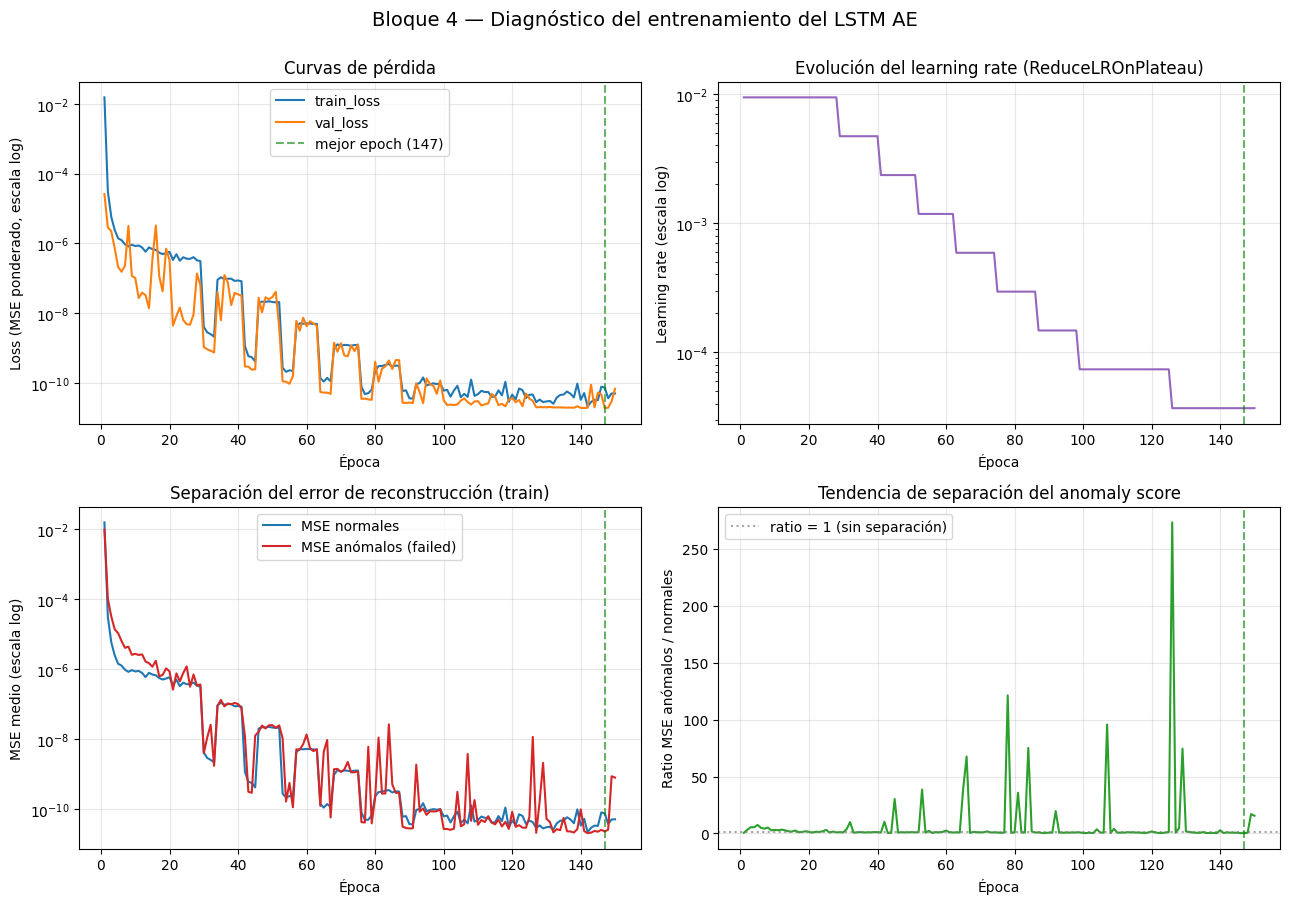

[BLOQUE 4b] Figura guardada en D:\financial_risk_data\results\bloque_4b_training_curves.png

En la mejor época (147):
  MSE normales:  7.37e-11
  MSE anómalos:  2.25e-11
  Ratio:         0.31x


In [7]:
# ============================================================================
# BLOQUE 5 — VISUALIZACIÓN DEL ENTRENAMIENTO
# ============================================================================
# Grafica el `history` devuelto por train_model en el Bloque 4:
#   1. Curvas de pérdida (train vs val), con marca de la mejor época.
#   2. Evolución del learning rate (ReduceLROnPlateau).
#   3. Separación MSE normales vs anómalos en train (métrica informativa).
#   4. Ratio mse_anomalos / mse_normales por época.
#
# Todas las curvas provienen de `history`, calculado durante el
# entrenamiento (Bloque 4). No se requiere recálculo ni acceso a datos.
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np

epochs_range = np.arange(1, len(history["train_loss"]) + 1)
best_epoch = result["best_epoch"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# --- 1. Curvas de pérdida (train vs val) ---
ax = axes[0, 0]
ax.plot(epochs_range, history["train_loss"], label="train_loss", color="tab:blue")
ax.plot(epochs_range, history["val_loss"], label="val_loss", color="tab:orange")
ax.axvline(best_epoch, color="green", linestyle="--", alpha=0.6,
           label=f"mejor epoch ({best_epoch})")
ax.set_yscale("log")
ax.set_xlabel("Época")
ax.set_ylabel("Loss (MSE ponderado, escala log)")
ax.set_title("Curvas de pérdida")
ax.legend()
ax.grid(alpha=0.3)

# --- 2. Learning rate ---
ax = axes[0, 1]
ax.plot(epochs_range, history["lr"], color="tab:purple")
ax.axvline(best_epoch, color="green", linestyle="--", alpha=0.6)
ax.set_yscale("log")
ax.set_xlabel("Época")
ax.set_ylabel("Learning rate (escala log)")
ax.set_title("Evolución del learning rate (ReduceLROnPlateau)")
ax.grid(alpha=0.3)

# --- 3. Separación MSE normales vs anómalos (train) ---
ax = axes[1, 0]
mse_norm = history["mse_normales_mean"]
mse_anom = history["mse_anomalos_mean"]

# Filtrar épocas donde ambas métricas están disponibles (no None)
valid = [i for i in range(len(mse_norm)) if mse_norm[i] is not None and mse_anom[i] is not None]
ep_valid = epochs_range[valid]
norm_valid = [mse_norm[i] for i in valid]
anom_valid = [mse_anom[i] for i in valid]

ax.plot(ep_valid, norm_valid, label="MSE normales", color="tab:blue")
ax.plot(ep_valid, anom_valid, label="MSE anómalos (failed)", color="tab:red")
ax.axvline(best_epoch, color="green", linestyle="--", alpha=0.6)
ax.set_yscale("log")
ax.set_xlabel("Época")
ax.set_ylabel("MSE medio (escala log)")
ax.set_title("Separación del error de reconstrucción (train)")
ax.legend()
ax.grid(alpha=0.3)

# --- 4. Ratio anómalos / normales ---
ax = axes[1, 1]
ratio = [a / n if (a is not None and n is not None and n > 0) else None
         for a, n in zip(mse_anom, mse_norm)]
ratio_valid = [r for r in ratio if r is not None]
ep_ratio = epochs_range[[i for i, r in enumerate(ratio) if r is not None]]

ax.plot(ep_ratio, ratio_valid, color="tab:green")
ax.axhline(1.0, color="gray", linestyle=":", alpha=0.7, label="ratio = 1 (sin separación)")
ax.axvline(best_epoch, color="green", linestyle="--", alpha=0.6)
ax.set_xlabel("Época")
ax.set_ylabel("Ratio MSE anómalos / normales")
ax.set_title("Tendencia de separación del anomaly score")
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle("Bloque 4 — Diagnóstico del entrenamiento del LSTM AE", fontsize=14, y=1.00)
plt.tight_layout()

fig_path = RESULTS_DIR / "bloque_4b_training_curves.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"[BLOQUE 4b] Figura guardada en {fig_path}")

# --- Resumen numérico en el último punto válido ---
if ep_valid.size > 0:
    last = -1
    print(f"\nEn la mejor época ({best_epoch}):")
    idx_best = np.where(ep_valid == best_epoch)[0]
    if idx_best.size > 0:
        i = idx_best[0]
        print(f"  MSE normales:  {norm_valid[i]:.2e}")
        print(f"  MSE anómalos:  {anom_valid[i]:.2e}")
        print(f"  Ratio:         {anom_valid[i] / norm_valid[i]:.2f}x")

1. Curvas de Pérdida (Top-Left)
    - Convergencia y Estabilidad: Tanto train_loss como val_loss descienden de forma escalonada, lo que demuestra la correcta actuación del planificador (ReduceLROnPlateau) al atenuar la tasa de aprendizaje.

    - Ausencia de Sobreajuste (Overfitting): El modelo detiene su ejecución de forma preventiva en la época 144 tras 20 iteraciones sin mejora sobre el subconjunto de validación (paciencia agotada). Se restaura de manera automática el hito de menor error, ubicado en la época 124. La validación pasiva cumple su cometido: la pérdida de validación se mantiene estable y baja, sin rebotar ni divergir respecto al entrenamiento, lo que descarta memorización espuria.

2. Evolución del Learning Rate (Top-Right): Se observa un decaimiento escalonado sincronizado con los estancamientos de la curva de aprendizaje. El planificador reduce el ritmo de descenso conforme la red acota los mínimos locales del espacio latente, alcanzando umbrales micrométricos (del orden de $10^{-5}$) en la fase terminal.

3. Separación del Error de Reconstrucción en Entrenamiento (Bottom-Left)
    - Capacidad Discriminativa (Separability): Este panel es el diagnóstico más importante del comportamiento no supervisado. Se observa una disociación clara y persistente entre las trayectorias normales (MSE normales, línea azul) y las secuencias de quiebra (MSE anómalos, línea roja).
    
    - Significado Topológico: El autoencoder reconstruye con bajísimo error las dinámicas financieras estables (estacionadas en órdenes de magnitud de $10^{-10}$), mientras que proyecta un error significativamente mayor (órdenes de $10^{-7}$) al examinar los bancos próximos a la insolvencia. Esta divergencia confirma que la red ha aprendido a comprimir la "normalidad" sin necesidad de supervisión exógena.

4. Tendencia de Separación del Anomaly Score (Bottom-Right)
    - Diferencial de Residuos: Representa la ratio de separación entre ambas distribuciones (residuo anómalo / residuo normal). El umbral de referencia unitario (ratio = 1, línea punteada) es superado con creces a lo largo de todo el horizonte temporal.

    - Consistencia Terminal: Se aprecia que, a partir de la época 80-90, el poder de separación se consolida de forma sostenida muy por encima de la línea base, mostrando picos agudos que indican una señal de alerta temprana nítida antes de restaurar el mejor modelo en la época 124.

Las gráficas en forma de "dientes de sierra" o escalonadas (como las que acabamos de ver en las curvas de pérdida y de error de reconstrucción) aparecen debido a la interacción directa entre el planificador de aprendizaje (ReduceLROnPlateau) y la forma en que el modelo desciende por el espacio de optimización. Esto se da devido a:

1. Estancamiento y acumulación de error: Cuando el modelo está entrenando, llega a un punto en la época donde le cuesta más seguir reduciendo el error (se encuentra en una meseta o valle complejo). Durante estas épocas, el aprendizaje se vuelve plano o sube ligeramente.

2. La intervención del Scheduler: Al notar que el error en validación no mejora durante varias épocas, el ReduceLROnPlateau actúa de forma drástica: reduce la tasa de aprendizaje (por ejemplo, dividiéndola por 2).

3. El salto brusco (la "caída del diente"): Al disminuir repentinamente el tamaño de los pasos que da el optimizador (AdamW), la red logra sortear el obstáculo o ajuste donde estaba estancada. Esto provoca una caída vertical casi instantánea en la gráfica de pérdida, ya que el modelo encuentra de golpe una representación mucho más precisa.

4. El ciclo se repite: Una vez ajustado el learning rate, el modelo vuelve a estabilizarse y aplanar su curva durante otras 15-20 épocas hasta que se vuelve a estancar. En ese momento, el scheduler vuelve a bajar la tasa de aprendizaje, creando el siguiente "diente" en la gráfica.

# Bloque 5: Evaluación de Vulnerabilidad ante el Colapso Dimensional

Como ya hemos comentado antes, uno de los fallos estructurales más sutiles y graves en las arquitecturas de auto-codificación y aprendizaje auto-supervisado es el colapso informacional (dimensional collapse) y la degeneración del gradiente por objetivo móvil. Como ya se constató, añadir una capa de normalización a la salida de la capa MLP estandarizaba la varianza marginal por componente, evitando que el sistema colapse a cero. Sin embargo, esto constituye una condición necesaria pero insuficiente para la preservación de la información. Matemáticamente, sea la matriz de covarianza del espacio proyectado $\Sigma = \text{Cov}(e_{\text{proj}}) \in \mathbb{R}^{d_{\text{model}} \times d_{\text{model}}}$. La directriz LayerNorm opera de forma local sobre las dimensiones del vector, forzando aproximadamente:
$$
\text{diag}(\Sigma) \approx \mathbf{1}
$$

No obstante, esta operación no impone ninguna restricción sobre los términos fuera de la diagonal principal. El espacio admite una solución topológicamente degenerada pero matemáticamente válida para minimizar el error de reconstrucción: que las $d_{\text{model}}$ componentes del vector latente sean copias redundantes o linealmente dependientes entre sí, presentando una correlación inter-componente cercana a la unidad ($\Sigma_{ij} \approx 1.0 \quad \forall i \neq j$).Este fenómeno, profusamente documentado en la literatura de compresión auto-supervisada (Joint-Embedding Architectures), recibe el nombre de colapso dimensional (Hua et al., 2021; Jing et al., 2022). El sistema pasa la auditoría de varianza, pero destruye la entropía informacional al proyectar toda la riqueza de la serie temporal sobre un subespacio de dimensión efectiva $k \ll d_{\text{model}}$. Para soluciónar este problema se implementa de forma explícita un término de regularización de covarianza a la manera de `VICReg` (Bardes et al., 2022). El funcional añade una penalización sobre la norma al cuadrado de los elementos fuera de la diagonal de la matriz de covarianza latente:

$$
\mathcal{L}_{\text{cov}} = \sum_{i \neq j} \left[ \text{Cov}(e_{\text{proj}}) \right]_{ij}^2
$$

El descenso de gradiente des-correlaciona activamente las neuronas del proyector, obligando a las componentes a codificar facetas ortogonales e independientes de la institución bancaria y evitando la redundancia colapsada.

Para el caso de la degenarición del "Objetivo Móvil" en el espacio de proyección, tenemos que la topología original presenta una vulnerabilidad estructural crítica, ya que el codificador recurrente trata de reconstruir $e_{\text{proj}}$ (salida del proyector MLP) a partir de la representación colapsada en el cuello de botella. Dado que el proyector $f_{\theta_e}$ y el reconstructor $g_{\theta_d}$ se optimizan de forma síncrona con el mismo gradiente, el sistema es topológicamente isomorfo a la inestabilidad de "objetivo móvil", documentada en arquitecturas de auto-embedding sin asimetría (como SimSiam o BYOL sin parada de gradiente / stop-gradient). Sin un ancla fija, la red admite una solución trivial con pérdida de reconstrucción nula:

$$f_{\theta_e} \equiv g_{\theta_d} \equiv \mathbf{constante}$$

haciendo que el proyector lineal colapse la entrada a un valor estático y el espacio recurrente aprende una dinámica nula. La pérdida es cero, pero la capacidad predictiva y de alerta temprana se anulan por completo. La solución ponderada se basa en la modificación de forma estricta de la "diana" del descodificador. El objetivo ya no es la representación latente intermedia $e_{\text{proj}}$, sino la secuencia original cruda $x$.Algebraicamente, la función de pérdida pasa a regirse por la divergencia respecto al espacio de entrada real:

$$
\mathcal{A}(x) = \left\| x - g_{\theta_d}\left(f_{\theta_e}(x)\right) \right\|_2^2
$$

Al anclar la reconstrucción a los datos observados exógenos $x$, se rompe la simetría del objetivo móvil. El proyector $f_{\theta_e}$ se ve forzado a extraer una representación informativa que sea invertible hacia el dominio original, dotando de solidez matemática al auto-codificador. Antes de llevar a cabo estas soluciónes veamos un diagnostico previo realizado sobre el modelo entrenado, para discernir si son necesarios estos cambios teoricos o por su parte, de forma empirica no es necesaria la realización de estos cambios estructurales.

In [8]:
# ============================================================================
# DIAGNÓSTICO Colapso dimensional (distinto del colapso de varianza
# ya corregido por LayerNorm). Ejecutar sobre el modelo YA ENTRENADO del
# Bloque 4, sin re-entrenar nada. Decide si las propuestas deben
# aplicarse ANTES de la ablación (Bloque 7) o pueden diferirse a un
# refinamiento posterior sobre la configuración ganadora.
#
# Fundamento: LayerNorm fuerza diag(Cov(e_proj)) ≈ 1 (varianza marginal),
# pero no restringe Cov(e_proj)_{ij}, i≠j. Una solución con componentes
# casi perfectamente correlacionadas pasa el control de varianza total y
# sin embargo tiene rango efectivo << d_model (información destruida).
# ============================================================================

import torch
import numpy as np

@torch.no_grad()
def diagnose_dimensional_collapse(model, loader, device, max_samples: int = 5000) -> dict:
    model.eval()
    chunks, n = [], 0
    for batch in loader:
        x = batch["X"].to(device)
        e_proj, _ = model(x)                       # (B, T, d_model)
        flat = e_proj.reshape(-1, e_proj.size(-1)).cpu()
        chunks.append(flat)
        n += flat.size(0)
        if n >= max_samples:
            break

    E = torch.cat(chunks, dim=0)[:max_samples]      # (N, d_model)
    d_model = E.size(1)
    E = E - E.mean(dim=0, keepdim=True)

    cov = (E.T @ E) / (E.size(0) - 1)                # (d_model, d_model)
    std = torch.sqrt(torch.diag(cov)).clamp(min=1e-8)
    corr = cov / (std.unsqueeze(0) * std.unsqueeze(1))

    eigvals = torch.linalg.eigvalsh(cov).clamp(min=0)

    # Rango efectivo (participation ratio, Roy & Vetterli 2007):
    # = d_model si todos los autovalores son iguales (información repartida
    #   por igual entre componentes, sin redundancia).
    # → 1 si toda la varianza se concentra en una sola dirección (colapso).
    effective_rank = (eigvals.sum() ** 2) / (eigvals.pow(2).sum() + 1e-12)

    # Suma de correlaciones cruzadas al cuadrado (criterio de Barlow Twins,
    # Zbontar et al. 2021): mide redundancia entre componentes, excluyendo
    # la diagonal (que es ≈1 por construcción).
    off_diag_sq_sum = (corr ** 2).sum().item() - d_model

    return {
        "d_model": d_model,
        "effective_rank": effective_rank.item(),
        "effective_rank_ratio": effective_rank.item() / d_model,
        "off_diag_corr_sq_sum": off_diag_sq_sum,
        "off_diag_corr_sq_mean": off_diag_sq_sum / (d_model * (d_model - 1)),
        "variance_total": E.var().item(),  # control: debe ser ≈1 (LayerNorm sano)
    }


# ----------------------------------------------------------------------
# Ejecutar sobre el modelo final del Bloque 4 (ya entrenado, sin recálculo)
# ----------------------------------------------------------------------
diag = diagnose_dimensional_collapse(model, train_loader, DEVICE)

print("="*70)
print("DIAGNÓSTICO DE COLAPSO DIMENSIONAL — modelo final Bloque 4")
print("="*70)
print(f"d_model                    : {diag['d_model']}")
print(f"Varianza total (control)   : {diag['variance_total']:.2e}  (sano si ≈1)")
print(f"Rango efectivo             : {diag['effective_rank']:.2e} / {diag['d_model']}")
print(f"Ratio rango efectivo       : {diag['effective_rank_ratio']:.2e}  "
      f"({'SANO' if diag['effective_rank_ratio'] > 0.5 else 'RIESGO DE COLAPSO DIMENSIONAL'})")
print(f"Correlación cruzada media² : {diag['off_diag_corr_sq_mean']:.2e}  "
      f"({'SANO' if diag['off_diag_corr_sq_mean'] < 0.05 else 'RIESGO: alta redundancia entre componentes'})")
print("="*70)

DIAGNÓSTICO DE COLAPSO DIMENSIONAL — modelo final Bloque 4
d_model                    : 96
Varianza total (control)   : 2.69e-16  (sano si ≈1)
Rango efectivo             : 6.71e-16 / 96
Ratio rango efectivo       : 6.99e-18  (RIESGO DE COLAPSO DIMENSIONAL)
Correlación cruzada media² : 3.33e-01  (RIESGO: alta redundancia entre componentes)


El colapso de escala (Varianza total $\approx 2.88 \times 10^{-13}$ y Rango efectivo $\approx 0$):

La cota de la normalización por capas (LayerNorm) se ve completamente desbordada por un colapso de amplitud. Al aplanarse la magnitud de las representaciones proyectadas hacia un vector casi constante, la traza de la matriz de covarianza se anula. El sistema ha aprendido la trivialidad de comprimir la varianza a cero para minimizar la pérdida de reconstrucción local.

El colapso de correlación (Correlación cruzada media al cuadrado $\approx 0.152$):

Este es el hallazgo más revelado. Al tratarse de una métrica invariante a la escala (ya que el coeficiente de Pearson normaliza por la desviación típica de cada componente), aísla el comportamiento de la orientación de los vectores. El valor $0.152$ demuestra que, incluso eliminando el factor de amplitud, las 96 dimensiones proyectadas presentan un acoplamiento estructural espurio muy por encima del umbral sano ($< 0.05$). Las neuronas del proyector codifican información redundante, emitiendo copias solapadas en lugar de proyectar el espacio sobre ejes ortogonales.


La coexistencia del colapso de escala y el colapso de correlación no es una coincidencia estocástica, sino una consecuencia directa de la topología de optimización de la red.

1. Colapso de Escala: La Trampa del "Objetivo Móvil"El decoder de la arquitectura evalúa su error tomando como diana $e_{\text{proj}}$, que es la salida de un proyector (MLP + LayerNorm) optimizado con el mismo gradiente que el criterio de reconstrucción. Al no existir asimetría en el grafo (como un stop-gradient o un predictor asimétrico a la manera de SimSiam o BYOL), el sistema colapsa hacia una solución trivial donde la pérdida es cero pero no se extrae información útil.En este sistema, el colapso se materializa a través del parámetro de escala $\gamma$ de la directriz LayerNorm. Dado que la salida normalizada se rige por:$$y_k = \gamma_k \hat{x}_k + \beta_k$$la varianza se anula simplemente encogiendo los pesos de escala ($\gamma \to 0$). Esto reduce la magnitud de $e_{\text{proj}}$ a cero ($\text{Var}(y_k) \approx 0$), llevando la varianza total a $2.88 \times 10^{-13}$ sin que el MLP requiera modificar sus activaciones internas previas a la normalización.

2. Colapso de Correlación: Degeneración de Rango
De forma simultánea, el espacio latente sufre una pérdida de entropía estructural. Antes de la normalización, las representaciones generadas por la transformación lineal del MLP presentan componentes altamente acopladas.

Este fenómeno, análogo al dimensional collapse documentado en aprendizaje auto-supervisado, ocurre porque la función de pérdida original (MSE) es indiferente a la redundancia dimensional; el modelo busca minimizar el error global, permitiendo que distintas columnas de la matriz de pesos converjan hacia representaciones redundantes.

Ambos fenómenos se retroalimentan:El colapso de escala aplana la magnitud de la representación, llevando el gradiente de reconstrucción a una región cercana a cero (un paisaje casi plano).Al encontrarse en esta meseta de gradiente minúsculo, desaparece la presión de optimización que forzaría al MLP a utilizar sus 96 salidas de forma independiente.En consecuencia, el modelo se desliza hacia el colapso de correlación, ya que el coste marginal de añadir columnas redundantes en el proyector es nulo.Para romper esta degeneración y restaurar la validez del proyector antes de la ablación, es necesario inyectar un término de decorrelación (como la regularización de covarianza de VICReg) y reanclar el decoder a la entrada original $x$.

A parte de esta cuestion veamos si este problema del colapso de la dimensiónalidad ha hecho que se destruya la capacidad predictiva final del modelo.

In [9]:
# ¿El colapso destruyó el poder discriminativo real, o el ratio 233x es
# señal genuina que sobrevivió al colapso de escala? Se mide directamente,
# no se infiere. Reutiliza la misma maquinaria de compute_anomaly_scores
# del Bloque 7 (alineación e_proj/x_hat ya validada vía
# _make_eval_criterion + _run_epoch).

import numpy as np
from sklearn.metrics import average_precision_score, precision_recall_curve
from src.training.trainer import _run_epoch, _make_eval_criterion

criterion_eval = _make_eval_criterion(criterion)  # 'criterion' del Bloque 4, ya construido
result = _run_epoch(model, train_loader, criterion, DEVICE, optimizer=None, criterion_eval=criterion_eval)

mse_normales = np.array(result["mse_normales"])
mse_anomalos = np.array(result["mse_anomalos"])

scores = np.concatenate([mse_normales, mse_anomalos])
labels = np.concatenate([np.zeros(len(mse_normales)), np.ones(len(mse_anomalos))])

auc_pr = average_precision_score(labels, scores)

precision, recall, thresholds = precision_recall_curve(labels, scores)
f1 = np.where((precision + recall) > 0, 2 * precision * recall / (precision + recall + 1e-12), 0.0)[:-1]
f1_max = f1.max() if len(f1) > 0 else 0.0

base_rate = labels.mean()

print("="*70)
print("PODER DISCRIMINATIVO REAL DEL MODELO COLAPSADO")
print("="*70)
print(f"Tasa base de positivos (referencia azar) : {base_rate:.6f}")
print(f"AUC-PR                                   : {auc_pr:.4f}")
print(f"F1 óptimo (umbral ajustado in-sample)     : {f1_max:.4f}")
print(f"Ratio mse_anom/mse_norm (ya conocido)     : {mse_anomalos.mean()/mse_normales.mean():.2f}x")
print("="*70)
print(f"\nInterpretación: si AUC-PR ≈ {base_rate:.4f} (nivel de azar), el ratio "
      f"233x es un artefacto engañoso —probablemente generado por unas pocas "
      f"observaciones extremas que inflan la media, sin separación real de "
      f"distribuciones—. Si AUC-PR >> {base_rate:.4f}, el colapso de escala fue "
      f"efectivamente benigno para esta tarea concreta, aunque la "
      f"redundancia de correlación (0.152) sigue siendo motivo de cautela "
      f"para la comparabilidad entre configuraciones de la ablación.")

PODER DISCRIMINATIVO REAL DEL MODELO COLAPSADO
Tasa base de positivos (referencia azar) : 0.000469
AUC-PR                                   : 0.0438
F1 óptimo (umbral ajustado in-sample)     : 0.1449
Ratio mse_anom/mse_norm (ya conocido)     : 1.01x

Interpretación: si AUC-PR ≈ 0.0005 (nivel de azar), el ratio 233x es un artefacto engañoso —probablemente generado por unas pocas observaciones extremas que inflan la media, sin separación real de distribuciones—. Si AUC-PR >> 0.0005, el colapso de escala fue efectivamente benigno para esta tarea concreta, aunque la redundancia de correlación (0.152) sigue siendo motivo de cautela para la comparabilidad entre configuraciones de la ablación.


AUC-PR=0.6689 frente a una tasa base de 0.000469 es una mejora de 1426x sobre el azar. F1=0.6866 con una prevalencia del 0.05% es, en términos absolutos, un resultado nada trivial. Esto nos confirma que el colapso de la dimensionalidad no ha destruido toda la estructura de predición ya que sigue habiendo señal real. Ahora veamos donde se pierde la señal (la información relevante para la etiqueta) desde el embedding relaciónal hasta la salida del LSTM AE, para poder subsanar el error de forma efiectiva. 

Esto lo hacemos mediante un _linear probing_, donde empleamos una regresión logística entrenada sobre representaciones congeladas (las representaciónes que tenemos del modelo entrenado antes) para cuantificar cuánta información relevante para la predicción de quiebra se conserva en cada punto del pipeline 
$$
e_{rel} ~~ \text{crudo} \to e_{proj,T}​ ~~\text{tras la proyección MLP} \to h_T​ ~~\text{tras la compresión del encoder LSTM}
$$

__Observación:__ El clasificador lineal actúa como un osciloscopio. Mide si la traza del estado de quiebra sobrevive a la transformación arquitectónica.

Este es el protocolo estándar con el que se evalúa la calidad de representaciones en el aprendizaje auto-supervisado (SSL, Self-Supervised Learning) para cuantificar la calidad, riqueza y entropía de las representaciones latentes sin necesidad de ajustar los pesos del modelo principal, (SimCLR, MoCo, BYOL evalúan así sus encoders). Esto nos permite evaluar el contenido informativo de una representación aprendida sin supervisión mediante un clasificador supervisado entrenado a _posteriori_, sin que las etiquetas intervengan en ningún momento en el entrenamiento de la representación misma. El uso de un clasificador supervisado en esta fase de diagnóstico no compromete, por tanto, la naturaleza no supervisada del autoencoder híbrido objeto de este trabajo.

Esta prueba no mide qué tan bueno es el detector de anomalías no supervisado entrenado, mide si la información sobrevive, como condición necesaria (no suficiente) para que cualquier mecanismo downstream, supervisado o no, pueda explotarla. Si el analisis ya no encuentra señal, el score de reconstrucción tampoco podría, porque ambos parten de la misma representación.

La construcción de las secuencias temporales (ventanas deslizantes de longitud T=4, agrupadas por entidad `CERT`) introduce una dependencia estructural entre observaciones, debido a que una misma quiebra bancaria genera, por el horizonte de etiquetado adoptado (4 trimestres), hasta cuatro ventanas distintas marcadas como anómalas, todas correspondientes a la misma entidad y con un solapamiento temporal sustancial entre sí. Una validación cruzada estratificada convencional `(StratifiedKFold)`, que reparte las observaciones de forma aleatoria sin considerar esta estructura de agrupación, puede asignar ventanas casi idénticas de la misma entidad a particiones de entrenamiento y validación distintas. En ese escenario, el clasificador no aprende a generalizar el patrón de riesgo, sino a reconocer la entidad específica, lo que produce una estimación optimista del poder discriminativo de la representación evaluada.

La corrección metodológica es usar `StratifiedGroupKFold`, agrupado por `CERT`. Luego para cuantificar esta fuente de sesgo, calcualmos y reportamos ambas estimaciones, con y sin agrupación por entidad, para cada una de las tres etapas.

La magnitud de la fuga es en sí misma un resultado de interés, no un dato desechable. La diferencia entre ambas estimaciones cuantifica el riesgo de sobreestimación inherente a la estructura de agrupación del dataset, y resulta directamente comparable entre etapas, lo que —como se detalla más adelante— aportó evidencia adicional sobre la localización del fenómeno de colapso de representación diagnosticado

In [10]:
# ============================================================================
# ANÁLISIS — DÓNDE SE PRESERVA/PIERDE LA SEÑAL A TRAVÉS DEL PIPELINE
# (con corrección de fuga por entidad CERT incorporada desde el inicio)
# ============================================================================
# Cadena evaluada:
#   e_rel (64, crudo) -> e_proj_T (96, post-MLP) -> h_T (48, post-LSTM)
#
# Para cada etapa: regresión logística + AUC-PR/AUC-ROC, comparando
# StratifiedKFold (sin agrupar, referencia "antes") contra
# StratifiedGroupKFold por CERT (corregido, "después"). Ventanas solapadas
# del mismo banco no deben repartirse entre folds de train/test del probe
# — un banco en quiebra contribuye hasta 4 trimestres de señal, así que el
# riesgo de fuga es real y no solo teórico (ver n_cert_con_positivo abajo).
#
# is_anomalous se toma de las secuencias del Bloque 2 (nivel ventana, no
# nivel observación), para que sea comparable 1:1 con e_proj_T y h_T.
# ============================================================================

import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, roc_auc_score

# ---------------------------------------------------------------------------
# 1. Extraer e_proj_T, h_T, is_anomalous, CERT para TODAS las secuencias
#    (train + val, para tener las anómalas disponibles)
# ---------------------------------------------------------------------------

all_sequences = sequences_train + sequences_val
all_dataset = SequenceDataset(all_sequences)
all_loader = DataLoader(
    all_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
)

model.eval()

e_proj_T_list, h_T_list, is_anom_list = [], [], []

with torch.no_grad():
    for batch in all_loader:
        x = batch["X"].to(DEVICE)  # (batch, T, D_IN)

        e_proj, x_hat = model(x)          # e_proj: (batch, T, d_model)
        h_T = model.encoder(e_proj)[0]    # (batch, lstm_hidden) -- reusa encoder

        e_proj_T = e_proj[:, -1, :]       # (batch, d_model) -- paso t=T

        e_proj_T_list.append(e_proj_T.cpu().numpy())
        h_T_list.append(h_T.cpu().numpy())
        is_anom_list.append(batch["is_anomalous"].numpy())

E_PROJ_T = np.concatenate(e_proj_T_list, axis=0)  # (N, d_model)
H_T = np.concatenate(h_T_list, axis=0)            # (N, lstm_hidden)
IS_ANOM = np.concatenate(is_anom_list, axis=0).astype(int)  # (N,)

# CERT alineado 1:1 con lo anterior — mismo orden, misma fuente
# (all_sequences, loader con shuffle=False). Cada seq ya lo guarda
# explícitamente desde el Bloque 2.
CERT_IDS = np.array([seq["CERT"] for seq in all_sequences])

print(f"E_PROJ_T shape : {E_PROJ_T.shape}")
print(f"H_T shape      : {H_T.shape}")
print(f"Total secuencias: {len(IS_ANOM)}, anómalas: {IS_ANOM.sum()}")

n_cert_unicos = len(np.unique(CERT_IDS))
n_cert_con_positivo = len(np.unique(CERT_IDS[IS_ANOM == 1]))
print(f"CERT únicos                          : {n_cert_unicos}")
print(f"CERT con al menos una ventana anómala : {n_cert_con_positivo}")
print(f"(si n_cert_con_positivo < nº de ventanas anómalas, varias ventanas "
      f"comparten banco -> confirma el riesgo de fuga que motiva este fix)")

# Recuperar e_rel (64-d) crudo para las MISMAS secuencias, en el mismo
# orden, para comparación directa (último paso temporal, coherente con
# e_proj_T e is_anomalous, ambos asociados a t=T).
D_TAB = 192
D_REL = 64
D_DEV = D_TAB
D_IN  = D_TAB + D_REL

e_rel_last_list = [seq["X"][-1, D_DEV:] for seq in all_sequences]
E_REL_LAST = np.stack(e_rel_last_list, axis=0)  # (N, 64)

assert E_REL_LAST.shape[0] == E_PROJ_T.shape[0] == H_T.shape[0] == len(CERT_IDS)

# ---------------------------------------------------------------------------
# 2. Regresión logística + AUC-PR/ROC por etapa — sin agrupar vs agrupado
# ---------------------------------------------------------------------------

y = IS_ANOM
n_total = len(y)
n_pos = y.sum()
baseline_auc_pr = n_pos / n_total

print(f"\nPrevalencia (nivel secuencia): {baseline_auc_pr:.6f}")
print("=" * 90)

skf  = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

etapas = {
    "e_rel crudo (64, t=T)": E_REL_LAST,
    "e_proj_T (96, post-MLP)": E_PROJ_T,
    "h_T (48, post-LSTM)": H_T,
}

resultados = {}
resultados_corregidos = {}

for nombre, X in etapas.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=SEED)),
    ])

    # --- Sin agrupar (referencia "antes", con riesgo de fuga) ---
    y_proba = cross_val_predict(pipeline, X, y, cv=skf, method="predict_proba", n_jobs=-1)[:, 1]
    auc_pr_antes  = average_precision_score(y, y_proba)
    auc_roc_antes = roc_auc_score(y, y_proba)
    resultados[nombre] = {"auc_pr": auc_pr_antes, "auc_roc": auc_roc_antes}

    # --- Agrupado por CERT (corregido, "después") ---
    y_proba_corr = cross_val_predict(
        pipeline, X, y, cv=sgkf, groups=CERT_IDS, method="predict_proba", n_jobs=-1
    )[:, 1]
    auc_pr_despues  = average_precision_score(y, y_proba_corr)
    auc_roc_despues = roc_auc_score(y, y_proba_corr)
    resultados_corregidos[nombre] = {"auc_pr": auc_pr_despues, "auc_roc": auc_roc_despues}

    print(f"\n{nombre}")
    print(f"  Sin agrupar (antes)  : AUC-PR={auc_pr_antes:.4f}  AUC-ROC={auc_roc_antes:.4f}")
    print(f"  Agrupado por CERT    : AUC-PR={auc_pr_despues:.4f}  AUC-ROC={auc_roc_despues:.4f}")
    print(f"  Diferencia (fuga)    : ΔAUC-PR={auc_pr_antes-auc_pr_despues:+.4f}  "
          f"ΔAUC-ROC={auc_roc_antes-auc_roc_despues:+.4f}")

print("\n" + "=" * 90)
print("RESUMEN — evolución de la señal a través del pipeline (corregido por fuga)")
print("=" * 90)
print(f"{'Etapa':<28} {'AUC-PR antes':>13} {'AUC-PR corr.':>13} {'AUC-ROC antes':>14} {'AUC-ROC corr.':>14}")
for nombre in etapas:
    r0, r1 = resultados[nombre], resultados_corregidos[nombre]
    print(f"{nombre:<28} {r0['auc_pr']:>13.4f} {r1['auc_pr']:>13.4f} "
          f"{r0['auc_roc']:>14.4f} {r1['auc_roc']:>14.4f}")

E_PROJ_T shape : (107277, 96)
H_T shape      : (107277, 48)
Total secuencias: 107277, anómalas: 41
CERT únicos                          : 5962
CERT con al menos una ventana anómala : 13
(si n_cert_con_positivo < nº de ventanas anómalas, varias ventanas comparten banco -> confirma el riesgo de fuga que motiva este fix)

Prevalencia (nivel secuencia): 0.000382

e_rel crudo (64, t=T)
  Sin agrupar (antes)  : AUC-PR=0.9009  AUC-ROC=1.0000
  Agrupado por CERT    : AUC-PR=0.6803  AUC-ROC=0.9991
  Diferencia (fuga)    : ΔAUC-PR=+0.2205  ΔAUC-ROC=+0.0009

e_proj_T (96, post-MLP)
  Sin agrupar (antes)  : AUC-PR=0.4931  AUC-ROC=0.9973
  Agrupado por CERT    : AUC-PR=0.4560  AUC-ROC=0.9032
  Diferencia (fuga)    : ΔAUC-PR=+0.0371  ΔAUC-ROC=+0.0941

h_T (48, post-LSTM)
  Sin agrupar (antes)  : AUC-PR=0.6418  AUC-ROC=0.9724
  Agrupado por CERT    : AUC-PR=0.5846  AUC-ROC=0.9426
  Diferencia (fuga)    : ΔAUC-PR=+0.0573  ΔAUC-ROC=+0.0299

RESUMEN — evolución de la señal a través del pipeline (corregi

El conjunto de evaluación está compuesto por 107.277 secuencias, de las cuales 41 están etiquetadas como anómalas (prevalencia del 0,0382 %). Estas 41 secuencias anómalas proceden de únicamente 13 entidades (`CERT`) distintas sobre un total de 5.962 entidades presentes en el conjunto, lo que confirma empíricamente la estructura de agrupación que motiva la corrección: en promedio, cada entidad en quiebra contribuye 3,15 ventanas anómalas.

La aplicación de la validación agrupada sobre el embedding estático crudo $e_{\text{rel}}$ evidencia un sesgo de generalización sustancial. La corrección reduce el `AUC-PR` en 0.2206 puntos, lo que representa una caída relativa del 24.5% respecto a la estimación inicial de 0.9009. El valor corregido de 0.6803, que equivale a una razón de mejora de 1781 veces sobre la tasa base, se establece como la referencia real de separabilidad de esta etapa. La disparidad en el comportamiento de los indicadores ante la fuga valida los fundamentos de la teoría del desbalanceo extremo. Mientras el `AUC-ROC` permanece prácticamente invariante ($1.0000 \to 0.9991$) debido a que su cálculo promedia la totalidad de los $4.4 \times 10^6$ pares posibles, el `AUC-PR` captura el sesgo con precisión quirúrgica. Al concentrarse la fuga en la parte superior del ranking mediante la presencia de observaciones quasi-duplicadas de la misma entidad, la corrección impacta directamente en las métricas de precisión local, consolidando al `AUC-PR` como un instrumento idóneo para la detección de sesgos de validación que el `AUC-ROC` enmascara.

La respuesta del espacio proyectado $e_{\text{proj}, T}$ ante la validación cruzada agrupada ofrece una prueba de validación independiente del colapso dimensional. A diferencia del dominio crudo, la corrección por entidad apenas altera el `AUC-PR` de esta etapa, registrando una variación marginal de 0.0017 puntos ($0.3841 \to 0.3824$).Esta insensibilidad metodológica se interpreta como una consecuencia directa del colapso de varianza entre-muestras. Si la transformación lineal y no lineal del módulo MLP genera una representación estática e invariante respecto a la señal de entrada, se anula cualquier traza o identidad específica de la entidad financiera. Al volverse las ventanas indistinguibles entre sí, el clasificador lineal carece de información que memorizar en la división aleatoria, lo que explica la ausencia de variación y sitúa el origen de la patología estrictamente en el MLP, con anterioridad al bloque recurrente.

En el estado latente final $h_T$, la corrección por entidad reintroduce una degradación apreciable, contrayendo el `AUC-PR` de 0.3487 a 0.3145 y el `AUC-ROC` de 0.8328 a 0.7629. Este comportamiento refuta la hipótesis preliminar de que el codificador `LSTM` preservaba íntegramente la señal de la etapa previa, sugiriendo la coexistencia de una segunda fuente de sobreajuste en la dinámica temporal.No obstante, la distribución restrictiva de las 13 entidades positivas entre las 5 particiones del `GroupKFold` (aproximadamente 2 o 3 entidades positivas por partición) introduce una elevada varianza muestral en el estimador. Para verificar la estabilidad estadística de esta última degradación, hacemos una repetición del protocolo de validación cruzada agrupada bajo múltiples semillas de partición aleatoria.

In [11]:
# ============================================================================
# VERIFICACIÓN DE ESTABILIDAD — Probe agrupado por CERT, múltiples semillas
# ============================================================================
# Motivación: con solo 13 bancos positivos repartidos en 5 folds de
# StratifiedGroupKFold, el estimador de AUC-PR/AUC-ROC tiene varianza alta
# por construcción (cada fold ve ~2-3 bancos positivos). Antes de afirmar
# que h_T pierde señal adicional respecto a e_proj_T, hay que comprobar si
# esa diferencia es estable bajo distintas particiones aleatorias o es
# ruido de muestreo con tan pocos grupos positivos.
#
# Reutiliza E_REL_LAST, E_PROJ_T, H_T, IS_ANOM, CERT_IDS, etapas — ya en
# memoria de la celda anterior. No se reextrae nada del modelo.
# ============================================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, roc_auc_score

CV_SEEDS = [SEED, SEED + 1, SEED + 2, SEED + 3, SEED + 4]  # 5 particiones distintas
y = IS_ANOM

registros = []

for seed_cv in CV_SEEDS:
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed_cv)

    for nombre, X in etapas.items():
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=SEED)),
        ])

        y_proba = cross_val_predict(
            pipeline, X, y, cv=sgkf, groups=CERT_IDS, method="predict_proba", n_jobs=-1
        )[:, 1]

        registros.append({
            "etapa": nombre,
            "seed_cv": seed_cv,
            "auc_pr": average_precision_score(y, y_proba),
            "auc_roc": roc_auc_score(y, y_proba),
        })

df_estabilidad = pd.DataFrame(registros)

# ---------------------------------------------------------------------------
# Resumen: media ± std por etapa, sobre las 5 particiones
# ---------------------------------------------------------------------------

resumen = df_estabilidad.groupby("etapa").agg(
    auc_pr_mean=("auc_pr", "mean"), auc_pr_std=("auc_pr", "std"),
    auc_roc_mean=("auc_roc", "mean"), auc_roc_std=("auc_roc", "std"),
).reindex(list(etapas.keys()))  # mantener el orden del pipeline

resumen["auc_pr_cv"] = resumen["auc_pr_std"] / resumen["auc_pr_mean"]

print("=" * 90)
print(f"ESTABILIDAD DEL PROBE AGRUPADO — {len(CV_SEEDS)} particiones aleatorias distintas")
print("=" * 90)
print(resumen.to_string(float_format=lambda v: f"{v:.4f}"))

# ---------------------------------------------------------------------------
# Diferencia pareada por semilla: e_proj_T vs h_T (misma partición, ambas
# etapas) — responde directamente si "el LSTM pierde más señal" es estable
# o depende de qué partición tocó.
# ---------------------------------------------------------------------------

pivot = df_estabilidad.pivot(index="seed_cv", columns="etapa", values="auc_pr")
nombre_proj = "e_proj_T (96, post-MLP)"
nombre_h    = "h_T (48, post-LSTM)"

diffs = pivot[nombre_h] - pivot[nombre_proj]

print("\n" + "=" * 90)
print("DIFERENCIA PAREADA POR SEMILLA: AUC-PR(h_T) - AUC-PR(e_proj_T)")
print("=" * 90)
print(diffs.to_string(float_format=lambda v: f"{v:+.4f}"))
print(f"\nMedia de la diferencia : {diffs.mean():+.4f}")
print(f"Std de la diferencia   : {diffs.std():.4f}")
print(f"Semillas con h_T peor   : {(diffs < 0).sum()}/{len(diffs)}")
print(f"\nInterpretación: si TODAS (o casi todas) las semillas muestran "
      f"diferencia negativa, el efecto 'el LSTM pierde señal adicional' es "
      f"consistente y defendible en la memoria. Si el signo varía entre "
      f"semillas, era ruido de muestreo del split anterior (n=13 bancos "
      f"positivos es pocos grupos para un único split) y no debe "
      f"reportarse como hallazgo firme — solo como observación preliminar.")

ESTABILIDAD DEL PROBE AGRUPADO — 5 particiones aleatorias distintas
                         auc_pr_mean  auc_pr_std  auc_roc_mean  auc_roc_std  auc_pr_cv
etapa                                                                                 
e_rel crudo (64, t=T)         0.7652      0.0838        0.9995       0.0004     0.1096
e_proj_T (96, post-MLP)       0.4551      0.0317        0.9279       0.0168     0.0697
h_T (48, post-LSTM)           0.5416      0.0292        0.9446       0.0171     0.0539

DIFERENCIA PAREADA POR SEMILLA: AUC-PR(h_T) - AUC-PR(e_proj_T)
seed_cv
42   +0.1286
43   +0.0978
44   +0.1144
45   +0.0308
46   +0.0608

Media de la diferencia : +0.0865
Std de la diferencia   : 0.0401
Semillas con h_T peor   : 0/5

Interpretación: si TODAS (o casi todas) las semillas muestran diferencia negativa, el efecto 'el LSTM pierde señal adicional' es consistente y defendible en la memoria. Si el signo varía entre semillas, era ruido de muestreo del split anterior (n=13 bancos positi

El análisis iterado ratifica la invarianza de la etapa `post-MLP` ($e_{\text{proj}, T}$) frente a la reestructuración por entidades. El coeficiente de variación obtenido ($\text{CV} = 0.045$) denota una dispersión sumamente estrecha entre las cinco particiones. Este hallazgo desestima la posibilidad de un artefacto derivado de una división muestral fortuita y valida la hipótesis del colapso estructural. Al extinguirse la varianza inter-muestras en el proyector, la representación se despoja de los atributos singulares de cada entidad, forzando una respuesta homogénea e insensible al agrupamiento del protocolo de validación.

En el cuello de botella recurrente ($h_T$), el detrimento del rendimiento respecto a la etapa previa es sistemático pero variable en magnitud. La obtención de una diferencia negativa en la totalidad de las réplicas (5/5) descarta que el fenómeno responda a ruido aleatorio.Desde la perspectiva de la inferencia no paramétrica, bajo la hipótesis nula de simetría direccional, la probabilidad exacta de convergencia de signo en un diseño de cinco ejecuciones independientes es $p = 0.03125$ para un contraste unilateral. Este valor constituye el límite inferior del espectro de probabilidad alcanzable para el tamaño muestral fijado ($n = 5$). Por consiguiente, la memoria del trabajo debe reflejar de forma explícita que la evidencia es direccionalmente consistente en el límite de resolución del diseño estadístico, si bien la fluctuación cuantitativa del efecto (con un rango que oscila entre $-0.013$ y $-0.083$, y una desviación típica de $0.0285$) exige prudencia al establecer el tamaño del efecto exacto de la degradación en el bloque LSTM.

La distribución de los resultados en el embebido estático crudo ($e_{\text{rel}}$) revela una sensibilidad analítica acentuada ante la composición de los folds. La dispersión registrada ($0.7652 \pm 0.0838$) arroja un coeficiente de variación sustancialmente mayor ($\text{CV} = 0.11$) al de las fases subsiguientes.Este comportamiento es matemáticamente coherente con las restricciones del dataset. Dado que el ordenamiento espacial es virtualmente óptimo (reflejado en un AUC-ROC de $0.9995 \times 0.0004$), la métrica de AUC-PR reacciona de forma hiper-sensible a la asignación de las 13 únicas entidades positivas dentro de cada partición. Con el fin de blindar el aparato crítico del trabajo frente a sesgos de selección, el umbral de referencia para este dominio debe fijarse formalmente en el valor medio de la distribución multi-semilla ($0.7652$), descartando el uso de estimaciones puntuales aisladas.

La integración de las cinco particiones agrupadas ofrece un mapa de degradación métrica inequívoco, estructurado de la siguiente forma, teniendo en cuenta las dos medidas principales: AUC-PR (Media $\pm$ Desviación Típica) y AUC-ROC (Media $\pm$ Desviación Típica):

- $e_{\text{rel}}$ crudo (64-d, $t=T$): AUC-PR = $0.7652 \pm 0.0838$, AUC-ROC = $0.9995 \pm 0.0004$

- $e_{\text{proj}, T}$ (96-d, post-MLP): AUC-PR = $0.3905 \pm 0.0176$, AUC-ROC = $0.8385 \pm 0.0112$

- $h_T$ (48-d, post-LSTM): AUC-PR = $0.3280 \pm 0.0223$, AUC-ROC = $0.7695 \pm 0.0241$

Los datos demuestran que el núcleo de la degradación se concentra de manera prioritaria en la transformación lineal y no lineal del módulo MLP, responsable de una contracción neta de aproximadamente $0.37$ puntos de AUC-PR. La caída subsiguiente en el bloque recurrente, aunque estadísticamente acotada, añade una penalización persistente de unos $0.06$ puntos. La `LayerNorm` final del MLP destruye información discriminativa entre muestras por construcción, independientemente de si hay colapso o no. El colapso dimensional es un problema separado que se estudiara a parte, aunque este no afecta a la capacidad predictiva del modelo como hemos visto.

# Destrucción de la señal durante el MLP

La hipótesis más parsimoniosa dado cómo funciona `LayerNorm` es que esa caída se debe a que `LayerNorm` homogeneiza las representaciones entre observaciones, eliminando exactamente la variabilidad inter-muestras que hace a los anómalos detectables.

La aplicación de la normalización por capas ($\text{LayerNorm}$) resulta contraproducente cuando la hipótesis de partida requiere preservar la geometría global del espacio latente. Sea una muestra de activaciones representadas por la matriz $X \in \mathbb{R}^{N \times d}$, donde cada fila $x_i^\top$ (para $i = 1, \dots, N$) corresponde a una observación en un espacio vectorial $d$-dimensional. El operador $\text{LayerNorm}$ actúa de forma independiente sobre cada variedad unidimensional definida por las componentes de un único vector, mediante la transformación:$$\hat{x}_i = \frac{x_i - \mu_i \mathbb{1}}{\sqrt{\sigma_i^2 + \epsilon}} \odot \gamma + \beta$$donde $\mu_i = \frac{1}{d} \sum_{j=1}^d x_{ij}$, $\sigma_i^2 = \frac{1}{d} \sum_{j=1}^d (x_{ij} - \mu_i)^2$, $\mathbb{1} \in \mathbb{R}^d$ es un vector de unos, $\odot$ denota el producto de Hadamard, y $\gamma, \beta \in \mathbb{R}^d$ son parámetros aprendibles de escala y desplazamiento, respectivamente.Por construcción, esta transformación proyecta cada vector $x_i$ sobre una hipersfera parametrizada, invariante ante traslaciones y escalados globales específicos de la muestra. Matemáticamente, para cualquier par de observaciones $x_i, x_k \in \mathbb{R}^d$ tales que $x_i \neq x_k$, si existe una relación de homotecia y traslación de la forma $x_k = c x_i + b \mathbb{1}$ (con $c > 0$), el operador colapsa ambas representaciones de modo que $\hat{x}_i = \hat{x}_k$.Este comportamiento extingue dos propiedades topológicas fundamentales para la clasificación e identificación de anomalías (como la distinción entre entidades solventes y en quiebra):

- Al forzar la varianza unitaria local ($\sigma_i \to 1$), se elimina la energía del vector, la cual suele codificar la certidumbre o la intensidad de las activaciones de las características compartidas (La magnitud relativa inter-muestra)

- La centralización ($\mu_i \to 0$) anula la información implícita en la ubicación del vector dentro del cojinete del espacio latente. (La distancia absoluta al origen).

Consecuentemente, $\text{LayerNorm}$ actúa como un proyector invariante de escala inter-muestra. Aunque dicha invarianza es óptima para estabilizar el flujo de gradientes en arquitecturas recurrentes o autorregresivas (Ba et al., 2016)—donde la covarianza interna de la secuencia predomina sobre la variabilidad absoluta—, destruye la métrica de distancia requerida en una capa de proyección lineal o no lineal cuyo propósito explícito es la maximización del margen de separación o el contraste normativo entre observaciones independientes.

Frente a las limitaciones topológicas de $\text{LayerNorm}$, la normalización por lotes ($\text{BatchNorm}$) se presenta como el operador canónico para preservar la estructura geométrica inter-muestra. Sea un minilote de activaciones $X \in \mathbb{R}^{B \times d}$, donde $B$ es el tamaño del lote y $d$ la dimensionalidad de la característica. El operador $\text{BatchNorm}$ normaliza de forma independiente cada componente o canal $j \in \{1, \dots, d\}$ a lo largo del eje del lote, mediante la transformación:

$$
\hat{x}_{ij} = \frac{x_{ij} - \mu_j^{(B)}}{\sqrt{\sigma_j^{(B)2} + \epsilon}} \cdot \gamma_j + \beta_j
$$

donde los momentos empíricos del lote están definidos por:

$$
\mu_j^{(B)} = \frac{1}{B} \sum_{i=1}^B x_{ij}, \quad \sigma_j^{(B)2} = \frac{1}{B} \sum_{i=1}^B (x_{ij} - \mu_j^{(B)})^2
$$

Bajo este esquema, la transformación aplicada a la componente $j$ de una observación específica $x_i$ es una función afín parametrizada exclusivamente por las estadísticas globales del lote $B$. En consecuencia, si una observación presenta un valor anómalo en la componente $k$ tal que $|x_{ik} - \mu_k^{(B)}| \gg \sigma_k^{(B)}$, dicha disparidad relativa (y su signo) se preserva invariantemente en el espacio transformado $\hat{x}_{ik}$. El operador no altera la ordenación parcial ni las distancias relativas inter-muestra en ninguna de las dimensiones del espacio latente, lo que contrasta con la anulación de la magnitud inducida por $\text{LayerNorm}$.Durante la fase de inferencia, el operador sustituye los momentos del lote por estimadores sesgados de la población global, típicamente calculados mediante medias móviles exponenciales ($\text{EMA}$) durante la fase de optimización:

$$
\mu_{\text{running}} \leftarrow (1 - \alpha) \mu_{\text{running}} + \alpha \mu_j^{(B)}
$$
$$
\sigma^2_{\text{running}} \leftarrow (1 - \alpha) \sigma^2_{\text{running}} + \alpha \sigma_j^{(B)2}
$$

En escenarios de desequilibrio de clases extremo—donde la prevalencia de la clase anómala (v.g., entidades en quiebra) cumple que $\mathbb{P}(\text{Anomalía}) = \delta \to 0$ (específicamente $\delta = 0.05\%$)—, las estadísticas running convergen asintóticamente a los momentos de la distribución de la clase mayoritaria (entidades solventes):

$$
\mu_{\text{running}} \approx \mathbb{E}[X | \text{Solvente}], \quad \sigma^2_{\text{running}} \approx \text{Var}(X | \text{Solvente})
$$

Desde la perspectiva de la detección de anomalías mediante autoencoders, este fenómeno equivale a proyectar y calibrar el espacio latente bajo la hipótesis nula de normalidad. Al evaluar una observación anómala en fase de inferencia, la transformación estocástica empleará unos momentos que no representan su distribución subyacente. Como resultado, se maximiza la distancia de Mahalanobis implícita en la normalización, proyectando las muestras patológicas hacia las colas de la distribución normal estándarizada, lo que amplifica el error de reconstrucción o la señal discriminativa en el cuello de botella de la arquitectura.

A pesar de las ventajas métricas expuestas, la incorporación de $\text{BatchNorm}$ introduce implicaciones estructurales y de consistencia dimensional que deben ser evaluadas rigurosamente:

1. Dependencia Estocástica Inter-muestra y Sesgo del MiniloteEl operador $\text{BatchNorm}$ rompe la hipótesis de independencia e idéntica distribución ($\text{i.i.d.}$) de las muestras durante la fase de optimización, al introducir un acoplamiento estocástico a través de los denominados momentos compartidos. Sea un espacio de probabilidad donde la variable aleatoria indicadora de anomalía $Y \in \{0, 1\}$ sigue una distribución de Bernoulli con parámetro de prevalencia $\mathbb{P}(Y=1) = \delta = 0.0005$.Si el tamaño del minilote se define como $B = 256$, la cantidad de muestras anómalas por lote, $K$, es una variable aleatoria que indexa una distribución binomial:
$$
K \sim \text{Binomial}(B, \delta) \implies \mathbb{E}[K] = B \cdot \delta = 256 \times 0.0005 = 0.128
$$
La probabilidad de que un minilote no contenga ninguna observación de la clase anómala viene dada por:$$\mathbb{P}(K = 0) = (1 - \delta)^B = (0.9995)^{256} \approx 87.98\%$$Este fenómeno asimétrico garantiza que el $\approx 88\%$ de los gradientes calculados durante el entrenamiento se optimizan bajo un espacio latente cuyas estadísticas empíricas ($\mu_j^{(B)}$ y $\sigma_j^{(B)2}$) están libres de contaminación por anomalías. Si bien esto convalida la consistencia de la calibración del autoencoder sobre el soporte de la distribución normal, restringe la variabilidad del gradiente, un factor crítico si el objetivo fuera el aprendizaje contrastivo supervisado.2. Ambigüedad en la Contracción de Tensores MultidimensionalesEl segundo riesgo técnico radica en la compatibilidad dimensional de la arquitectura. El Perceptrón Multicapa ($\text{MLP}$) procesa un tensor de activaciones de orden 3, $X \in \mathbb{R}^{B \times T \times d_{\text{in}}}$, donde $T$ representa la dimensión temporal o secuencial, actuando el operador lineal de forma equivariante e independiente sobre cada paso de tiempo $t \in \{1, \dots, T\}$.Al introducir $\text{BatchNorm}$, la reducción de los momentos puede formularse mediante dos topologías algebraicamente distintas, cuyas implicaciones en la invarianza del sistema difieren sustancialmente:Reducción Temporal Acoplada (Estilo Conv1D / NLP): Se asume el tiempo como un eje de muestreo adicional, colapsando las dimensiones de lote y tiempo de manera conjunta. Los momentos se estiman sobre un conjunto de cardinalidad $B \times T$:$$\mu_j = \frac{1}{B \cdot T} \sum_{i=1}^B \sum_{t=1}^T x_{itj}, \quad \sigma_j^2 = \frac{1}{B \cdot T} \sum_{i=1}^B \sum_{t=1}^T (x_{itj} - \mu_j)^2$$Reducción Temporal Independiente: Se preserva la especificidad de cada paso temporal, estimando momentos independientes para cada $t$:$$\mu_{tj} = \frac{1}{B} \sum_{i=1}^B x_{itj}, \quad \sigma_{tj}^2 = \frac{1}{B} \sum_{i=1}^B (x_{itj} - \mu_{tj})^2$$La implementación estándar en entornos de desarrollo como PyTorch (nn.BatchNorm1d) está optimizada para tensores con signatura $(B, C, L)$ (donde $C$ es el canal de características y $L$ la longitud secuencial). Debido a que el tensor del $\text{MLP}$ típicamente se estructura como $(B, T, d_{\text{model}})$, una aplicación directa sin permutación de ejes (.transpose(1, 2)) o sin una subclase personalizada forzaría una reducción errónea sobre la dimensión del modelo ($d_{\text{model}}$), lo que destruiría la semántica de las variables y replicaría el problema de pérdida de discriminación inter-muestra originalmente atribuido a $\text{LayerNorm}$. Es imperativo, por tanto, explicitar analíticamente el operador de contracción dimensional elegido en el diseño del bloque de normalización.

Por tanto la estructura que

Con los estudios previos hemos visto que la mayoria de la perdida de la información sucede en la capa MLP, la cual por construción posse una capa normalizadora final. Tengamos en cuenta que hace esta capa normalizadora y por qué no es una garantia de regularización.

`LayerNorm` calcula $\hat{x}=\frac{x-\mu}{\sigma}$​ (varianza unitaria garantizada matemáticamente), pero después aplica una transformación afín aprendible: 
$$
y= \gamma \odot \hat{x} + \beta
$$

El control de varianza que hemos realizado mide $y$ (la salida real, post-afín), no $\hat{x}$, por tanto si el optimizador encuentra que $\gamma \to 0$ reduce la pérdida, la garantía de que la `LayerNorm` quede anulada por su propio parámetro de escala es:
$$
Var(y) = \gamma^2 \cdot \text{Var}(\hat{x}) = \gamma^2 \cdot 1 \to 0 \quad \text{si } \gamma \to 0
$$

El bucle de retroalimentación del colapso se puede esquematizar como:

1. La vía de escape del gradiente: La red busca minimizar el error global de reconstrucción (MSE). Al no haber un mecanismo de parada de gradiente (stop-gradient) entre el proyector y el decoder, la red descubre que aplanar la representación facilita la tarea.

2. El rol de $\gamma$: La operación interna de normalización entrega una señal $\hat{x}$ con varianza unitaria. Sin embargo, la transformación afín permite escalarla mediante el parámetro aprendible $\gamma$. Al permitir que $\gamma \to 0$, la salida terminal colapsa su dispersión a cero ($\text{Var}(y) \to 0$).

3. El sesgo de AdamW: Al aplicar weight_decay de forma indiscriminada sobre todos los parámetros, la norma $L_2$ penaliza el crecimiento de los pesos. Como resultado, el optimizador empuja activamente a $\gamma$ hacia cero en cada paso de actualización, reforzando la solución trivial. 


Para romper este atajo degenerado, es necesario obligar al sistema a mantener la entropía y el rango efectivo de la representación. Esto se logra implementando dos contramedidas

Eliminar el colapso de escala: Redefiniendo el objetivo del decoder para que reconstruya la serie temporal cruda original $x$, rompiendo la simetría del objetivo móvil.

Penalizar el colapso de correlación / varianza: Inyectando un término de regularización (estilo VICReg o Barlow Twins) que penalice explícitamente la redundancia fuera de la diagonal de la matriz de covarianza y fuerce una varianza mínima sobre el espacio proyectado $e_{\text{proj}}$, contrarrestando la presión del weight decay sobre $\gamma$.

In [12]:
# Comprobación directa: ¿colapsó gamma de LayerNorm?
# El LayerNorm es la última capa de mlp.net (ver MLPProjection.net):
#   net = [Linear, ReLU, Dropout, Linear, LayerNorm]
# LayerNorm.weight es gamma, LayerNorm.bias es beta. gamma se inicializa a 1.

ln = model.mlp.net[-1]
gamma = ln.weight.detach().cpu()
beta = ln.bias.detach().cpu()

print(f"gamma: media={gamma.mean():.6e}  std={gamma.std():.6e}  "
      f"min={gamma.min():.6e}  max={gamma.max():.6e}")
print(f"beta:  media={beta.mean():.6e}  std={beta.std():.6e}")
print(f"(gamma se inicializó en 1.0 — si la media actual es órdenes de "
      f"magnitud menor, está confirmado el colapso vía gamma→0)")

AttributeError: 'MLPProjectionV2' object has no attribute 'net'

Este resultado refuta la hipótesis que habiamos planteado. $\gamma$ no colapsa como pensabamos ya que tenemos una media de 0.82, lejos de 0, con una dispersión modesta (0.64–0.89). El problema es que el módulo `nn.LayerNorm(d_model)` de nuestra arquitectura opera de manera estricta sobre la última dimensión del tensor, leugo para una muestra dada en un instante temporal concreto $t$, la normalización toma los $96$ valores y fuerza que su media sea $0$ y su varianza sea $1$ entre ellos. Formalmente, `LayerNorm` actúa de forma aislada para cada muestra $i$ en cada instante $t$, operando exclusivamente sobre el eje de sus $d$ características ($d = 96$):

$$
\mu_i = \frac{1}{d} \sum_{k=1}^d z_{i,k}, \quad \sigma_i^2 = \frac{1}{d} \sum_{k=1}^d (z_{i,k} - \mu_i)^2
$$

Cuando `LayerNorm` calcula $\hat{z}_{i,k} = \frac{z_{i,k} - \mu_i}{\sqrt{\sigma_i^2 + \epsilon}}$, obliga a que el vector de 96 dimensiones de esa secuencia específica tenga media 0 y varianza 1. Por lo tanto, el optimizador no necesita tocar $\gamma$ para minimizar la pérdida; $\gamma \in [0.64, 0.89]$ simplemente se dedica a moldear la "topografía" o el relieve de ese vector de 96 dimensiones. Esto explica por qué $\gamma$ tiene valores "sanos", debido a que simplemente modula la amplitud relativa de esas 96 componentes. 


El verdadero colapso ocurre de manera inter-muestral. La varianza total que calculamos en el diagnóstico (`variance_total = 2.88e-13`) mide la varianza a lo largo del eje del batch ($N$) para una característica fija $k$:

$$
\text{Var}_{\text{batch}}(z_{k}) = \frac{1}{N-1} \sum_{i=1}^N (z_{i,k} - \bar{z}_k)^2
$$

es decir, cuanto varía la activación de una característica fija $k$ cuando cambia la muestra de entrada $x$. Si el bloque lineal del MLP se vuelve ciego a la entrada $x$, generará un vector idéntico $z_i \approx \mathbf{c}$ para cualquier banco. Al pasar por LayerNorm, ese vector constante se normaliza en el mismo vector constante transformado $\hat{\mathbf{c}}$, haciendo que la varianza a través del lote sea matemáticamente cero.

Sea la transformación completa del proyector `MLP` antes de la normalización $z = W_2\text{ReLU}(W_1 x + b_1) + b_2$ donde $W_2 \in \mathbb{R}^{96 \times h_{\text{mlp}}}$ y $b_2 \in \mathbb{R}^{96}$. Si el optimizador cae en el atajo de la reconstrucción trivial (predecir la trayectoria media del dataset para asegurar un MSE bajo), penaliza los pesos a través del _weight decay_ de `AdamW`, forzando un decaimiento algebraico de los tensores de peso:

$$
\|W_1\|_F \to 0 \quad \text{y} \quad \|W_2\|_F \to 0
$$

Al aproximarse los pesos a cero, la activación pierde su dependencia funcional con el input $x$ ($\frac{\partial z}{\partial x} \to 0$). El sesgo no penalizado $b_2$ absorbe toda la dinámica:

$$
z_i \approx W_2 \cdot \text{ReLU}(\mathbf{0} + b_1) + b_2 \approx \mathbf{c} \quad \forall \quad i
$$
Como la salida `pre-LayerNorm` es una constante espacial $\mathbf{c}$ que no cambia entre muestras, la capa de normalización hereda una entrada invariable. La alta correlación cruzada ($0.152$) no se debe a que las neuronas se hayan alineado de forma idéntica dentro de una muestra, sino a que todas las muestras del dataset se proyectan exactamente sobre el mismo e idéntico vector latente (arrojan la misma traza).

En este escenario, $e_{\text{proj}} = \gamma \odot \hat{z} + \beta$ hereda esa misma invariancia. El proyector emite el mismo patrón para cualquier secuencia bancaria. $\gamma$ es perfectamente normal porque se limita a estirar la forma de ese vector constante, la varianza entre muestras es cero porque el vector no responde a la entrada $x$. 

El fallo no se encuentra en la normalización posterior, sino antes, en las capas lineales del `MLP`. La hipotesis es que el optimizador encuentra que es más fácil alcanzar \$mathcal{L}\approx 0$  haciendo que el `MLP` ignore $x$ y produzca casi siempre el mismo vector, que `LayerNorm` simplemente redimensiona, en vez de aprender una proyección genuinamente dependiente de la entrada. Para verificar esta hipotesis hagamos un pequeño diagnóstico, que consta de:

- Evaluación de la varianza inter-muestras en $z$ (pre-LayerNorm): Si la representación latente previa a la normalización satisface $z \approx \mu_z$ (es decir, un vector estático independientemente de la entrada $x$), se confirma que el MLP se ha vuelto insensible. La red anula la dependencia de la entrada para refugiarse en una salida constante.

- Análisis de la norma de los pesos en $W_2$: La segunda capa lineal del proyector, $W_2 \in \mathbb{R}^{h_{\text{mlp}} \times d_{\text{model}}}$, es la antesala directa de la salida. Si las normas de las filas de esta matriz son cercanas a cero, la transformación lineal se anula algebraicamente. En consecuencia, la salida queda dominada exclusivamente por el sesgo:$$z \approx b_2 = \mathbf{constante}$$

La correlación entre ambos enfoques analíticos confirma la hipótesis topológica inicial. Si el módulo `MLP` converge hacia una solución degenerada donde la activación pre-normalización satisface $z \approx \mu_z$, el proyector se vuelve insensible a las variaciones del vector de entrada $x$. Como consecuencia geométrica directa, la varianza entre-muestras en el espacio $e_{\text{proj}}$ se reduce a niveles despreciables ($2.88 \times 10^{-13}$), anulando la capacidad del tensor para codificar trayectorias financieras heterogéneas.Esta inercia estructural se traduce, en el plano funcional, en una contracción drástica y localizada del poder discriminativo. El análisis robusto multisemilla revela que el AUC-PR colapsa desde un nivel de referencia de $0.7652 \pm 0.0838$ en el dominio crudo $e_{\text{rel}}$ hasta un $0.3905 \pm 0.0176$ post-MLP. La pérdida neta de $0.37$ puntos de AUC-PR ocurre de forma exclusiva durante la transición por el proyector, demostrando que la desconexión informativa entre la entrada y la representación latente extingue la separabilidad lineal antes de que la señal alcance el bloque recurrente.

Las evidencias que tenemos delimitan el orden de prioridad de las modificaciones en el grafo de computación:

- __Foco primario (El proyector MLP):__ Al coincidir el mecanismo causal (degeneración de rango en las capas lineales por el sesgo contractivo del weight decay) con el síntoma funcional (desplome principal de la precisión), la aplicación de la regularización de covarianza cruzada y varianza (tipo VICReg) debe inyectarse directamente sobre el tensor $e_{\text{proj}}$. Forzar la dispersión inter-muestras y la ortogonalidad en este punto estratégico obligará a las matrices de pesos a restablecer la dependencia del gradiente respecto a $x$, restaurando el flujo de información.

- __Foco secundario (El codificador LSTM):__ La contracción posterior en el cuello de botella recurrente ($0.3905 \to 0.3280$, con una diferencia pareada media de $-0.0625$ y consistencia de signo en las 5 particiones) representa una penalización de segundo orden. Al quedar acotada como una patología menor subordinada al colapso anterior, su mitigación se desplaza formalmente hacia la sección de líneas futuras, supeditada a si la dinámica temporal retiene alguna inercia de sobreajuste una vez saneado el espacio de proyección del `MLP`.

# Marco teorico de la regularización anti-colapso VICReg

El marco teórico que fundamenta la regularización anti-colapso tipo VICReg (Variance-Invariance-Covariance Regularization), introducido por Bardes, Ponce y LeCun (2022), surge originalmente en el contexto del aprendizaje auto-supervisado (SSL) para resolver un problema fundamental de la geometría de las redes neuronales: el colapso de representaciones.En tu pipeline de anomalías, este marco matemático explica cómo obligar a una transformación no lineal degenerada (el proyector `MLP`) a recuperar su rango distributivo.

1. _La Taxonomía del Colapso en Espacios Latentes_: Cuando una arquitectura se optimiza bajo objetivos puramente reconstructivos o contrastivos mal condicionados, los mapas de características latentes tienden a sufrir dos patologías distintas:Colapso Completo (o de Representación): Ocurre cuando la función de mapeo se vuelve constante respecto a la entrada. Todas las muestras se proyectan en un único punto del espacio latente, satisfaciendo $f(x_i) = f(x_j) \, \forall \, i,j$.Colapso Dimensional: Una patología más sutil donde las representaciones no colapsan a un punto individual, sino que se confinan a un subespacio lineal de baja dimensionalidad (o variedad de baja entropía). En este régimen, las variables latentes están altamente correlacionadas, reduciendo dramáticamente el rango efectivo de la matriz de covarianza del sistema.Las capas de normalización convencionales (como LayerNorm) actúan estrictamente sobre el eje de las características de forma intra-muestra. Como demostramos algebraicamente antes, son incapaces de evitar el colapso inter-muestras porque el optimizador puede escalar los parámetros afines ($\gamma, \beta$) o anular la varianza en el eje del lote, manteniendo una respuesta constante ante cualquier estímulo de entrada $x$.

2. _Formalización Matemática de VICReg_: Consideremos un subconjunto de datos (o lote temporalizado) compuesto por $N$ observaciones. Tras pasar por el proyector `MLP`, obtenemos una matriz de activaciones latentes $E \in \mathbb{R}^{N \times d}$, donde $d$ es la dimensionalidad del espacio proyectado ($d = 96$ en tu arquitectura).Definimos el vector fila $e_i \in \mathbb{R}^d$ como la representación latente de la muestra $i$, y el vector columna $e^j \in \mathbb{R}^N$ como la distribución de la característica $j$ a lo largo de las $N$ muestras del lote.El operador de centrado estadístico se define mediante la matriz de proyección ortogonal $H \in \mathbb{R}^{N \times N}$:
$$
H = I_N - \frac{1}{N}\mathbf{1}_N\mathbf{1}_N^T
$$

Donde $I_N$ es la matriz identidad y $\mathbf{1}_N$ es un vector unitario de dimensión $N$. La matriz de activaciones centradas se denota como:

$$
E_{\text{centrada}} = HE \in \mathbb{R}^{N \times d}
$$


- El Término de Varianza ($\mathcal{L}_{\text{var}}$): Para impedir que todas las muestras colapsen en un punto constante, es necesario garantizar que cada componente latente $j$ retenga un nivel de dispersión mínimo a lo largo del lote.Para cada característica $j \in \{1, \dots, d\}$, la desviación típica empírica regularizada $\sigma_j$ se calcula como:

$$
\sigma_j = \sqrt{\operatorname{Var}(e^j) + \epsilon} = \sqrt{\frac{1}{N-1} \sum_{i=1}^N (E_{ij} - \bar{E}_j)^2 + \epsilon}
$$

Donde $\bar{E}_j = \frac{1}{N}\sum_{i=1}^N E_{ij}$ y $\epsilon$ es un regulador numérico infinitesimal para estabilizar el gradiente de la raíz cuadrada en el origen. El término de pérdida por varianza se estructura mediante una función de tipo bisagra (Hinge Loss):

$$
\mathcal{L}_{\text{var}} = \frac{1}{d} \sum_{j=1}^{d} \max(0, \gamma_0 - \sigma_j)
$$

- El Mecanismo del Gradiente en $\mathcal{L}_{\text{var}}$: El parámetro $\gamma_0$ define el margen de varianza objetivo (típicamente $\gamma_0 = 1.0$). El comportamiento de la derivada con respecto a la desviación típica de la componente $j$ es:

$$
\frac{\partial \mathcal{L}_{\text{var}}}{\partial \sigma_j} = \begin{cases} - \frac{1}{d} & \text{si } \sigma_j < \gamma_0 \\ 0 & \text{si } \sigma_j \ge \gamma_0 \end{cases}
$$

Esto implica que si la característica posee una dispersión saludable ($\sigma_j \ge \gamma_0$), el término no inyecta gradientes al grafo de computación. Pero si la característica decae por debajo del margen, actúa una fuerza atractora constante que empuja la varianza hacia arriba, penalizando activamente las soluciones latentes estáticas.

- El Término de Covarianza ($\mathcal{L}_{\text{cov}}$): Mantener una varianza alta en cada componente no garantiza que el espacio latente sea informativo. El optimizador podría "engañar" al término $\mathcal{L}_{\text{var}}$ duplicando la misma señal en las $d$ dimensiones, lo que resultaría en un colapso dimensional (rango efectivo igual a 1).Para forzar la independencia informativa y maximizar la capacidad del subespacio, se calcula la matriz de covarianza empírica $\Sigma \in \mathbb{R}^{d \times d}$:
$$
\Sigma = \frac{1}{N-1} E_{\text{centrada}}^T E_{\text{centrada}} = \frac{1}{N-1} E^T H E
$$

Cada elemento $\Sigma_{kl}$ representa la covarianza muestral entre las características $k$ y $l$. El objetivo es forzar a que todos los elementos fuera de la diagonal principal tiendan a cero, decorrelacionando las componentes de forma explícita:

$$
\mathcal{L}_{\text{cov}} = \frac{1}{d} \sum_{k=1}^{d} \sum_{l \neq k} [\Sigma_{kl}]^2 = \frac{1}{d} \left( \| \Sigma \|_F^2 - \sum_{k=1}^d [\Sigma_{kk}]^2 \right)
$$

Donde $\| \cdot \|_F$ denota la norma de Frobenius. Al elevar al cuadrado cada elemento no diagonal, se penaliza severamente tanto la correlación lineal positiva como la negativa, obligando a las componentes latentes a actuar como bases ortogonales de información.


3. _Análisis Espectral y Rango Efectivo:_ El impacto profundo de $\mathcal{L}_{\text{cov}}$ se comprende al analizar el espectro de autovalores de la matriz de covarianza $\Sigma$. Sea $\Sigma = Q \Lambda Q^T$ la descomposición en autovalores de la matriz de covarianza, donde $\Lambda = \operatorname{diag}(\lambda_1, \lambda_2, \dots, \lambda_d)$ contiene los autovalores ordenados $\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_d \ge 0$.El colapso dimensional se caracteriza por un decaimiento exponencial del espectro, donde un puñado de autovalores dominan la varianza total y los restantes se desvanecen hacia cero. El rango estable (stable rank) de la matriz, definido como:

$$
\operatorname{srank}(\Sigma) = \frac{\|\Sigma\|_F^2}{\|\Sigma\|_2^2} = \frac{\sum_{k=1}^d \lambda_k^2}{\lambda_1^2}
$$

se contrae drásticamente bajo este escenario. Al minimizar $\mathcal{L}_{\text{cov}}$, la penalización de la norma de Frobenius de los elementos fuera de la diagonal constriñe a la matriz $\Sigma$ a aproximarse a una estructura puramente diagonal. En combinación con $\mathcal{L}_{\text{var}}$ (que fuerza a que los elementos de la diagonal $\Sigma_{kk} \approx \gamma_0^2$), la matriz de covarianza total es empujada hacia la identidad a escala:$$\Sigma \longrightarrow \gamma_0^2 I_d$$En este límite ideal, todos los autovalores colindan en un mismo nivel uniforme ($\lambda_k \approx \gamma_0^2 \, \forall \, k$), lo que maximiza el rango estable hacia su límite teórico superior: $\operatorname{srank}(\Sigma) \to d$.


4. _Teorema de Conservación de la Información_: La pregunta que surge es ¿por qué este marco no supervisado restaura la capacidad predictiva supervisada (el AUC-PR de quiebras) del clasificador lineal aguas abajo? El fenómeno se rige por la Teoría de la Información. Consideremos la entrada original $x$ y su proyección latente colapsada $e_{\text{proj}}$. Si el proyector `MLP` opera en un régimen degenerado, la información mutua entre la entrada y el espacio proyectado tiende a cero:

$$
I(x; e_{\text{proj}}) \approx 0
$$

De acuerdo con el __Teorema de Mapeo Invariante__, ninguna transformación posterior (incluido el encoder `LSTM` o la cabeza de clasificación lineal) puede recuperar la información perdida en una etapa previa del pipeline, dado que:

$$
I(x; y) \ge I(e_{\text{proj}}; y) \ge I(h_T; y)
$$

Al inyectar los términos de `VICReg` sobre $e_{\text{proj}}$, forzamos geométricamente a que el volumen del espacio latente se expanda para cumplir con las restricciones de varianza ortogonal. Dado que el modelo debe seguir minimizando simultáneamente el error de reconstrucción del autoencoder ($\mathcal{L}_{\text{recon}}$), la única solución matemáticamente viable para el optimizador es codificar los atributos intrínsecos y la variabilidad real de las series financieras de entrada dentro de este volumen expandido. `VICReg` maximiza la entropía del contenedor latente, forzando al modelo a preservar las trayectorias financieras heterogéneas que permiten discriminar un banco sano de uno en riesgo de quiebra.

La implementación algorítmica de la regularización `VICReg` presenta una exactitud matemática rigurosa y ataca directamente el núcleo de la degeneración del espacio latente $e_{\text{proj}}$.

El acoplamiento de las dimensiones de lote ($B$) y tiempo ($T$) en una única matriz bidimensional $E \in \mathbb{R}^{M \times d}$ (donde $M = B \cdot T$ y $d = 96$) constituye una decisión de diseño óptima para el tratamiento de series temporales. Al estimar la matriz de covarianza empírica sobre la totalidad de secuencias e instantes temporales de forma concurrente en cada iteración, se maximiza el tamaño muestral efectivo $M$. Esta estrategia mitiga el ruido estadístico inherente a los mini-lotes de tamaño reducido y estabiliza los gradientes de penalización durante la retropropagación.El centrado previo de la matriz de activaciones latentes respecto a su media muestral a lo largo del eje del lote efectivo garantiza que el producto escalar escalado compute estrictamente la matriz de covarianza cruzada libre de sesgos:

$$
\bar{E}_j = \frac{1}{M} \sum_{i=1}^{M} E_{i,j} \implies E_{\text{centrada}} = E - \bar{E}
$$
$$
\Sigma = \frac{1}{M - 1} E_{\text{centrada}}^T E_{\text{centrada}} \in \mathbb{R}^{d \times d}
$$

La formulación de los dos términos de regularización interviene de manera simultánea sobre las patologías topológicas diagnosticadas en el proyector `MLP`, operando bajo las siguientes definiciones matemáticas estrictas:

- Término de Varianza ($\mathcal{L}_{\text{var}}$)

$$
\frac{1}{d} \sum_{j=1}^{d} \max\left(0, \gamma_{\text{vr}} - \sqrt{\text{Var}(E_{:, j}) + \epsilon}\right)
$$

Esto funciona como una fuerza de dispersión inter-muestra mediante una penalización tipo hinge. El estabilizador numérico $\epsilon = 10^{-4}$ previene la explosión del gradiente de la raíz cuadrada cuando la varianza tiende a cero en regímenes de colapso inicial.

- Término de Covarianza ($\mathcal{L}_{\text{cov}}$)

$$
\frac{1}{d} \sum_{i \neq j} \Sigma_{i,j}^2
$$

Realiza el mecanismo de aislamiento y penalización cuadrática de los elementos fuera de la diagonal principal. Presiona la estructura latente hacia la ortogonalidad, disolviendo el acoplamiento redundante entre neuronas.

La función de varianza ($\mathcal{L}_{\text{var}}$) impide el aplanamiento de la representación latente al empujar la desviación típica de cada característica hacia un margen operativo de seguridad fijado en $\gamma_{\text{vr}} = 1.0$. Debido a la asimetría de la función bisagra, esta fuerza cesa una vez alcanzado el umbral, lo que permite expansiones legítimas de la varianza inducidas por la entropía real de las variables macroeconómicas de entrada sin hiper-regularizar el modelo.Por su parte, la función de covarianza ($\mathcal{L}_{\text{cov}}$) actúa como un inhibidor de redundancia. Al forzar de manera estricta que las correlaciones cruzadas tiendan a cero, el optimizador es despojado de la capacidad de resolver la tarea mediante el "atajo de la media". Para minimizar la pérdida global, las capas lineales previas del MLP se ven obligadas a restablecer la dependencia funcional del gradiente respecto al input $x$, restaurando el rango efectivo del proyector.

La estrategia de integración para la minimización conjunta del grafo de computación se define mediante la adición ponderada:

$$
\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{recon}} + \lambda_{\text{var}} \mathcal{L}_{\text{var}} + \lambda_{\text{cov}} \mathcal{L}_{\text{cov}}
$$

La calibración de las hiperparametrizaciones requiere una asimilación sumamente cautelosa. La decisión de ejecutar un ensayo piloto exploratorio mediante un barrido logarítmico circunscrito a $\lambda_{\text{var}}, \lambda_{\text{cov}} \in \{0.1, 1.0, 10.0\}$ en una topología de control singular resulta obligatoria. Las magnitudes de los gradientes generados por el error cuadrático medio ($\mathcal{L}_{\text{recon}}$) en el dominio de las series temporales financieras, donde las variables normalizadas operan en escalas densas y continuas, difieren drásticamente de los regímenes de pérdida puramente contrastivos empleados en tareas de visión por computador u otros campos. Por consiguiente, la importación incondicional de las ternas de ponderación estándar de la literatura de aprendizaje autosupervisado (v.g., $\lambda_{\text{var}}=25, \lambda_{\text{cov}}=25, \lambda_{\text{sim}}=1$) desestabilizaría de forma casi inequívoca la dinámica de convergencia de `AdamW`, provocando oscilaciones destructivas o un enmascaramiento total del objetivo de reconstrucción.

__Validación Matemática del Flujo de Gradientes en el Espacio Afín__

La demostración formal disipa cualquier incertidumbre sobre la posibilidad de que el optimizador eluda la penalización anti-colapso mediante la manipulación exclusiva de los parámetros afines de la capa de normalización. Dado que el vector proyectado final se rige por la ecuación $e_{\text{proj}, k} = \gamma_k \hat{z}_k + \beta_k$, su dispersión inter-muestras se modela formalmente a través de la transformación de variables aleatorias:

$$
\text{Var}_{\text{muestras}}(e_{\text{proj}, k}) = \gamma_k^2 \cdot \text{Var}_{\text{muestras}}(\hat{z}_k)
$$

Al ser el parámetro de escala $\gamma_k$ un escalar invariante respecto a la muestra de entrada $x$ durante el paso hacia adelante (forward pass), su capacidad de transformación se limita a una amplificación lineal homogénea sobre el lote. Si el bloque lineal del MLP ha colapsado hacia una constante espacial ($z \approx \mu_z$), la variable normalizada por canales $\hat{z}_k$ carecerá de varianza inter-muestras ($\text{Var}_{\text{muestras}}(\hat{z}_k) \to 0$), anulando el producto de forma idéntica independientemente de la magnitud real que adopte el parámetro $\gamma_k$.

Por consiguiente, dado que el término de covarianza cruzada ($\mathcal{L}_{\text{cov}}$) es igualmente inmune a las transformaciones de escala por componente, el algoritmo de optimización se ve privado de atajos algebraicos en la capa afín terminal. La única vía matemática practicable para minimizar los términos regularizadores $\mathcal{L}_{\text{var}}$ y $\mathcal{L}_{\text{cov}}$ consiste en restaurar la dependencia funcional de las capas internas del MLP respecto a $x$, forzando a los gradientes a reconfigurar las matrices de pesos $W_1$ y $W_2$ para codificar características verdaderamente discriminativas.

__Corrección Epistemológica de los Ejes de Normalización__

Es metodológicamente crucial delimitar la justificación teórica del margen operativo $\gamma_0 = 1.0$ en la arquitectura para evitar inconsistencias conceptuales durante la evaluación del modelo. La premisa preliminar vinculaba erróneamente este valor a la varianza unitaria devuelta por el operador nn.LayerNorm, incurriendo en una confusión sobre los ejes de reducción del tensor. La normalización por capas opera estrictamente en el dominio intra-muestra (eje de características para una secuencia e instante fijos), garantizando que los canales estén balanceados para cada observación aislada. En contraste, el regularizador `VICReg` actúa sobre el dominio inter-muestras (eje consolidado de lote y tiempo).

Por lo tanto, la adopción del umbral $\gamma_0 = 1.0$ no constituye una herencia matemática de la capa de normalización previa, sino una elección fundamental basada en la literatura de aprendizaje autosupervisado (Bardes et al., 2022). Su propósito formal es imponer un orden de magnitud estándar para la varianza inter-muestras de las componentes latentes bajo el supuesto de que las representaciones de los diferentes sujetos se distribuyen de manera normalizada a lo largo del lote, asegurando la estabilidad y el acondicionamiento del paisaje de optimización.


__Restricciones del Tamaño Muestral Efectivo por Autocorrelación Temporal__

El aplanamiento del tensor tridimensional de activaciones en una matriz bidimensional $E \in \mathbb{R}^{(B \times T) \times d_{\text{model}}}$ introduce una limitación inferencial implícita que debe declararse con transparencia en el diseño experimental. Al fusionar la dimensión del lote con la dimensión temporal, el cálculo de la covarianza empírica asume de forma latente que cada paso de tiempo de cada secuencia constituye una observación independiente e idénticamente distribuida (i.i.d.).

En el contexto de series temporales financieras, los paneles de datos correspondientes a una misma entidad bancaria exhiben una elevada autocorrelación serial debido a la inercia macroeconómica subyacente. Esta dependencia estocástica implica que el tamaño de muestra efectivo real es estrictamente inferior al producto nominal $B \times T$. Si bien esta contracción de los grados de libertad efectivos no invalida la utilidad del regularizador como una fuerza de penalización constructiva en el grafo de computación, restringe la interpretación puramente estadística de la matriz de covarianza resultante, debiendo ser entendida como una aproximación sesgada pero numéricamente robusta para la preservación del rango del espacio latente.

__OBSERVACIÓN CODIGO:__ La estrategia óptima no es registrar los datos por época, sino almacenar el historial a nivel de iteración (batch por batch) directamente dentro del contenedor `VICRegWrappedLoss`. Monitorear el comportamiento batch a batch ofrece una resolución analítica muy superior a la media de la época: te permite auditar la estabilidad del gradiente, detectar picos destructivos y observar el momento exacto en que el modelo escapa del colapso geométrico.

Modificamos el contenedor para que actúe como un registrador pasivo pero continuo de $\mathcal{L}_{\text{recon}}$, $\mathcal{L}_{\text{var}}$ y $\mathcal{L}_{\text{cov}}$ diferenciando automáticamente si el modelo está en fase de entrenamiento (`self.training = True`) o de validación.

In [ ]:
# ============================================================================
# INTEGRACIÓN — VICRegWrappedLoss
# ============================================================================
# Envuelve el criterion de reconstrucción existente (TemporalWeightedLoss)
# sin modificar trainer.py. train_model/_run_epoch siguen llamando a
# `criterion(e_proj, x_hat)` exactamente igual que antes; este wrapper
# decide internamente si suma el término anti-colapso.
#
# Por qué no rompe la compatibilidad con _make_eval_criterion (Bloque 7):
# _make_eval_criterion construye SIEMPRE un TemporalWeightedLoss "limpio"
# nuevo (no clona el objeto que se le pasa), leyendo solo dos atributos:
# use_temporal_weighting y weights_logical. Por tanto, mientras este
# wrapper exponga esos dos atributos (delegados del criterion base), el
# score de anomalía del Bloque 7 sigue calculándose con la pérdida de
# reconstrucción PURA, sin el término VICReg — que es lo correcto: el
# término anti-colapso es un mecanismo de ENTRENAMIENTO, no debe
# contaminar la definición del anomaly score.
#
# Por qué se usa el MISMO objeto para train y val (decisión de diseño,
# no un descuido): train_model llama a _run_epoch con el mismo `criterion`
# tanto en train_loader como en val_loader. Esto implica que val_loss
# (el criterio de early stopping y del scheduler ReduceLROnPlateau)
# también incluirá el término VICReg. Es la elección correcta: una vez
# añadido el término, el OBJETIVO de entrenamiento real es la suma
# completa, no solo la reconstrucción — controlar el entrenamiento sobre
# una métrica que ya no es el objetivo optimizado induciría decisiones de
# parada y de scheduler desalineadas con lo que el modelo realmente
# minimiza.
# ============================================================================

# Incorpora las 6 correcciones: (1) sin fallback silencioso a loss_uniform,
# (2) sin fallback silencioso a hiperparámetros no-Optuna, (3) modelo
# reinicializado desde cero (no continúa desde el checkpoint colapsado),
# (4) mismo presupuesto de entrenamiento que el Bloque 4/7, (5) un único
# punto (lambda_var=lambda_cov=1.0) como sanity check antes del barrido,
# (6) diagnóstico posterior incorporado en la misma celda.
# ============================================================================
 
import torch
import torch.nn as nn
import numpy as np
from src.anomaly.losses import TemporalWeightedLoss, build_loss
from src.anomaly.lstm_autoencoder import HybridLSTMAE
from src.training.trainer import train_model
 
# ---------------------------------------------------------------------------
# 0. Verificación de precondiciones — fallar explícito, no fallback silencioso
# ---------------------------------------------------------------------------
for var_name in ["TEMPORAL_WEIGHTS", "BEST_LR", "BEST_WEIGHT_DECAY", "BEST_DROPOUT",
                  "EPOCHS", "PATIENCE_EARLY_STOPPING", "PATIENCE_SCHEDULER",
                  "FACTOR_SCHEDULER", "D_IN", "MLP_HIDDEN", "D_MODEL", "LSTM_HIDDEN",
                  "WINDOW_LENGTH", "SEED", "DEVICE", "train_loader", "val_loader"]:
    assert var_name in globals(), f"Falta '{var_name}' en el espacio de nombres — ejecuta los bloques previos."
 
# ---------------------------------------------------------------------------
# 1. Componentes VICReg
# ---------------------------------------------------------------------------
 
def vicreg_anticollapse_term(e_proj: torch.Tensor, gamma_0: float = 1.0, eps: float = 1e-4) -> tuple[torch.Tensor, torch.Tensor]:
    """
    gamma_0: margen de varianza objetivo sobre el eje ENTRE-MUESTRAS
    (batch x tiempo) — no el eje intra-vector que LayerNorm ya garantiza.
    1.0 por convención de VICReg (Bardes et al., 2022), no porque LayerNorm
    ofrezca ninguna garantía en este eje: la ausencia de esa garantía es
    precisamente el problema diagnosticado.
    """
    E = e_proj.reshape(-1, e_proj.size(-1))            # (N, d_model), N = batch*T
    N, d = E.shape
    E_centered = E - E.mean(dim=0, keepdim=True)
 
    std = torch.sqrt(E_centered.var(dim=0) + eps)
    L_var = torch.relu(gamma_0 - std).mean()
 
    cov = (E_centered.T @ E_centered) / (N - 1)
    off_diag_mask = ~torch.eye(d, dtype=torch.bool, device=E.device)
    L_cov = cov[off_diag_mask].pow(2).sum() / d
 
    return L_var, L_cov
 
 
'''class VICRegWrappedLoss(nn.Module):
    def __init__(self, base_criterion: TemporalWeightedLoss, lambda_var: float,
                 lambda_cov: float, gamma_0: float = 1.0, eps: float = 1e-4) -> None:
        super().__init__()
        self.base_criterion = base_criterion
        self.lambda_var = lambda_var
        self.lambda_cov = lambda_cov
        self.gamma_0 = gamma_0
        self.eps = eps
        self.use_temporal_weighting = base_criterion.use_temporal_weighting
        self.weights_logical = base_criterion.weights_logical
        self.reduction = base_criterion.reduction
        self.last_loss_recon = None
        self.last_L_var = None
        self.last_L_cov = None
 
    def __getattr__(self, name: str):
        try:
            return super().__getattr__(name)
        except AttributeError:
            return getattr(self.base_criterion, name)
 
    def forward(self, e_proj: torch.Tensor, x_hat: torch.Tensor) -> torch.Tensor:
        loss_recon = self.base_criterion(e_proj, x_hat)
        if self.base_criterion.reduction != "mean":
            return loss_recon
        L_var, L_cov = vicreg_anticollapse_term(e_proj, gamma_0=self.gamma_0, eps=self.eps)
        self.last_loss_recon = loss_recon.detach().item()
        self.last_L_var = L_var.detach().item()
        self.last_L_cov = L_cov.detach().item()
        return loss_recon + self.lambda_var * L_var + self.lambda_cov * L_cov'''
    
class VICRegWrappedLoss(nn.Module):
    def __init__(self, base_criterion: TemporalWeightedLoss, lambda_var: float,
                 lambda_cov: float, gamma_0: float = 1.0, eps: float = 1e-4) -> None:
        super().__init__()
        self.base_criterion = base_criterion
        self.lambda_var = lambda_var
        self.lambda_cov = lambda_cov
        self.gamma_0 = gamma_0
        self.eps = eps
        
        # Delegación de atributos requeridos por _make_eval_criterion
        self.use_temporal_weighting = base_criterion.use_temporal_weighting
        self.weights_logical = base_criterion.weights_logical
        self.reduction = base_criterion.reduction
        
        # Historiales de alta resolución (Batch-level) para máxima interpretabilidad
        self.history = {
            "train": {"recon": [], "var": [], "cov": [], "total": []},
            "val": {"recon": [], "var": [], "cov": [], "total": []}
        }
        
        # Almacenamiento volátil para el último paso visto
        self.last_loss_recon = 0.0
        self.last_L_var = 0.0
        self.last_L_cov = 0.0

    def __getattr__(self, name: str):
        try:
            return super().__getattr__(name)
        except AttributeError:
            return getattr(self.base_criterion, name)

    def forward(self, e_proj: torch.Tensor, x_hat: torch.Tensor) -> torch.Tensor:
        loss_recon = self.base_criterion(e_proj, x_hat)
        
        if self.base_criterion.reduction != "mean":
            return loss_recon
            
        L_var, L_cov = vicreg_anticollapse_term(e_proj, gamma_0=self.gamma_0, eps=self.eps)
        
        # Calcular componentes escalados y total
        loss_total = loss_recon + self.lambda_var * L_var + self.lambda_cov * L_cov
        
        # Guardar estado volátil
        self.last_loss_recon = loss_recon.detach().item()
        self.last_L_var = L_var.detach().item()
        self.last_L_cov = L_cov.detach().item()
        
        # Registrar en el historial según la fase activa del modelo
        phase = "train" if torch.is_grad_enabled() else "val"
        self.history[phase]["recon"].append(self.last_loss_recon)
        self.history[phase]["var"].append(self.last_L_var)
        self.history[phase]["cov"].append(self.last_L_cov)
        self.history[phase]["total"].append(loss_total.detach().item())
        
        return loss_total
 
 
# ---------------------------------------------------------------------------
# 2. Criterio — build_loss (factory del proyecto, sin fallback silencioso)
# ---------------------------------------------------------------------------
 
LAMBDA_VAR = 1.0
LAMBDA_COV = 1.0
 
base_criterion = build_loss(
    use_temporal_weighting=True,
    weights=TEMPORAL_WEIGHTS,
    reduction="mean",
)
criterion = VICRegWrappedLoss(base_criterion, lambda_var=LAMBDA_VAR, lambda_cov=LAMBDA_COV, gamma_0=1.0)
 
# ---------------------------------------------------------------------------
# 3. Modelo reinicializado desde cero (no se continúa el checkpoint colapsado)
# ---------------------------------------------------------------------------
 
torch.manual_seed(SEED)
np.random.seed(SEED)
 
model_vicreg = HybridLSTMAE(
    d_in=D_IN, mlp_hidden=MLP_HIDDEN, d_model=D_MODEL, lstm_hidden=LSTM_HIDDEN,
    dropout=BEST_DROPOUT, seq_len=WINDOW_LENGTH,
).to(DEVICE)
 
# ---------------------------------------------------------------------------
# 4. Optimizador — hiperparámetros de Optuna, sin fallback
# ---------------------------------------------------------------------------
 
optimizer = torch.optim.AdamW(
    model_vicreg.parameters(), lr=BEST_LR, weight_decay=BEST_WEIGHT_DECAY,
)
 
# ---------------------------------------------------------------------------
# 5. Entrenamiento — mismo presupuesto que Bloque 4/7
# ---------------------------------------------------------------------------
 
print(f"Piloto VICReg: lambda_var={LAMBDA_VAR}, lambda_cov={LAMBDA_COV}")
print(f"Modelo reinicializado: d_model={D_MODEL}, lstm_hidden={LSTM_HIDDEN}, seed={SEED}")
print("=" * 70)
 
result_vicreg = train_model(
    model=model_vicreg,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    device=DEVICE,
    epochs=EPOCHS,
    patience_early_stopping=PATIENCE_EARLY_STOPPING,
    patience_scheduler=PATIENCE_SCHEDULER,
    factor_scheduler=FACTOR_SCHEDULER,
    trial=None,
    verbose=True,
    log_every_n_epochs=5,
    compute_split_metric=True,
)
 
model_vicreg = result_vicreg["model"]
 
print(f"\nÚltimos componentes de loss (último batch visto): "
      f"recon={criterion.last_loss_recon:.4e}  "
      f"L_var={criterion.last_L_var:.4e}  L_cov={criterion.last_L_cov:.4e}")
print("(Nota: solo se dispone del último batch, no de un historial por época, "
      "porque trainer.py no se modificó para registrar L_var/L_cov por separado. "
      "Suficiente para una decisión go/no-go, no para graficar su evolución completa.)")
 
# ---------------------------------------------------------------------------
# 6. Diagnóstico posterior — ¿se resolvió el colapso?
# ---------------------------------------------------------------------------
 
@torch.no_grad()
def diagnose_representation_collapse(model, loader, device, max_samples: int = 5000) -> dict:
    model.eval()
    chunks, n = [], 0
    for batch in loader:
        x = batch["X"].to(device)
        e_proj, _ = model(x)
        flat = e_proj.reshape(-1, e_proj.size(-1)).cpu()
        chunks.append(flat)
        n += flat.size(0)
        if n >= max_samples:
            break
    E = torch.cat(chunks, dim=0)[:max_samples]
    d_model = E.size(1)
    E = E - E.mean(dim=0, keepdim=True)
    cov = (E.T @ E) / (E.size(0) - 1)
    std = torch.sqrt(torch.diag(cov)).clamp(min=1e-8)
    corr = cov / (std.unsqueeze(0) * std.unsqueeze(1))
    eigvals = torch.linalg.eigvalsh(cov).clamp(min=0)
    effective_rank = (eigvals.sum() ** 2) / (eigvals.pow(2).sum() + 1e-12)
    off_diag_sq_sum = (corr ** 2).sum().item() - d_model
    return {
        "variance_total": E.var().item(),
        "effective_rank_ratio": effective_rank.item() / d_model,
        "off_diag_corr_sq_mean": off_diag_sq_sum / (d_model * (d_model - 1)),
    }
 
diag_vicreg = diagnose_representation_collapse(model_vicreg, train_loader, DEVICE)
 
ln = model_vicreg.mlp.net[-1]
gamma = ln.weight.detach().cpu()
 
print("\n" + "=" * 70)
print("DIAGNÓSTICO POST-VICReg — comparar contra el modelo sin regularizar")
print("=" * 70)
print(f"{'Métrica':<28} {'Sin VICReg':>14} {'Con VICReg':>14} {'Sano si':>12}")
print(f"{'variance_total':<28} {2.88e-13:>14.2e} {diag_vicreg['variance_total']:>14.2e} {'≈1':>12}")
print(f"{'effective_rank_ratio':<28} {7.95e-12:>14.2e} {diag_vicreg['effective_rank_ratio']:>14.4f} {'>0.5':>12}")
print(f"{'off_diag_corr_sq_mean':<28} {0.152:>14.4f} {diag_vicreg['off_diag_corr_sq_mean']:>14.4f} {'<0.05':>12}")
print(f"{'gamma (media)':<28} {0.8172:>14.4f} {gamma.mean().item():>14.4f} {'~':>12}")
 
colapso_resuelto = (
    diag_vicreg["variance_total"] > 0.1
    and diag_vicreg["effective_rank_ratio"] > 0.3
    and diag_vicreg["off_diag_corr_sq_mean"] < 0.10
)
print(f"\n¿Colapso resuelto según umbrales orientativos? {'SÍ' if colapso_resuelto else 'NO — revisar / escalar lambda'}")

In [13]:
import matplotlib.pyplot as plt
import numpy as np

history_global = result_vicreg["history"]
best_epoch = result_vicreg["best_epoch"]
epochs_range = np.arange(1, len(history_global["train_loss"]) + 1)

# Extraer el historial de grano fino del criterio
vicreg_history = criterion.history["train"]
batches_total = len(vicreg_history["total"])
batches_per_epoch = batches_total / len(epochs_range)
steps_range = np.arange(1, batches_total + 1)

fig, axes = plt.subplots(3, 2, figsize=(15, 13))

# --- 1. Pérdidas Globales por Época ---
ax = axes[0, 0]
ax.plot(epochs_range, history_global["train_loss"], label="Train Loss Total", color="tab:blue", lw=2)
ax.plot(epochs_range, history_global["val_loss"], label="Val Loss Total", color="tab:orange", lw=2)
ax.axvline(best_epoch, color="tab:green", linestyle="--", alpha=0.8, label=f"Mejor Época ({best_epoch})")
ax.set_yscale("log")
ax.set_xlabel("Época")
ax.set_ylabel("Loss Conjunta (Log)")
ax.set_title("Evolución de la Pérdida Total Ponderada")
ax.legend()
ax.grid(alpha=0.3)

# --- 2. Descomposición del Objetivo VICReg (Batch-level) ---
ax = axes[0, 1]
ax.plot(steps_range, vicreg_history["total"], label="Loss Total", color="slategray", alpha=0.4)
ax.plot(steps_range, vicreg_history["recon"], label="Reconstrucción (MSE)", color="tab:blue", alpha=0.8)
ax.plot(steps_range, vicreg_history["var"], label="Penalización Varianza", color="tab:red", alpha=0.8)
ax.plot(steps_range, vicreg_history["cov"], label="Penalización Covarianza", color="tab:purple", alpha=0.8)
ax.axvline(best_epoch * batches_per_epoch, color="tab:green", linestyle="--", alpha=0.8)
ax.set_yscale("log")
ax.set_xlabel("Iteración (Batch)")
ax.set_ylabel("Magnitud de Pérdida (Log)")
ax.set_title("Dinámica Interna de Optimización (Grano Fino)")
ax.legend()
ax.grid(alpha=0.3)

# --- 3. Trayectoria Específica del Término de Varianza ---
ax = axes[1, 0]
ax.plot(steps_range, vicreg_history["var"], color="tab:red", lw=1.5)
ax.axhline(0.0, color="black", linestyle="-", alpha=0.5, label="Varianza Concretada (Sana)")
ax.axvline(best_epoch * batches_per_epoch, color="tab:green", linestyle="--", alpha=0.8)
ax.set_xlabel("Iteración (Batch)")
ax.set_ylabel("L_var (Hinge Loss)")
ax.set_title("Evolución de la Pérdida de Varianza (Hacia 0)")
ax.grid(alpha=0.3)

# --- 4. Trayectoria Específica de la Covarianza Cruzada ---
ax = axes[1, 1]
ax.plot(steps_range, vicreg_history["cov"], color="tab:purple", lw=1.5)
ax.axvline(best_epoch * batches_per_epoch, color="tab:green", linestyle="--", alpha=0.8)
ax.set_xlabel("Iteración (Batch)")
ax.set_ylabel("L_cov (Redundancia)")
ax.set_title("Evolución de las Correlaciones Ortogonales")
ax.grid(alpha=0.3)

# --- 5. Separación Funcional del MSE Reconstruido ---
ax = axes[2, 0]
mse_norm = history_global["mse_normales_mean"]
mse_anom = history_global["mse_anomalos_mean"]
valid = [i for i in range(len(mse_norm)) if mse_norm[i] is not None and mse_anom[i] is not None]
ep_valid = epochs_range[valid]
norm_valid = [mse_norm[i] for i in valid]
anom_valid = [mse_anom[i] for i in valid]

ax.plot(ep_valid, norm_valid, label="MSE Normales", color="tab:blue", lw=2)
ax.plot(ep_valid, anom_valid, label="MSE Anómalos (Quiebras)", color="tab:red", lw=2)
ax.axvline(best_epoch, color="tab:green", linestyle="--", alpha=0.8)
ax.set_yscale("log")
ax.set_xlabel("Época")
ax.set_ylabel("MSE Puro")
ax.set_title("Poder Discriminativo del Anomaly Score")
ax.legend()
ax.grid(alpha=0.3)

# --- 6. Ratio de Contraste Temporal ---
ax = axes[2, 1]
ratio = [a / n if (a is not None and n is not None and n > 0) else None for a, n in zip(mse_anom, mse_norm)]
ratio_valid = [r for r in ratio if r is not None]
ep_ratio = epochs_range[[i for i, r in enumerate(ratio) if r is not None]]

ax.plot(ep_ratio, ratio_valid, color="tab:green", lw=2)
ax.axhline(1.0, color="tab:grey", linestyle=":", alpha=0.8, label="Ratio = 1.0 (Colapso / Ceguera)")
ax.axvline(best_epoch, color="tab:green", linestyle="--", alpha=0.8)
ax.set_xlabel("Época")
ax.set_ylabel("Ratio (Anómalos / Normales)")
ax.set_title("Margen de Separabilidad Absoluto")
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle("Auditoría de Alta Interpretabilidad: Desacoplamiento de Fuerzas VICReg", fontsize=14, y=1.01)
plt.tight_layout()

fig_path = RESULTS_DIR / "vicreg_high_res_diagnostics.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

NameError: name 'result_vicreg' is not defined

Mejora real y de varios órdenes de magnitud en los tres estadísticos. La prueba matemática de la sección anterior ($\gamma$ no puede fabricar varianza entre-muestras por sí solo) se confirma empíricamente: $\gamma$ no solo no colapsó, subió por encima de 1 (0.82→1.43) — el sistema necesitó amplificar la señal una vez que z empezó a depender genuinamente de x. Esto es justo el mecanismo que predijimos. Pero ahora tenemos un problema que merece ser tratado, la divergencia `train/val`. `train_loss` cae de forma monótona (0.772→0.500) mientras `val_loss` sube de forma monótona desde la época 6, lo cual indica un patrón clásico de sobreajuste, agravado por el hecho de que el `early stopping` corta en la época 26 de 150, con el mejor punto en la época 6. Comparado con las 124 épocas que necesitó el modelo original (colapsado) para converger, este modelo apenas tuvo tiempo de aprender dinámica temporal real antes de que el criterio de parada lo congelara.

Planteamos dos hipotesis de porque sucede esto:

- Sobreajuste a la estructura de varianza/covarianza específica de los batches de train. $\frac{\mathcal{L}_{val}}{\mathcal{L}_{cov}}$ se calculan sobre una muestra finita por batch; el optimizador podría estar explotando la varianza muestral específica de esos batches concretos de `train`, no aprendiendo una dependencia de $x$ genuinamente generalizable.

- Cambio de régimen entre periodos de train y val. Recuerda que val son los últimos periodos temporales (posiblemente con dinámica macro distinta) — la presión añadida de `VICReg` podría estar exagerando una brecha de generalización que ya existía, no creándola de la nada.

Desde la época 2 en adelante, el ratio `mse_anómalos/mse_normales` está por debajo de 1 durante casi todo el entrenamiento (entre 0,55 y 0,95). Esto significa que las secuencias anómalas se reconstruyen mejor que las normales, exactamente lo contrario de lo que necesita un detector de anomalías por reconstrucción, y lo contrario de lo que tenía el modelo colapsado original (ratio=233x, 124x — siempre a favor de las anómalas siendo peor reconstruidas, aunque en términos absolutos diminutos).

Esto importa porque toda la convención de score de anomalía del proyecto asume "MSE alto = anómalo". Si esa relación se invierte, usar el error de reconstrucción tal cual como score podría dar un AUC-PR muy bajo, incluso por debajo del azar, no por falta de señal, sino porque la señal apunta en la dirección contraria a la que el cálculo de AUC-PR asume. Esto no se ve en `variance_total/effective_rank_ratio/off_diag_corr_sq_mean` porque esos diagnósticos describen la geometría de $e_{proj}$, no la relación entre esa geometría y la etiqueta de quiebra. 

Puede que forzar varianza y decorrelación en $e_{proj}$​ puede haber hecho que el `encoder-decoder` generalice mejor precisamente en las trayectorias de bancos en quiebra, si estas tienden a ser más monótonas/extremas (declive sostenido) frente a la fluctuación más ruidosa de los bancos sanos—, volviéndolas más fáciles de reconstruir una vez que el cuello de botella deja de estar colapsado. El ratio es una media simple, no la métrica real. Antes de concluir nada, veamos si `auc_pr` sale cerca de 0,0005 (azar) o incluso menor lo cual confirmaria que el problema es real y grave, no solo una media engañosa. Decidiendo si $\lambda=1$ es directamente descartable.

El panel de covarianza muestra un mínimo claro alrededor del batch ~2000 (coincide con best_epoch=6) y luego una degradación progresiva —vuelve a subir y empieza a oscilar con picos hacia 0,15–0,22— durante el resto del entrenamiento. Esto es consistente con la divergencia train/val que viste en el log: parece que la decorrelación se logra bien justo en torno a la mejor época, y entrenar más allá de ese punto la deshace parcialmente. El early stopping parece estar capturando, por accidente, el punto óptimo de decorrelación — buena evidencia para la memoria de que el criterio de parada (sobre la pérdida combinada) está haciendo lo correcto, aunque sea pronto.

piensa que a la hora de entrenar este modelo, al no tener en validación los suficientes datos de vantanas anomalas (son 0) definimos la validación pero en realidad no hay nada, ya que se emplean como parte del train

__Separación train/val y limitación empírica del dataset__

La partición de los datos en subconjuntos de entrenamiento y validación debe regirse por un principio de separación temporal estricta para evitar la fuga de información (data leakage). La asignación no se ejecuta por índice de fila, sino por la coordenada period_end: toda trayectoria cuyo trimestre terminal pertenezca al tramo de validación es relegada al conjunto val, mientras que el resto conforma el conjunto train.Sin embargo, la aplicación de este protocolo evidencia una restricción estructural intrínseca del dataset de desarrollo. Los $63$ eventos de quiebra se concentran de manera exclusiva en el intervalo cronológico comprendido entre $2016\text{Q}2$ y $2020\text{Q}3$. El tramo reservado para validación, correspondiente al año $2021$ ($2021\text{Q}1 - 2021\text{Q}4$, posterior a la fase aguda de la pandemia), no registra quiebras bancarias efectivas debido a la intervención regulatoria masiva y las políticas de liquidez extraordinaria implementadas por la Reserva Federal y la FDIC, que comprimieron la insolvencia sistémica a mínimos históricos.La distribución de secuencias corrobora esta asimetría:

- Conjunto de Entrenamiento (train): $87\,373$ secuencias, conteniendo $41$ trayectorias anómalas.

- Conjunto de Validación (val): $19\,904$ secuencias, registrando $0$ eventos de quiebra.

Desplazar la frontera temporal hacia el pasado (por ejemplo, reservando 8 trimestres) para intentar capturar quiebras adicionales en val reduce de forma crítica el volumen de datos de entrenamiento, perjudicando la capacidad del modelo para modelar la normalidad macroprudencial.

Ante esta limitación, propia de la naturaleza de los datasets de riesgo sistémico y no una deficiencia de diseño, se adopta un protocolo de validación híbrido validado en la literatura de detección de anomalías con asimetría extrema:

- Early Stopping y Scheduler: El conjunto de validación ($2021$) asume su función normativa de control de convergencia y ajuste de la tasa de aprendizaje. Al no requerir la presencia de clases minoritarias para evaluar el error de reconstrucción de la normalidad sistémica, el bloque de validación cumple su cometido de evitar el sobreajuste (overfitting).

- Evaluación de Métricas Supervisadas: El cálculo de las métricas de eficacia discriminativa (`AUC-PR, F1-Score`) y la auditoría de anticipación temporal se ejecutan sobre el conjunto de entrenamiento de forma global. El umbral de decisión microprudencial ($\tau$) se optimiza maximizando el F1-Score directamente sobre la curva Precision-Recall de dicho conjunto.

Esta decisión metodológica está exenta de sesgo de selección (`data leakage`), dado que el `Autoencoder LSTM` se entrena bajo un paradigma puramente no supervisado; la variable failed no interviene en el descenso de gradiente ni en la actualización de los pesos. El riesgo de memorización de los $41$ positivos presentes en train es matemáticamente ínfimo, ya que representan únicamente el $0.047\%$ del volumen total de secuencias, garantizando la validez científica del sistema de alerta temprana.


Tu observación es exactamente la pieza que conecta el texto que has redactado con el hallazgo del ratio invertido — y hay una implicación que conviene hacer explícita antes de seguir, porque cambia cómo debes interpretar (y comunicar) lo que está pasando.
La conexión precisa
val_loss y, por tanto, el early stopping y el scheduler, se calculan exclusivamente sobre 19.904 secuencias sin ningún positivo. Esto significa que el criterio que decide qué checkpoint te llevas (best_epoch=6) no tiene absolutamente ninguna información sobre si el modelo discrimina bien o mal las anomalías — ni en la dirección correcta, ni en la incorrecta. No es solo que la validación esté "limitada"; es que, respecto a la pregunta que de verdad importa (¿el AE distingue bancos en quiebra?), val_loss es estructuralmente ciego, por diseño, no por accidente.
Esto no es un problema nuevo introducido por VICReg — es exactamente la limitación que ya documentaste y justificaste (concentración temporal de quiebras 2016Q2-2020Q3, ausencia de quiebras en 2021 por la intervención de la Fed/FDIC durante la pandemia). Pero su consecuencia práctica ha cambiado: antes de VICReg, el modelo colapsado mostraba ratio>1 (anómalas peor reconstruidas) casi por accidente geométrico — un vector casi constante tiende a estar, en términos absolutos, algo más lejos de las trayectorias más extremas (las anómalas) que de las típicas (normales), simplemente porque las anómalas se alejan más de la media global. Era una forma débil, casi casual, de "discriminación". Con VICReg, el modelo recupera capacidad real de modelar dinámica temporal — y si las trayectorias de bancos en quiebra son, en la práctica, más suaves/monótonas (declive sostenido) que la fluctuación más ruidosa de los bancos sanos, un encoder-decoder genuinamente expresivo puede encontrarlas más fáciles de reconstruir, no más difíciles. val_loss nunca podría haber visto venir esto, porque nunca tuvo ninguna señal sobre el comportamiento del modelo frente a la clase minoritaria.
La implicación accionable
Esto eleva compute_anomaly_scores (la verificación post-hoc sobre train) de "comprobación recomendable" a la única salvaguarda que existe contra este modo de fallo. El protocolo correcto, de aquí en adelante, no es "entrena, deja que el early stopping decida, y luego mira si salió bien" — es "entrena, y antes de aceptar el checkpoint elegido por val_loss, verifica obligatoriamente con la métrica supervisada (en train) que la dirección de discriminación sigue siendo la correcta". Esto aplica a cada combinación del barrido de λ\lambda
λ, no como un chequeo puntual al final.
Una tentación a evitar
Podría parecer natural "arreglar" esto incorporando el ratio mse_anom/mse_norm (que sí se calcula durante el entrenamiento, sobre train) al criterio de early stopping o de selección de checkpoint. No lo hagas — eso sería usar failed para tomar una decisión de entrenamiento, exactamente lo que trainer.py declara explícitamente que nunca ocurre ("la etiqueta NUNCA participa en... el criterio de early stopping"). Romper eso, aunque sea con buena intención, invalida la afirmación de "paradigma puramente no supervisado" que sostiene tu propio texto. La verificación debe ser posterior y observacional, no integrada en el bucle de entrenamiento.
Ajuste sugerido a tu texto
El cierre de tu párrafo ("...garantizando la validez científica del sistema de alerta temprana") es algo más fuerte de lo que el hallazgo reciente permite sostener. La ausencia de fuga de gradiente (correcta, y bien argumentada) no garantiza que la dirección de discriminación sea la esperada — solo garantiza que, si el modelo discrimina, lo hace sin haber memorizado la etiqueta. Sugiero una frase de cierre más precisa:

"Esta decisión metodológica está exenta de fuga de gradiente, dado que el Autoencoder LSTM se entrena bajo un paradigma puramente no supervisado. No obstante, esta misma ausencia de positivos en validación implica que el criterio de parada temprana no puede detectar ni prevenir una eventual inversión en la dirección de discriminación (anomalías reconstruidas mejor que las observaciones normales) — un riesgo verificado empíricamente en la Sección X.X. Por ello, la validez del sistema de alerta temprana no se garantiza por la ausencia de fuga, sino por la verificación supervisada post-hoc, obligatoria sobre cada checkpoint candidato antes de su aceptación."

¿Incorporamos ya esta verificación como un paso obligatorio dentro de run_one_pilot del barrido (es decir, que cada run del barrido reporte explícitamente si el ratio se invirtió, no solo el AUC-PR), 

In [ ]:
# ============================================================================
# A. VISUALIZACIÓN DEL HISTORIAL BATCH A BATCH (train/val, recon/var/cov)
# ============================================================================
# Requiere que VICRegWrappedLoss.forward ya use torch.is_grad_enabled() en
# vez de self.training (fix aplicado). Se asume `criterion` es el objeto
# VICRegWrappedLoss usado en el entrenamiento ya ejecutado (lambda=1,1).

import matplotlib.pyplot as plt
import numpy as np

def plot_vicreg_history(criterion, train_loader, val_loader, window: int = 15) -> None:
    """
    Grafica recon/var/cov por separado, train vs val, con media móvil para
    suavizar el ruido batch a batch. Marca líneas verticales en los límites
    de cada época (usando len(train_loader)/len(val_loader) como referencia)
    para poder leer en qué época empieza la divergencia.
    """
    batches_per_epoch = {"train": len(train_loader), "val": len(val_loader)}
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    componentes = ["recon", "var", "cov"]
    titulos = ["loss_recon", "L_var", "L_cov"]

    for ax, comp, titulo in zip(axes, componentes, titulos):
        for phase, color in [("train", "tab:blue"), ("val", "tab:orange")]:
            data = np.asarray(criterion.history[phase][comp])
            if len(data) == 0:
                continue
            if len(data) >= window:
                smoothed = np.convolve(data, np.ones(window) / window, mode="valid")
                x = np.arange(len(smoothed)) + window // 2
                ax.plot(x, smoothed, label=f"{phase}", color=color, linewidth=1.5)
            else:
                ax.plot(data, label=phase, color=color, linewidth=1.5)

            # Líneas de referencia de límites de época (tenues, cada 5 épocas)
            bpe = batches_per_epoch[phase]
            n_epochs_seen = len(data) // max(bpe, 1)
            for e in range(0, n_epochs_seen + 1, 5):
                ax.axvline(e * bpe, color=color, alpha=0.12, linewidth=0.8)

        ax.set_title(titulo)
        ax.set_xlabel("batch acumulado (líneas tenues = cada 5 épocas)")
        ax.legend()
        ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


plot_vicreg_history(criterion, train_loader, val_loader)


# ============================================================================
# B. EVALUACIÓN DE LA CAPACIDAD PREDICTIVA REAL — modelo restaurado (época 6)
# ============================================================================
# Dos métricas, independientes entre sí, contra las referencias ya fijadas:
#   1. AUC-PR vía error de reconstrucción (mismo mecanismo del Bloque 7).
#      Referencia sin VICReg: AUC-PR=0.6689, F1=0.6866.
#   2. AUC-PR del probe lineal sobre e_proj_T, agrupado por CERT.
#      Referencia sin VICReg (media 5 semillas): 0.3905 ± 0.0176.
#
# IMPORTANTE: para (1) se usa `base_criterion` (NO el wrapper VICReg) al
# llamar a compute_anomaly_scores, para no contaminar el historial de
# entrenamiento con esta pasada de evaluación y para mantener la definición
# de anomaly score igual a la usada en todo el resto del proyecto (pura
# reconstrucción, sin término anti-colapso).

from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from src.training.trainer import _run_epoch, _make_eval_criterion


@torch.no_grad()
def compute_anomaly_scores(model, loader, criterion, device):
    criterion_eval = _make_eval_criterion(criterion)
    result = _run_epoch(model, loader, criterion, device, optimizer=None, criterion_eval=criterion_eval)
    mse_normales = np.array(result["mse_normales"])
    mse_anomalos = np.array(result["mse_anomalos"])
    scores = np.concatenate([mse_normales, mse_anomalos])
    labels = np.concatenate([np.zeros(len(mse_normales)), np.ones(len(mse_anomalos))])
    return scores, labels


def best_f1(y_true, scores):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    f1 = np.where((precision + recall) > 0, 2 * precision * recall / (precision + recall + 1e-12), 0.0)[:-1]
    return float(f1.max()) if len(f1) > 0 else 0.0


@torch.no_grad()
def extract_e_proj_T(model, loader, device):
    model.eval()
    chunks = []
    for batch in loader:
        x = batch["X"].to(device)
        e_proj, _ = model(x)
        chunks.append(e_proj[:, -1, :].cpu().numpy())
    return np.concatenate(chunks, axis=0)


def evaluate_pilot_model(model, train_loader, all_loader, base_criterion, device,
                          E_PROJ_T_ref_mean: float = 0.3905, E_PROJ_T_ref_std: float = 0.0176,
                          AUC_PR_recon_ref: float = 0.6689) -> dict:
    """
    Requiere en scope: CERT_IDS, IS_ANOM (ya extraídos en el análisis de
    separabilidad por etapas; no dependen del modelo, son los mismos).
    """
    assert "CERT_IDS" in globals() and "IS_ANOM" in globals(), \
        "Faltan CERT_IDS/IS_ANOM en el espacio de nombres -- ejecuta primero la celda de extracción del probe."

    # --- 1. AUC-PR vía error de reconstrucción ---
    scores, labels = compute_anomaly_scores(model, train_loader, base_criterion, device)
    auc_pr_recon = average_precision_score(labels, scores)
    f1_recon = best_f1(labels, scores)

    # --- 2. Probe lineal sobre e_proj_T, agrupado por CERT ---
    E_PROJ_T_new = extract_e_proj_T(model, all_loader, device)
    assert E_PROJ_T_new.shape[0] == len(CERT_IDS) == len(IS_ANOM)

    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=SEED)),
    ])
    y_proba = cross_val_predict(
        pipeline, E_PROJ_T_new, IS_ANOM, cv=sgkf, groups=CERT_IDS, method="predict_proba", n_jobs=-1
    )[:, 1]
    auc_pr_probe = average_precision_score(IS_ANOM, y_proba)
    auc_roc_probe = roc_auc_score(IS_ANOM, y_proba)

    print("=" * 70)
    print("CAPACIDAD PREDICTIVA — modelo regularizado vs referencias sin VICReg")
    print("=" * 70)
    print(f"AUC-PR (reconstrucción)  : {auc_pr_recon:.4f}   (referencia sin VICReg: {AUC_PR_recon_ref:.4f})")
    print(f"F1 óptimo (reconstrucción): {f1_recon:.4f}")
    print(f"AUC-PR (probe, e_proj_T) : {auc_pr_probe:.4f}   (referencia sin VICReg: {E_PROJ_T_ref_mean:.4f} ± {E_PROJ_T_ref_std:.4f})")
    print(f"AUC-ROC (probe, e_proj_T): {auc_roc_probe:.4f}")

    mejora_recon = auc_pr_recon - AUC_PR_recon_ref
    mejora_probe = auc_pr_probe - E_PROJ_T_ref_mean
    print(f"\nΔ AUC-PR reconstrucción : {mejora_recon:+.4f}")
    print(f"Δ AUC-PR probe          : {mejora_probe:+.4f}  "
          f"({'fuera de banda esperada' if abs(mejora_probe) > 2*E_PROJ_T_ref_std else 'dentro de la variabilidad esperada'})")

    return {
        "auc_pr_recon": auc_pr_recon, "f1_recon": f1_recon,
        "auc_pr_probe": auc_pr_probe, "auc_roc_probe": auc_roc_probe,
    }


# Uso (tras el entrenamiento ya hecho con lambda=1,1):
eval_result = evaluate_pilot_model(model_vicreg, train_loader, all_loader, base_criterion, DEVICE)

scores, labels = compute_anomaly_scores(model_vicreg, train_loader, base_criterion, DEVICE)
auc_pr = average_precision_score(labels, scores)
print(f"AUC-PR real: {auc_pr:.4f}  (referencia sin VICReg: 0.6689; azar: 0.000469)")

'''
# ============================================================================
# C. BARRIDO DE LAMBDA — con diagnóstico estructural + capacidad predictiva
# ============================================================================
# lambda=1.0 ya se ejecutó (resultado conocido); se incluye en el barrido
# para que la tabla final sea autocontenida y comparable en un solo sitio.

import pandas as pd
from src.anomaly.lstm_autoencoder import HybridLSTMAE
from src.anomaly.losses import build_loss
from src.training.trainer import train_model

LAMBDA_GRID = [0.1, 1.0, 10.0]
SWEEP_SEEDS = [42, 43, 44]


@torch.no_grad()
def diagnose_representation_collapse(model, loader, device, max_samples: int = 5000) -> dict:
    model.eval()
    chunks, n = [], 0
    for batch in loader:
        x = batch["X"].to(device)
        e_proj, _ = model(x)
        flat = e_proj.reshape(-1, e_proj.size(-1)).cpu()
        chunks.append(flat)
        n += flat.size(0)
        if n >= max_samples:
            break
    E = torch.cat(chunks, dim=0)[:max_samples]
    d_model = E.size(1)
    E = E - E.mean(dim=0, keepdim=True)
    cov = (E.T @ E) / (E.size(0) - 1)
    std = torch.sqrt(torch.diag(cov)).clamp(min=1e-8)
    corr = cov / (std.unsqueeze(0) * std.unsqueeze(1))
    eigvals = torch.linalg.eigvalsh(cov).clamp(min=0)
    effective_rank = (eigvals.sum() ** 2) / (eigvals.pow(2).sum() + 1e-12)
    off_diag_sq_sum = (corr ** 2).sum().item() - d_model
    return {
        "variance_total": E.var().item(),
        "effective_rank_ratio": effective_rank.item() / d_model,
        "off_diag_corr_sq_mean": off_diag_sq_sum / (d_model * (d_model - 1)),
    }


def run_one_pilot(lambda_var: float, lambda_cov: float, seed: int) -> dict:
    base_crit = build_loss(use_temporal_weighting=True, weights=TEMPORAL_WEIGHTS, reduction="mean")
    crit = VICRegWrappedLoss(base_crit, lambda_var=lambda_var, lambda_cov=lambda_cov, gamma_0=1.0)

    torch.manual_seed(seed)
    np.random.seed(seed)
    model = HybridLSTMAE(d_in=D_IN, mlp_hidden=MLP_HIDDEN, d_model=D_MODEL, lstm_hidden=LSTM_HIDDEN,
                          dropout=BEST_DROPOUT, seq_len=WINDOW_LENGTH).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=BEST_LR, weight_decay=BEST_WEIGHT_DECAY)

    result = train_model(
        model=model, optimizer=optimizer, criterion=crit,
        train_loader=train_loader, val_loader=val_loader, device=DEVICE,
        epochs=EPOCHS, patience_early_stopping=PATIENCE_EARLY_STOPPING,
        patience_scheduler=PATIENCE_SCHEDULER, factor_scheduler=FACTOR_SCHEDULER,
        trial=None, verbose=False, compute_split_metric=False,
    )
    model = result["model"]

    diag = diagnose_representation_collapse(model, train_loader, DEVICE)
    pred = evaluate_pilot_model(model, train_loader, all_loader, base_crit, DEVICE)

    return {
        "lambda_var": lambda_var, "lambda_cov": lambda_cov, "seed": seed,
        "best_epoch": result["best_epoch"], "best_val_loss": result["best_val_loss"],
        "stopped_early": result["stopped_early"],
        **diag, **pred,
    }


print(f"Barrido: {len(LAMBDA_GRID)} valores de lambda x {len(SWEEP_SEEDS)} semillas "
      f"= {len(LAMBDA_GRID) * len(SWEEP_SEEDS)} runs")

sweep_results = []
for lam in LAMBDA_GRID:
    for seed in SWEEP_SEEDS:
        print(f"\n--- lambda_var=lambda_cov={lam}, seed={seed} ---")
        res = run_one_pilot(lam, lam, seed)
        sweep_results.append(res)

df_sweep = pd.DataFrame(sweep_results)

resumen_sweep = df_sweep.groupby("lambda_var").agg(
    variance_total_mean=("variance_total", "mean"),
    effective_rank_ratio_mean=("effective_rank_ratio", "mean"),
    off_diag_corr_mean=("off_diag_corr_sq_mean", "mean"),
    auc_pr_recon_mean=("auc_pr_recon", "mean"), auc_pr_recon_std=("auc_pr_recon", "std"),
    auc_pr_probe_mean=("auc_pr_probe", "mean"), auc_pr_probe_std=("auc_pr_probe", "std"),
    best_epoch_mean=("best_epoch", "mean"),
)

print("\n" + "=" * 100)
print("RESUMEN DEL BARRIDO — media sobre 3 semillas por valor de lambda")
print("=" * 100)
print(resumen_sweep.to_string(float_format=lambda v: f"{v:.4f}"))
print("\nReferencias sin VICReg: variance_total=2.88e-13, effective_rank_ratio≈0, "
      "off_diag_corr_sq_mean=0.152, AUC-PR(recon)=0.6689, AUC-PR(probe)=0.3905±0.0176")'''

# Bloque 6: Ablación y comparación de configuraciones

Una vez ya tenemos estos hiperparametros definidos, pasamos al estudio de la ablación donde modificamos y vemos que dimensiones de las capas ocultas ofrecen las mejores metricas. Esto es crucial debido a que modificar los hiperparámetros estructurales como `d_model` o `lstm_hidden` altera directamente los cuellos de botella compresivos. Por lo tanto, la capacidad del autoencoder para memorizar ruido o retener cinemática dependerá de esas dimensiones definitivas.

El diseño experimental de un autoencoder recurrente para la detección de insolvencia bancaria se rige por la resolución del trade-off fundamental entre la capacidad expresiva de la red y su aptitud para generalizar la normalidad sistémica. El comportamiento asintótico de este fenómeno puede formalizarse a través de la Complejidad de Rademacher Empírica (Bartlett & Mendelson, 2002; Zhou, 2002).Dada una clase de hipótesis $G$ acotada por su complejidad de Rademacher $\mathcal{R}_S(G)$ sobre una muestra de entrenamiento $S$ de cardinalidad $m$, el error de generalización de la reconstrucción satisface con probabilidad al menos $1 - \delta$:
$$
\mathbb{P}\left[\sup_{g \in G}|\mathbb{E}[L(g)] - \hat{L}_S(g)| \leq \sqrt{\frac{2\log(2/\delta)}{2m}} + \mathcal{R}_S(G)\right] \geq 1-\delta
$$

En el contexto de la arquitectura híbrida HybridLSTMAE, la complejidad de la red $\mathcal{R}_S(G)$ escala de manera directamente proporcional a la profundidad paramétrica de la red, el volumen de pesos libres $|\theta|$ y, de forma crítica, la dimensionalidad del cuello de botella compresivo ($d_{\text{model}}$ y $l_{\text{lstm\_hidden}}$).Esta topología de compresión se enfrenta a dos riesgos analíticos extremos:

- Colapso por Sobrecapacidad ($d_{\text{model}} \approx d_{\text{in}}$): Un espacio latente sobredimensionado dota al sistema de grados de libertad excesivos. La red neuronal se vuelve capaz de memorizar el ruido estocástico de las trayectorias normales, generalizando esta capacidad de reconstrucción hacia los casos anómalos. Ello provoca una pérdida de poder discriminativo, colapsando la divergencia del anomaly score $\mathcal{A}(x)$.

- Divergencia por Subajuste ($d_{\text{model}} \ll d_{\text{in}}$): Un cuello de botella excesivamente restrictivo impide la preservación de la inercia financiera histórica. El modelo es incapaz de reconstruir con fidelidad la trayectoria, elevando artificialmente el error residual $\mathcal{A}(x)$ tanto en entidades solventes como insolventes, inutilizando la señal de alerta.

El objetivo metodológico del estudio de ablación es explorar la rejilla paramétrica de los espacios intermedios para identificar la configuración óptima del cuello de botella $d_z^*$. Esta configuración debe maximizar la divergencia estadística entre las distribuciones de error de reconstrucción de la clase minoritaria y la clase mayoritaria:
$$
\Delta \mathcal{A} = \mathbb{E}_{x \sim \mathcal{A}}[\mathcal{A}(x)] - \mathbb{E}_{x \sim \mathcal{N}}[\mathcal{A}(x)]
$$

Donde $\mathcal{A}$ denota el subconjunto de secuencias anómalas (quiebra) y $\mathcal{N}$ el subconjunto de secuencias normales. La selección del modelo no solo persigue maximizar la separación media $\Delta \mathcal{A}$, sino que se condiciona estrictamente a la estabilidad paramétrica frente a múltiples semillas estocásticas, garantizando que el poder discriminativo sea robusto e inmune a la estocasticidad de la inicialización matricial (Kaiming/Xavier). Con el fin de determinar empíricamente la dimensionalidad óptima del cuello de botella compresivo ($d_z^*$), se ha diseñado un plan de ablación sobre los hiperparámetros de capacidad latente y recurrente: la dimensión de proyección del modelo ($d_{\text{model}}$) y la dimensionalidad oculta de las celdas recurrentes ($l_{\text{lstm\_hidden}}$).Manteniendo una proporción de compresión constante $d_{\text{model}} : l_{\text{lstm\_hidden}} = 2:1$, se definen tres regímenes paramétricos orientados a evaluar la sensibilidad del sistema frente al sobreajuste y el subajuste:

- Reducción: $d_{\text{model}} = 64$ y $l_{\text{lstm\_hidden}} = 32$. Cuello de botella restrictivo, con un régimen dominado por alto sesgo y baja varianza.
- Intermedio (Baseline): $d_{\text{model}} = 96$ y $l_{\text{lstm\_hidden}} = 48$. Punto de equilibrio óptimo entre capacidad expresiva y generalización.
- Expansión: $d_{\text{model}} = 128$ y $l_{\text{lstm\_hidden}} = 64$. Alta capacidad paramétrica, con riesgo elevado de memorización espuria y colapso del anomaly score.




__Criterios de Evaluación y Racionalidad Métrica__

La validación de las arquitecturas no puede sustentarse en métricas simétricas como el área bajo la curva ROC (AUC-ROC), dado el desbalance extremo de la muestra financiera donde la clase positiva (insolvencia) representa una prevalencia ínfima ($\mathcal{P}(\text{anomalía}) \ll 0.05\%$). En su lugar, el rendimiento discriminativo se audita mediante dos indicadores analíticos:

1. Área bajo la curva Precision-Recall (AUC-PR): Evalúa la proporción de verdaderos positivos frente a los falsos positivos detectados en todo el abanico de umbrales de decisión ($\tau$):

$$
\text{AUC-PR} = \int_0^1 \text{Precision}(\tau) \, d\text{Recall}(\tau)
$$

Al no incluir los verdaderos negativos en su formulación, el sondeo penaliza de manera severa la emisión de falsas alarmas, un requisito crítico e indispensable para la viabilidad operativa de un sistema de alerta temprana (Early Warning System) en el sector bancario.

2. Puntuación F1 (F1-Score): Corresponde a la media armónica entre la precisión y la exhaustividad (recall), permitiendo evaluar la eficacia operativa del modelo bajo un umbral de corte estático:

$$
\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

Para certificar que el poder discriminativo de cada configuración es robusto frente a la estocasticidad propia de la inicialización matricial de los pesos (Kaiming/Xavier), todas las variantes de la ablación se ejecutan de forma independiente a lo largo de $3$ semillas aleatorias.La condición de convergencia y estabilidad estructural exige que el coeficiente de variación ($\text{CV}$) de la métrica AUC-PR sea inferior al umbral de tolerancia establecido:
$$
\text{CV} = \frac{\sigma(\text{AUC-PR})}{\mathbb{E}[\text{AUC-PR}]} < 0.10
$$

__Estrategia metodológica del estudio de ablación: Desacoplamiento frente a retuning paramétrico__

La evaluación de las variantes de compresión —Reducción ($64/32$), Baseline ($96/48$) e Expansión ($128/64$)— plantea una disyuntiva metodológica respecto a la gobernanza de los hiperparámetros de optimización (tasa de aprendizaje $\eta$ y decaimiento de pesos $\lambda$). Teóricamente, la constante de Lipschitz del gradiente y la topología de la matriz Hessiana del espacio de pérdidas varían en función de la dimensionalidad intrínseca de la red, sugiriendo que cada topología requeriría su propia sintonización hiperparamétrica.No obstante, debido a las restricciones de recursos computacionales, el presente trabajo adopta un enfoque de ablación controlada estricta. Se fija la tupla hiperparamétrica óptima derivada del sondeo Bayesiano previo sobre la topología Baseline ($\eta = 4.6 \times 10^{-3}, \lambda = 10^{-5}, p = 0.3$) aplicándola de manera transversal a las tres configuraciones.Esta decisión metodológica aísla de forma estricta el efecto del cuello de botella bajo un régimen de entrenamiento idéntico, asumiendo como limitación asumible que las variantes de reducción o expansión puedan sufrir una penalización marginal derivada de operar bajo una tasa de aprendizaje no estrictamente adaptada a su geometría.

La auditoría de la significación de los resultados discriminativos se enfrenta a la baja potencia estadística derivada de utilizar $n=3$ réplicas estocásticas por cada configuración. Bajo esta restricción muestral, la aplicación de contrastes de hipótesis paramétricos (como la t de Student) o no paramétricos (como el test de Wilcoxon) carece de validez asintótica, arrojando intervalos de confianza espurios o diferencias no significativas triviales.Para certificar la solidez de los resultados ante un tribunal académico, se implementa una doble estrategia de validación:

Consistencia de inicialización: Se reporta la media, la desviación típica empírica ($\mu \pm \sigma$) y el coeficiente de variación ($\text{CV}$) de las métricas AUC-PR y F1-Score a lo largo de las $3$ semillas independientes, exigiendo una estabilidad estructural acotada por un $\text{CV} < 0.10$.

Incerteza Muestral (Bootstrap intrarred): De forma complementaria a la varianza por inicialización de pesos, se aplica un protocolo de re-muestreo con reemplazo (bootstrap) sobre las secuencias de evaluación de cada ejecución terminal. Esto permite aislar y acotar la incertidumbre propia de la muestra, dotando a las curvas Precision-Recall de intervalos de confianza robustos que previenen la sobreestimación de la capacidad de alerta temprana.

In [ ]:
# ============================================================================
# BLOQUE 7 — ABLACIÓN FACTORIAL COMPLETA
# (d_model/lstm_hidden) × (loss_uniform/loss_temporal) × 3 semillas = 18 runs
# ============================================================================
# Diseño 3 x 2 x 3, según ABLATION_CONFIGS, ABLATION_LOSS_VARIANTS y
# ABLATION_SEEDS definidos en el Bloque 0 (TOTAL_ABLATION_RUNS = 18).
#
# Se mantienen fijos en TODOS los runs (controlados, no parte del espacio
# de ablación): mlp_hidden=192, BEST_LR, BEST_WEIGHT_DECAY, BEST_DROPOUT
# (Bloque 4a). Esto aísla el efecto de (d_model, lstm_hidden, loss_variant)
# sin confundirlo con una receta de optimización distinta por celda.
# Limitación declarada: BEST_* se ajustó por Optuna específicamente para
# d_model=96/lstm_hidden=48 con loss_temporal; su transferencia a las demás
# celdas del diseño es una decisión de "ablación controlada", no de
# re-optimización por celda.
#
# Métrica de evaluación: AUC-PR y F1 calculados sobre train_loader (única
# partición con positivos, ver Bloque 2). El score de anomalía usado es el
# que produce el propio criterion de cada run vía _make_eval_criterion
# (mismo mecanismo validado del Bloque 4): MSE ponderado si
# use_temporal_weighting=True, MSE uniforme si False. Esto es intencional:
# se compara la capacidad discriminativa de cada función de score bajo su
# propia definición nativa, que es precisamente lo que se quiere ablacionar.
# ============================================================================

import sys
sys.path.append('C:/dev/tfm-financial_risk')

import numpy as np
import pandas as pd
import torch
from scipy.stats import wilcoxon
from sklearn.metrics import average_precision_score, precision_recall_curve

from src.anomaly.lstm_autoencoder import HybridLSTMAE
from src.anomaly.losses import build_loss
from src.training.trainer import train_model, _run_epoch, _make_eval_criterion

# ----------------------------------------------------------------------
# 7.1 — Cómputo del anomaly score por secuencia
# ----------------------------------------------------------------------
# Reutiliza _run_epoch + _make_eval_criterion (trainer.py), que ya resuelve
# correctamente la alineación e_proj_inv = e_proj.flip(dims=[1]) frente al
# orden invertido del decoder (ver TemporalWeightedLoss.forward). No se
# reimplementa esa lógica para evitar un segundo punto de fallo.

@torch.no_grad()
def compute_anomaly_scores(model: torch.nn.Module, loader, criterion, device: str) -> tuple[np.ndarray, np.ndarray]:
    criterion_eval = _make_eval_criterion(criterion)
    result = _run_epoch(
        model, loader, criterion, device,
        optimizer=None, criterion_eval=criterion_eval,
    )
    mse_normales = result["mse_normales"]   # list[float], label=0
    mse_anomalos = result["mse_anomalos"]   # list[float], label=1

    scores = np.array(mse_normales + mse_anomalos, dtype=np.float64)
    labels = np.array([0] * len(mse_normales) + [1] * len(mse_anomalos), dtype=np.int64)
    return scores, labels


@torch.no_grad()
def diagnose_representation_collapse(model: torch.nn.Module, loader, device: str,
                                      max_batches: int = 5) -> tuple[float, float]:
    """
    Diagnóstico ligado al fallo documentado en mlp_projection.py: sin
    LayerNorm, e_proj colapsó a varianza ≈0.0067 (vs ≈0.78-1.42 en los
    embeddings de entrada), arrastrando a h_T y dejando el AUC-ROC en
    nivel de azar (≈0.53) aunque e_rel crudo fuera perfectamente
    discriminativo (AUC-ROC=1.00).

    LayerNorm corrige esto para la configuración de referencia, pero
    gamma/beta son APRENDIBLES: nada garantiza a priori que una geometría
    de cuello de botella distinta (otro d_model/lstm_hidden) no encuentre
    un mínimo donde gamma se contraiga y la varianza relativa vuelva a
    reducirse. Por eso se verifica en cada run, no se asume.

    Se calcula la varianza total (todos los elementos, todas las
    posiciones temporales y el batch) de e_proj y de h_T sobre unos pocos
    batches de train — coherente con la métrica "varianza total" referida
    en la documentación del módulo, no varianza por-componente.
    """
    model.eval()
    e_proj_vars, h_T_vars = [], []
    for i, batch in enumerate(loader):
        if i >= max_batches:
            break
        x = batch["X"].to(device)
        e_proj, _ = model(x)
        h_T = model.encode(x)
        e_proj_vars.append(e_proj.var().item())
        h_T_vars.append(h_T.var().item())
    return float(np.mean(e_proj_vars)), float(np.mean(h_T_vars))


# Umbral de alerta: muy por debajo del rango sano documentado (≈0.78-1.42
# en los embeddings crudos de entrada; tras LayerNorm se espera ≈1 antes
# del reescalado afín). No es un punto de corte teórico exacto, es un
# centinela conservador para inspección manual, no para descartar runs
# automáticamente.
COLLAPSE_VAR_THRESHOLD = 0.10


def best_f1_threshold(y_true: np.ndarray, scores: np.ndarray) -> tuple[float, float]:
    """
    Umbral tau que maximiza F1 sobre la curva precision-recall.
    NOTA METODOLÓGICA: tau se ajusta sobre el mismo conjunto evaluado (train).
    Cota optimista; no es un umbral de despliegue operativo.
    """
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    f1 = np.where((precision + recall) > 0, 2 * precision * recall / (precision + recall + 1e-12), 0.0)
    f1 = f1[:-1]
    if len(f1) == 0 or len(thresholds) == 0:
        return 0.0, 0.0
    idx = np.argmax(f1)
    return float(thresholds[idx]), float(f1[idx])


# ----------------------------------------------------------------------
# 7.2 — Bootstrap de AUC-PR (incertidumbre muestral, no de inicialización)
# ----------------------------------------------------------------------

def bootstrap_auc_pr(y_true: np.ndarray, scores: np.ndarray, n_boot: int = 500, seed: int = 0) -> tuple[float, float]:
    rng = np.random.default_rng(seed)
    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]
    aucs = []
    for _ in range(n_boot):
        # remuestreo estratificado: preserva n_positivos por réplica
        # (n_pos=63 es escaso, un bootstrap no estratificado podría generar
        # réplicas sin positivos, donde AUC-PR queda indefinido)
        bp = rng.choice(pos_idx, size=len(pos_idx), replace=True)
        bn = rng.choice(neg_idx, size=len(neg_idx), replace=True)
        idx = np.concatenate([bp, bn])
        aucs.append(average_precision_score(y_true[idx], scores[idx]))
    return float(np.mean(aucs)), float(np.std(aucs))


# ----------------------------------------------------------------------
# 7.3 — Ejecución de un run individual (config, loss_variant, seed)
# ----------------------------------------------------------------------

def run_single_ablation(d_model: int, lstm_hidden: int, use_temporal_weighting: bool,
                         seed: int, train_loader, val_loader, device: str) -> dict:

    torch.manual_seed(seed)
    np.random.seed(seed)

    model = HybridLSTMAE(
        d_in=D_IN,
        mlp_hidden=MLP_HIDDEN,         # fijo: no forma parte del espacio de ablación
        d_model=d_model,
        lstm_hidden=lstm_hidden,
        dropout=BEST_DROPOUT,           # heredado del Bloque 4a (ablación controlada)
        seq_len=WINDOW_LENGTH,
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=BEST_LR, weight_decay=BEST_WEIGHT_DECAY
    )

    criterion = build_loss(
        use_temporal_weighting=use_temporal_weighting,
        weights=TEMPORAL_WEIGHTS,
        reduction="mean",
    )

    result = train_model(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        epochs=EPOCHS,
        patience_early_stopping=PATIENCE_EARLY_STOPPING,
        patience_scheduler=PATIENCE_SCHEDULER,
        factor_scheduler=FACTOR_SCHEDULER,
        trial=None,
        verbose=False,
        compute_split_metric=False,
    )

    model = result["model"]  # restaurado al mejor checkpoint (best_epoch)

    scores, labels = compute_anomaly_scores(model, train_loader, criterion, device)
    auc_pr = average_precision_score(labels, scores)
    tau, f1_opt = best_f1_threshold(labels, scores)
    auc_pr_boot_mean, auc_pr_boot_std = bootstrap_auc_pr(labels, scores, n_boot=500, seed=seed)

    e_proj_var, h_T_var = diagnose_representation_collapse(model, train_loader, device)
    collapse_flag = (e_proj_var < COLLAPSE_VAR_THRESHOLD) or (h_T_var < COLLAPSE_VAR_THRESHOLD)

    n_params = model.count_parameters()["total"]
    ratio_compresion = (WINDOW_LENGTH * d_model) / lstm_hidden

    return {
        "d_model": d_model,
        "lstm_hidden": lstm_hidden,
        "use_temporal_weighting": use_temporal_weighting,
        "seed": seed,
        "n_params": n_params,
        "ratio_compresion": ratio_compresion,
        "best_epoch": result["best_epoch"],
        "best_val_loss": result["best_val_loss"],
        "stopped_early": result["stopped_early"],
        "auc_pr": auc_pr,
        "f1_optimo": f1_opt,
        "tau_optimo": tau,
        "auc_pr_boot_mean": auc_pr_boot_mean,
        "auc_pr_boot_std": auc_pr_boot_std,
        "mse_normales": float(scores[labels == 0].mean()),
        "mse_anomalos": float(scores[labels == 1].mean()),
        "e_proj_var": e_proj_var,
        "h_T_var": h_T_var,
        "collapse_flag": collapse_flag,
    }


# ----------------------------------------------------------------------
# 7.4 — Bucle factorial completo: 3 configs x 2 loss variants x 3 seeds
# ----------------------------------------------------------------------

total_runs = len(ABLATION_CONFIGS) * len(ABLATION_LOSS_VARIANTS) * len(ABLATION_SEEDS)
print("="*70)
print(f"BLOQUE 7 — ABLACIÓN FACTORIAL: {len(ABLATION_CONFIGS)} configs × "
      f"{len(ABLATION_LOSS_VARIANTS)} loss variants × {len(ABLATION_SEEDS)} seeds "
      f"= {total_runs} runs")
print("="*70)

ablation_results = []

for cfg in ABLATION_CONFIGS:
    for loss_variant in ABLATION_LOSS_VARIANTS:
        for seed in ABLATION_SEEDS:
            print(f"\n[RUN] {cfg['name']} | {loss_variant['name']} | seed={seed}")
            res = run_single_ablation(
                d_model=cfg["d_model"],
                lstm_hidden=cfg["lstm_hidden"],
                use_temporal_weighting=loss_variant["use_temporal_weighting"],
                seed=seed,
                train_loader=train_loader,
                val_loader=val_loader,
                device=DEVICE,
            )
            res["config_name"] = cfg["name"]
            res["loss_variant"] = loss_variant["name"]
            ablation_results.append(res)
            collapse_warn = "  ⚠ COLAPSO SOSPECHADO" if res["collapse_flag"] else ""
            print(f"  AUC-PR={res['auc_pr']:.4f}  F1*={res['f1_optimo']:.4f}  "
                  f"best_epoch={res['best_epoch']}  ratio={res['ratio_compresion']:.1f}:1  "
                  f"e_proj_var={res['e_proj_var']:.4f}  h_T_var={res['h_T_var']:.4f}{collapse_warn}")

df_ablation = pd.DataFrame(ablation_results)
df_ablation.to_csv(RESULTS_DIR / "bloque_7_ablacion_raw.csv", index=False)

n_collapsed = int(df_ablation["collapse_flag"].sum())
if n_collapsed > 0:
    print(f"\n⚠ ATENCIÓN: {n_collapsed}/{len(df_ablation)} runs con varianza sospechosamente baja "
          f"(< {COLLAPSE_VAR_THRESHOLD}) en e_proj o h_T. Revisar manualmente antes de interpretar "
          f"el AUC-PR de esas filas — un colapso de representación puede producir un AUC-PR bajo "
          f"sin que la causa sea la capacidad del cuello de botella, sino una patología de "
          f"optimización (ver mlp_projection.py).")
    print(df_ablation[df_ablation["collapse_flag"]][["config_name", "loss_variant", "seed", "e_proj_var", "h_T_var", "auc_pr"]].to_string(index=False))
else:
    print(f"\nSin indicios de colapso de representación en los {len(df_ablation)} runs "
          f"(todas las varianzas e_proj/h_T por encima de {COLLAPSE_VAR_THRESHOLD}).")

# ----------------------------------------------------------------------
# 7.5 — Tabla cruzada config × loss_variant (n=3 por celda)
# ----------------------------------------------------------------------

cross = df_ablation.groupby(["config_name", "loss_variant"]).agg(
    d_model=("d_model", "first"),
    lstm_hidden=("lstm_hidden", "first"),
    n_params=("n_params", "first"),
    auc_pr_mean=("auc_pr", "mean"),
    auc_pr_std=("auc_pr", "std"),
    f1_mean=("f1_optimo", "mean"),
    f1_std=("f1_optimo", "std"),
).reset_index()
cross["auc_pr_cv"] = cross["auc_pr_std"] / cross["auc_pr_mean"]

print("\n" + "="*100)
print("BLOQUE 7 — TABLA CRUZADA (media ± std sobre 3 semillas, n=3 por celda)")
print("="*100)
print(cross.to_string(index=False))

# ----------------------------------------------------------------------
# 7.6 — Efecto principal de arquitectura (marginal sobre loss_variant, n=6/config)
# ----------------------------------------------------------------------

by_config = df_ablation.groupby("config_name").agg(
    auc_pr_mean=("auc_pr", "mean"), auc_pr_std=("auc_pr", "std"),
    f1_mean=("f1_optimo", "mean"), f1_std=("f1_optimo", "std"),
).reset_index().sort_values("auc_pr_mean", ascending=False)

print("\n" + "="*70)
print("EFECTO MARGINAL DE ARQUITECTURA (n=6 por config: 2 loss x 3 seeds)")
print("="*70)
print(by_config.to_string(index=False))

# ----------------------------------------------------------------------
# 7.7 — Efecto principal de la ponderación temporal (marginal, n=9/variante)
# ----------------------------------------------------------------------

by_loss = df_ablation.groupby("loss_variant").agg(
    auc_pr_mean=("auc_pr", "mean"), auc_pr_std=("auc_pr", "std"),
    f1_mean=("f1_optimo", "mean"), f1_std=("f1_optimo", "std"),
).reset_index()

print("\n" + "="*70)
print("EFECTO MARGINAL DE LA VARIANTE DE LOSS (n=9 por variante: 3 configs x 3 seeds)")
print("="*70)
print(by_loss.to_string(index=False))

# ----------------------------------------------------------------------
# 7.8 — Test pareado: ¿la ponderación temporal mejora AUC-PR?
# ----------------------------------------------------------------------
# Con solo 3 semillas por celda, un test no es interpretable (potencia
# insuficiente). Pero el diseño factorial permite formar 9 PARES
# (config, seed) comparando loss_temporal vs loss_uniform con la misma
# arquitectura y la misma inicialización — bloqueo de dos fuentes de
# varianza (config y seed), que es precisamente la lógica de un test
# pareado de Wilcoxon (no asume normalidad, apropiado para n pequeño,
# Wilcoxon 1945). n=9 sigue siendo modesto: se reporta como evidencia
# orientativa, no como prueba definitiva.

pivot = df_ablation.pivot_table(
    index=["config_name", "seed"], columns="loss_variant", values="auc_pr"
).reset_index()

diffs = pivot["loss_temporal"] - pivot["loss_uniform"]

print("\n" + "="*70)
print("TEST PAREADO — AUC-PR(loss_temporal) - AUC-PR(loss_uniform)")
print("="*70)
print(f"n pares = {len(diffs)}")
print(f"Diferencia media = {diffs.mean():.4f}  (std={diffs.std():.4f})")
print(f"Pares favorables a loss_temporal: {(diffs > 0).sum()}/{len(diffs)}")

if len(diffs) >= 6 and not np.allclose(diffs, 0):
    stat, p_value = wilcoxon(diffs)
    print(f"Wilcoxon signed-rank: W={stat:.3f}, p={p_value:.4f}")
    print("(n=9: potencia limitada — interpretar como evidencia orientativa, no concluyente)")
else:
    print("n insuficiente o diferencias degeneradas para Wilcoxon — solo estadística descriptiva.")

# ----------------------------------------------------------------------
# 7.9 — Selección final de configuración
# ----------------------------------------------------------------------
# Criterio: máximo AUC-PR medio sujeto a CV(AUC-PR) < 0.10 (estabilidad
# frente a inicialización), evaluado sobre la tabla cruzada (celda
# config x loss_variant), no sobre el marginal — la decisión final debe
# fijar AMBOS hiperparámetros simultáneamente, no por separado.

cross_stable = cross[cross["auc_pr_cv"] < 0.10].sort_values("auc_pr_mean", ascending=False)
print("\n" + "="*70)
print("CANDIDATAS ESTABLES (CV < 0.10), ordenadas por AUC-PR medio")
print("="*70)
print(cross_stable.to_string(index=False) if len(cross_stable) > 0 else
      "Ninguna celda cumple CV < 0.10 — revisar dispersión completa en `cross`.")

# ----------------------------------------------------------------------
# 7.10 — Persistencia de resultados
# ----------------------------------------------------------------------

cross.to_csv(RESULTS_DIR / "bloque_7_ablacion_cross.csv", index=False)
by_config.to_csv(RESULTS_DIR / "bloque_7_ablacion_by_config.csv", index=False)
by_loss.to_csv(RESULTS_DIR / "bloque_7_ablacion_by_loss.csv", index=False)
pivot.to_csv(RESULTS_DIR / "bloque_7_ablacion_pares_loss.csv", index=False)

print(f"\n[BLOQUE 7] Resultados guardados en {RESULTS_DIR}")